# 01a — Chợ Tốt: Data Inspection

> Notebook này thực hiện kiểm tra toàn diện dataset Chợ Tốt ở trạng thái raw.  
> Mục tiêu **không phải** là làm sạch dữ liệu mà là **hiểu rõ bản chất, chất lượng và các vấn đề tiềm ẩn** để làm cơ sở cho `02a_chotot_cleaning.ipynb`.

**Nguồn:** `data/raw/chotot_laptop_data.csv`  
**Kích thước raw:** 5,866 rows × 15 columns  
**Đặc điểm nổi bật:** Tất cả cột đều là `object` — dữ liệu do người bán tự điền, không có schema chuẩn.

## Table of Contents

1. [Setup & Load](#1-setup--load)
2. [Shape & Schema](#2-shape--schema)
3. [Duplicate Inspection](#3-duplicate-inspection)
4. [Missing Value Analysis](#4-missing-value-analysis)
5. [Column: `price`](#5-column-price)
6. [Column: `title`](#6-column-title)
7. [Column: `Hãng`](#7-column-hãng)
8. [Column: `Dòng máy`](#8-column-dòng-máy)
9. [Column: `Tình trạng`](#9-column-tình-trạng)
10. [Column: `Chính sách bảo hành`](#10-column-chính-sách-bảo-hành)
11. [Column: `Kích cỡ màn hình`](#11-column-kích-cỡ-màn-hình)
12. [Column: `Bộ vi xử lý`](#12-column-bộ-vi-xử-lý)
13. [Column: `RAM`](#13-column-ram)
14. [Column: `Card màn hình`](#14-column-card-màn-hình)
15. [Column: `Ổ cứng` & `Loại ổ cứng`](#15-column-ổ-cứng--loại-ổ-cứng)
16. [Column: `Xuất xứ` & `Thông tin sử dụng`](#16-column-xuất-xứ--thông-tin-sử-dụng)
17. [Cross-column Consistency](#17-cross-column-consistency)
18. [Issues Summary](#18-issues-summary)


## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
ACCENT = "#4C72B0"
COLORS = sns.color_palette("muted", 10)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

PATH = r"../../data/raw/chotot_laptop_data.csv"
df = pd.read_csv(PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 5,866 rows × 15 columns


In [2]:
# ── Shared helpers — dùng xuyên suốt notebook ─────────────────────────────────
def parse_price(series):
    """Parse price string → int (VNĐ). Returns NaN nếu không parse được."""
    return pd.to_numeric(series.str.replace(r'[^\d]', '', regex=True), errors='coerce')

def parse_storage_gb(val):
    """Convert storage string (256 GB / 1 TB) → float GB."""
    if pd.isna(val): return np.nan
    v = str(val).upper()
    if 'TB' in v:
        nums = re.findall(r'[\d\.]+', v)
        return float(nums[0]) * 1024 if nums else np.nan
    nums = re.findall(r'[\d\.]+', v)
    return float(nums[0]) if nums else np.nan

# _price tồn tại xuyên suốt notebook — chỉ drop một lần ở cuối cell cuối cùng
df['_price'] = parse_price(df['price'])
print(f"_price ready: {df['_price'].notna().sum():,} valid rows")

_price ready: 5,865 valid rows


Chỉ có 1 dòng mang giá trị NaN, ta kiểm tra dòng đó

In [3]:
row = df[df['_price'].isna()].iloc[0]
print(row)

url                    https://www.chotot.com/mua-ban-quan-long-bien-ha-noi/131924823.htm
price                                                                                 NaN
title                                             TẶNG MIẾNG VÀNG 24K CHO NGƯỜI HỮU DUYÊN
Hãng                                                                                 Dell
Dòng máy                                                                      Inspiron 15
Tình trạng                                                     Đã sử dụng (chưa sửa chữa)
Chính sách bảo hành                                                         Bảo hành hãng
Kích cỡ màn hình                                                                      NaN
Bộ vi xử lý                                                                           NaN
RAM                                                                                   NaN
Card màn hình                                                                         NaN
Ổ cứng    

Quá nhiều giá trị NaN cho một dòng dữ liệu, cột còn lại cũng không cho thấy dấu hiệu có thẻ được khai thác thêm. Ta loại dòng này.

## 2. Shape & Schema

In [4]:
print("=== dtypes ===")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== dtypes ===
url                     object
price                   object
title                   object
Hãng                    object
Dòng máy                object
Tình trạng              object
Chính sách bảo hành     object
Kích cỡ màn hình        object
Bộ vi xử lý             object
RAM                     object
Card màn hình           object
Ổ cứng                  object
Xuất xứ                 object
Loại ổ cứng             object
Thông tin sử dụng       object
_price                 float64
dtype: object

Memory usage: 6.33 MB


## Data Types Overview

Quan sát ban đầu cho thấy hầu hết các cột trong dataset có kiểu dữ liệu `object`, ngoại trừ biến mục tiêu `_price` đã được chuyển đổi thành `float`. Tuy nhiên, kiểu `object` ở đây không đồng nhất về mặt ngữ nghĩa mà bao gồm nhiều dạng dữ liệu khác nhau:

- **Categorical features**: `Hãng`, `Dòng máy`, `Tình trạng`, `Xuất xứ`
- **Semi-structured text**: `RAM`, `Ổ cứng`, `Bộ vi xử lý`, `Card màn hình`
- **Free-text fields**: `title`, `Thông tin sử dụng`

Điều này cho thấy cần áp dụng các chiến lược tiền xử lý khác nhau thay vì xử lý đồng nhất toàn bộ các cột `object`.

---

## Identifier Column

Cột `url` đóng vai trò là **unique identifier** cho mỗi mẫu dữ liệu. Cột này không mang ý nghĩa dự đoán (**no predictive value**) và sẽ được loại bỏ khỏi tập feature khi huấn luyện mô hình, nhưng có thể giữ lại để **traceability** khi cần đối chiếu.

---

## Feature Characteristics

### 1. Hardware-related features (quan trọng nhất)

Các cột như:
- `RAM`
- `Ổ cứng`
- `Bộ vi xử lý`
- `Card màn hình`

hiện đang ở dạng chuỗi nhưng thực chất chứa thông tin định lượng. Ví dụ:

- `"8 GB DDR4"`
- `"512GB SSD"`
- `"Intel Core i5-1135G7"`

Các cột này cần được **feature engineering** để chuyển về dạng số:
- RAM → GB
- Storage → GB
- CPU → generation / series

---

### 2. Categorical features

Một số cột có dạng phân loại rõ ràng:
- `Hãng` → low cardinality
- `Dòng máy` → high cardinality

---

### 3. Free-text features

Các cột:
- `title`
- `Thông tin sử dụng`

thuộc dạng **unstructured text**. Có một số hướng ta có thể xử lý:
- Loại bỏ trong baseline model
- Cố gắn trích xuất thêm đặt trưng nếu chúng tuân theo 1 pattern với mọi dòng ta thấy được và có giá trị
- Hoặc áp dụng **basic NLP techniques** (optional)

In [5]:
df.head(5)

,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng,_price
0,https://www.chotot.com/mua-ban-quan-tan-binh-tp-ho-chi-minh/121607693.htm,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,In trên bao bì,9990000.0
1,https://www.chotot.com/mua-ban-thanh-pho-thu-dau-mot-binh-duong/130109389.htm,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,In trên bao bì,4500000.0
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha-noi/132012438.htm,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,In trên bao bì,3500000.0
3,https://www.chotot.com/mua-ban-quan-7-tp-ho-chi-minh/131544483.htm,37.500.000 đ,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Dell,Pro Rugged 14,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core Ultra,32 GB,Onboard,512 GB,Mỹ,SSD,In trên bao bì,37500000.0
4,https://www.chotot.com/mua-ban-quan-12-tp-ho-chi-minh/122814284.htm,7.990.000 đ,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,HP,Spectre,Đã sử dụng (chưa sửa chữa),3 tháng,13 - 14.9 inch,NaN,16 GB,Onboard,256 GB,Đang cập nhật,SSD,In trên bao bì,7990000.0


In [6]:
df.tail(3)

,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng,_price
5863,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/131907078.htm,26.500.000 đ,Dell XPS 15 9530 i7-13700H 16GB/1TB RTX 4050,Dell,XPS 15,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i7,16 GB,NVIDIA,1 TB,Đang cập nhật,SSD,In trên bao bì,26500000.0
5864,https://www.chotot.com/mua-ban-thanh-pho-phan-thiet-binh-thuan/131985064.htm,8.800.000 đ,Dell Latitude 5511 I7-10850H 15.6 inch,Dell,Dòng Khác,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i7,16 GB,NVIDIA,256 GB,Đang cập nhật,SSD,In trên bao bì,8800000.0
5865,https://www.chotot.com/mua-ban-quan-tan-phu-tp-ho-chi-minh/132070964.htm,3.000.000 đ,Panasonic RZ6 i5 4GB 128gb Bạc,Panasonic,Dòng Khác,Đã sử dụng (chưa sửa chữa),Hết bảo hành,9 - 10.9 inch,Intel Core i5,4 GB,NaN,NaN,Nhật Bản,SSD,In trên bao bì,3000000.0


## 3. Duplicate Inspection

Chợ Tốt là marketplace — cùng một người bán có thể đăng lại nhiều lần, hoặc cùng một listing bị crawl trùng.  
Kiểm tra 3 mức độ: duplicate theo `url`, theo nội dung (`title+price+Hãng`), và toàn bộ cột.


In [7]:
dup_url     = df.duplicated(subset='url', keep=False)
dup_content = df.duplicated(subset=['title', 'price', 'Hãng'], keep=False)
dup_full    = df.duplicated(keep=False)

summary = pd.DataFrame({
    'Loại duplicate': ['Theo URL (crawl trùng)', 'Theo title+price+Hãng', 'Toàn bộ cột giống nhau'],
    'Số dòng': [dup_url.sum(), dup_content.sum(), dup_full.sum()],
    'Tỷ lệ (%)': [f"{v/len(df)*100:.2f}%" for v in [dup_url.sum(), dup_content.sum(), dup_full.sum()]]
})
display(summary)

,Loại duplicate,Số dòng,Tỷ lệ (%)
0,Theo URL (crawl trùng),0,0.00%
1,Theo title+price+Hãng,42,0.72%
2,Toàn bộ cột giống nhau,0,0.00%


### Duplicate Analysis

Kết quả kiểm tra cho thấy không có bản ghi nào bị trùng theo `url`, điều này cho thấy quá trình crawl dữ liệu hoạt động ổn định và không tạo ra duplicate ở mức hệ thống.

Ngoài ra, việc không tồn tại các dòng trùng hoàn toàn trên toàn bộ cột cũng là hợp lý, do dữ liệu được thu thập từ một marketplace — nơi mỗi listing thường có một số khác biệt nhất định (mô tả, tình trạng, cấu hình, v.v.).

Tuy nhiên, khi kiểm tra theo tổ hợp `title + price + Hãng`, phát hiện khoảng **0.72%** các bản ghi có khả năng trùng lặp về nội dung. Mặc dù tỷ lệ này tương đối nhỏ, nhưng vẫn phản ánh đặc trưng của dữ liệu marketplace, nơi người bán có thể đăng lại sản phẩm tương tự hoặc nhiều người bán đăng cùng một loại sản phẩm.

Điều này cho thấy duplicate trong dataset chủ yếu là **semantic duplicate** thay vì **exact duplicate**.

In [8]:
if dup_url.sum() > 0:
    print("\n=== Sample duplicate URL ===")
    display(df[dup_url].sort_values('url')[['url', 'title', 'price', 'Hãng']].head(6))

In [9]:
if dup_content.sum() > 0:
    print("\n=== Sample duplicate content ===")
    display(df[dup_content].sort_values('title')[['title', 'price', 'Hãng', 'url']].head(6))


=== Sample duplicate content ===


,title,price,Hãng,url
3959,ASUS ROG Zephyrus G14 Ryzen 9 16GB/512GB,28.890.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-thu-duc-tp-ho-chi-minh/131997692.htm
818,ASUS ROG Zephyrus G14 Ryzen 9 16GB/512GB,28.890.000 đ,Asus,https://www.chotot.com/mua-ban-quan-binh-thanh-tp-ho-chi-minh/132002417.htm
2497,ASUS TUF Dash F15 i5-11300H 15.6 inch 8GB/512GB,11.500.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-bien-hoa-dong-nai/132036284.htm
624,ASUS TUF Dash F15 i5-11300H 15.6 inch 8GB/512GB,11.500.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-bien-hoa-dong-nai/132035362.htm
964,Apple MacBook Pro i5 13.3 inch 8GB/256GB,6.500.000 đ,Apple,https://www.chotot.com/mua-ban-quan-cam-le-da-nang/131959125.htm
871,Apple MacBook Pro i5 13.3 inch 8GB/256GB,6.500.000 đ,Apple,https://www.chotot.com/mua-ban-quan-hoang-mai-ha-noi/132048063.htm


## 4. Missing Value Analysis

Phân tích missing ở hai tầng:
1. **Tổng quan** — bao nhiêu missing, cột nào nặng nhất
2. **Pattern** — các cột có missing cùng nhau không (MNAR vs MAR)?


In [10]:
miss    = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = (pd.DataFrame({'Missing': miss, 'Missing %': miss_pct})
           .sort_values('Missing', ascending=False)
           .query('Missing > 0'))
display(miss_df)

,Missing,Missing %
Card màn hình,1421,24.22
Kích cỡ màn hình,1037,17.68
Loại ổ cứng,726,12.38
Ổ cứng,470,8.01
Bộ vi xử lý,249,4.24
RAM,239,4.07
_price,1,0.02
price,1,0.02


### Missing Values Analysis

Kết quả kiểm tra cho thấy một số cột có tỷ lệ thiếu dữ liệu đáng kể, đặc biệt tập trung ở các thuộc tính liên quan đến cấu hình phần cứng.

Cụ thể:

- `Card màn hình`: 24.22%
- `Kích cỡ màn hình`: 17.68%
- `Loại ổ cứng`: 12.38%
- `Ổ cứng`: 8.01%
- `Bộ vi xử lý`: 4.24%
- `RAM`: 4.07%

Trong khi đó, biến mục tiêu `_price` gần như không bị thiếu (chỉ 0.02% mà ta đã quyết định loại nó đi ở phần đầu), do đó không ảnh hưởng đến quá trình huấn luyện.

---

### Observations

- Các cột có tỷ lệ missing cao chủ yếu là **hardware-related features**, cho thấy dữ liệu từ marketplace thường không đầy đủ hoặc người bán không cung cấp toàn bộ thông tin kỹ thuật.
- Mức thiếu dữ liệu không đồng đều giữa các cột (**non-uniform missingness**), do đó không thể áp dụng một chiến lược xử lý duy nhất cho toàn bộ dataset.

---

### Handling Strategy

Dựa trên tỷ lệ thiếu, có thể chia thành các nhóm:

- **High missing (>15%)**:
  `Card màn hình`, `Kích cỡ màn hình`
  → Cân nhắc:
  - giữ lại và gán giá trị `"Unknown"` (categorical imputation)
  - hoặc loại bỏ nếu không đóng vai trò quan trọng

- **Medium missing (5–15%)**:
  `Loại ổ cứng`, `Ổ cứng`
  → Có thể:
  - suy luận từ các cột liên quan (feature inference)
  - hoặc impute giá trị phổ biến

- **Low missing (<5%)**:
  `Bộ vi xử lý`, `RAM`
  → Có thể:
  - giữ lại và impute (mode hoặc forward logic)

---

### Conclusion

Missing values trong dataset phản ánh đúng đặc trưng của dữ liệu marketplace (thiếu thông tin không đồng nhất). Do đó, cần áp dụng **feature-specific imputation strategies** thay vì xử lý đồng loạt.

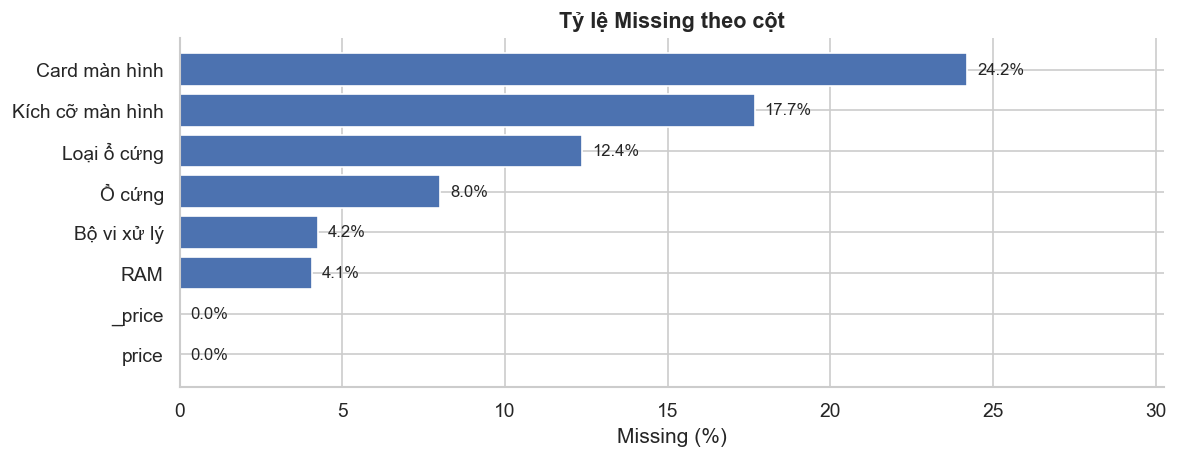

In [11]:
# ── Bar chart missing % ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
cols  = miss_df.index.tolist()
vals  = miss_df['Missing %'].values
bars  = ax.barh(cols[::-1], vals[::-1], color=ACCENT, edgecolor='white')

for bar, v in zip(bars, vals[::-1]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va='center', fontsize=10)

ax.set_xlabel("Missing (%)")
ax.set_title("Tỷ lệ Missing theo cột")
ax.set_xlim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()


<Axes: >

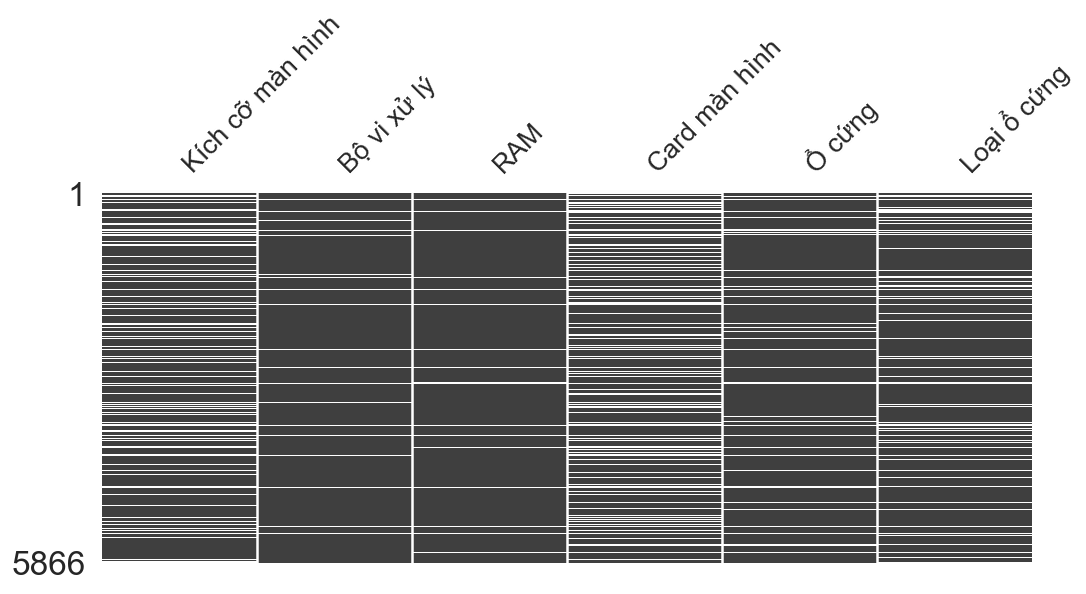

In [12]:
# ── Missing cùng lúc nhiều cột spec ───────────────────────────────────────────
spec_cols = ['Kích cỡ màn hình', 'Bộ vi xử lý', 'RAM',
             'Card màn hình', 'Ổ cứng', 'Loại ổ cứng']
msno.matrix(df[spec_cols], figsize=(10, 4), sparkline=False)

Biểu đồ cho thấy missing values phân bố không đồng đều giữa các cột và các bản ghi (**non-random missingness**). Các thuộc tính phần cứng như `Card màn hình`, `Kích cỡ màn hình`, và `Ổ cứng` thường thiếu cùng nhau, cho thấy người bán có xu hướng không cung cấp đầy đủ thông tin kỹ thuật.

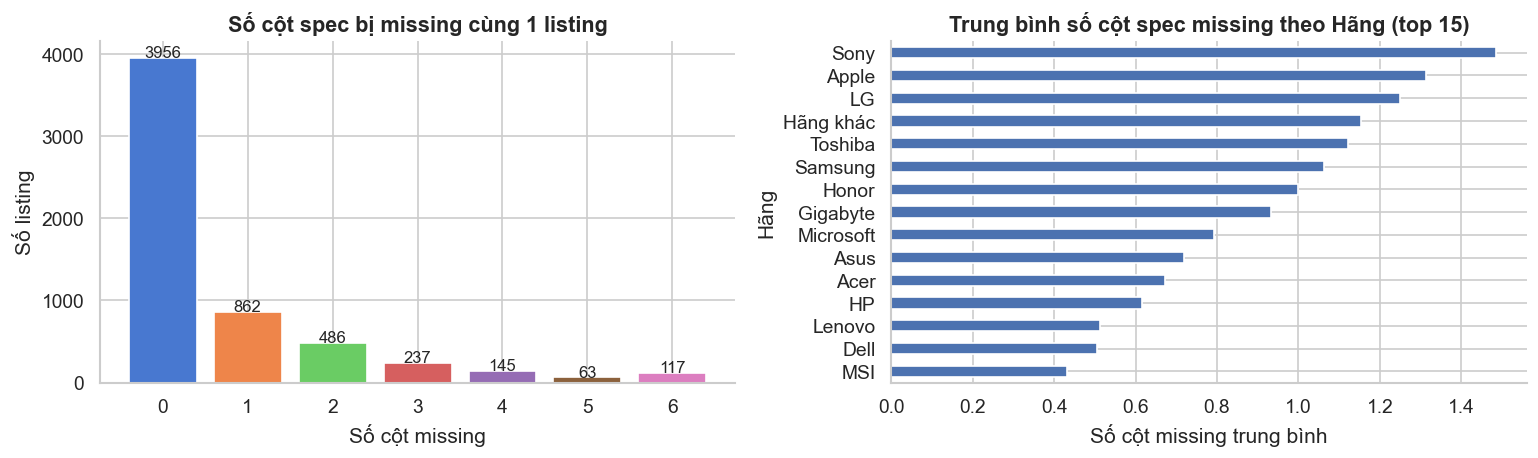


Listing missing 0 cột spec: 3,956 (67.4%)
Listing missing ≥ 3 cột spec: 562 (9.6%)


In [13]:
n_miss_spec = df[spec_cols].isnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = n_miss_spec.value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=COLORS[:len(vc)], edgecolor='white')
axes[0].set_title("Số cột spec bị missing cùng 1 listing")
axes[0].set_xlabel("Số cột missing")
axes[0].set_ylabel("Số listing")
for i, (x, y) in enumerate(zip(vc.index.astype(str), vc.values)):
    axes[0].text(i, y + 5, str(y), ha='center', fontsize=10)

brand_miss = df.copy()
brand_miss['n_miss_spec'] = n_miss_spec
brand_miss = brand_miss.groupby('Hãng')['n_miss_spec'].mean().sort_values(ascending=False).head(15)
brand_miss.sort_values().plot(kind='barh', ax=axes[1], color=ACCENT)
axes[1].set_title("Trung bình số cột spec missing theo Hãng (top 15)")
axes[1].set_xlabel("Số cột missing trung bình")
plt.tight_layout()
plt.show()

print(f"\nListing missing 0 cột spec: {(n_miss_spec == 0).sum():,} ({(n_miss_spec==0).mean()*100:.1f}%)")
print(f"Listing missing ≥ 3 cột spec: {(n_miss_spec >= 3).sum():,} ({(n_miss_spec>=3).mean()*100:.1f}%)")

### Missing per Listing & Brand

Phần lớn listing có dữ liệu khá đầy đủ, với khoảng **67.4%** không thiếu cột spec nào. Tuy nhiên, vẫn có khoảng **9.6%** listing thiếu từ 3 cột trở lên, cho thấy một phần dữ liệu có chất lượng thấp hơn.

Xét theo từng hãng, mức độ thiếu thông tin không đồng đều (**brand-dependent missingness**). Một số hãng như Sony, Apple có xu hướng thiếu nhiều thông tin hơn, trong khi các hãng như MSI, Dell, Lenovo có dữ liệu đầy đủ hơn.

Điều này cho thấy chất lượng dữ liệu phụ thuộc vào nguồn đăng tin và cần được xử lý cẩn thận trong preprocessing.

<Axes: >

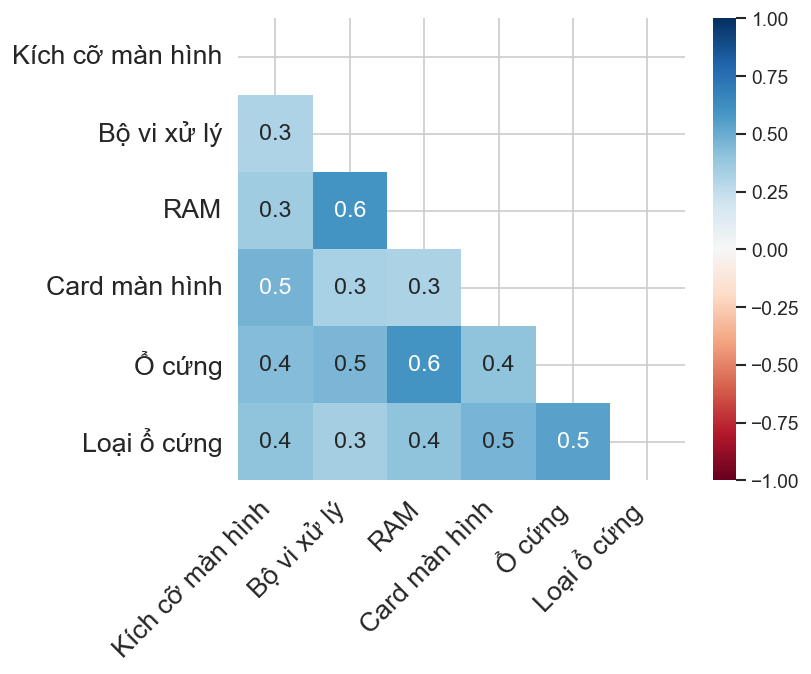

In [14]:
msno.heatmap(df[spec_cols], figsize=(6, 5))

### Missing Correlation

Heatmap cho thấy tồn tại **mối tương quan dương (positive correlation)** giữa các cột spec khi bị missing. Đặc biệt:

- `RAM` và `Ổ cứng` có tương quan cao (~0.6)
- `Ổ cứng` và `Loại ổ cứng` cũng có tương quan đáng kể (~0.5)

Điều này cho thấy missing values không xảy ra ngẫu nhiên (**not missing completely at random**), mà thường xuất hiện theo cụm giữa các thuộc tính phần cứng liên quan.

> Có thể tận dụng mối quan hệ này trong preprocessing, ví dụ **feature inference** (suy luận giá trị thiếu từ các cột liên quan) thay vì chỉ đơn thuần impute độc lập.

<Axes: >

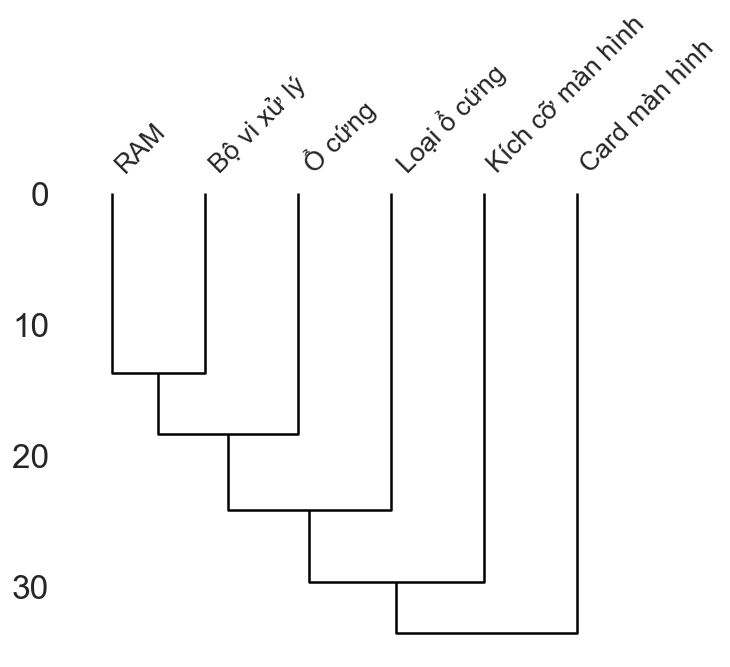

In [15]:
msno.dendrogram(df[spec_cols], figsize=(6, 5))

### Missing Structure (Dendrogram)

Biểu đồ dendrogram cho thấy các cột spec có xu hướng được nhóm lại theo mức độ missing tương tự nhau.

- `RAM` và `Bộ vi xử lý` nằm cùng cụm → thường missing cùng nhau
- `Ổ cứng` và `Loại ổ cứng` cũng có liên kết chặt chẽ
- `Card màn hình` và `Kích cỡ màn hình` tách biệt hơn → pattern missing khác

Kết quả này nhất quán với heatmap trước đó, cho thấy tương quan missing cao. Điều này xác nhận rằng missing values có cấu trúc (**structured & correlated missingness**), không phải ngẫu nhiên.

### Implications

- Có thể áp dụng **feature inference** giữa các cột cùng cụm (ví dụ: suy luận `Loại ổ cứng` từ `Ổ cứng`)
- Không nên impute độc lập từng cột, vì sẽ làm mất mối quan hệ giữa các feature
- Các cụm này có thể được dùng để thiết kế **group-wise imputation strategy**

Nhìn chung, dendrogram giúp củng cố và trực quan hóa lại các mối quan hệ đã quan sát từ heatmap, làm rõ rằng việc xử lý missing cần dựa trên cấu trúc dữ liệu thay vì áp dụng một phương pháp chung cho toàn bộ dataset.

## 5. Column: `price`

Giá ở dạng string `"X.XXX.XXX đ"` — cần parse. Các trường hợp cần lường trước:
- Format chuẩn: `"9.990.000 đ"`
- `"Thỏa thuận"` — người bán không muốn ghi cố định
- 1 dòng đã biết missing từ overview
- Outlier cực thấp/cao (nhập sai đơn vị, listing lạ)


In [16]:
# ── Các format giá xuất hiện ────────────────────────────────────────────────────
non_numeric = df['price'].dropna()[~df['price'].dropna().str.contains(r'\d', na=False)]
print(f"Giá không chứa số: {len(non_numeric)}")
print(non_numeric.value_counts().to_string())
print(f"\nGiá bị NaN (missing): {df['price'].isna().sum()}")


Giá không chứa số: 0
Series([], )

Giá bị NaN (missing): 1


In [17]:
# ── Parse & validate ────────────────────────────────────────────────────────────
price_clean = df['_price'].dropna()
price_mil   = price_clean / 1e6
desc = price_mil.describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).round(2)

display(desc.to_frame(name="Giá (triệu đồng)").T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Giá (triệu đồng),5865.0,9.92,8.36,0.01,0.6,1.5,4.5,7.6,12.99,25.97,39.64,99.9


### Price Descriptive Statistics (Laptop Dataset)

Dữ liệu giá laptop có **right-skewed distribution** khi mean (9.92) lớn hơn median (7.6), cho thấy sự tồn tại của các **outliers** ở phân khúc giá cao. Đồng thời, **high variability** (std = 8.36 gần bằng mean) phản ánh mức độ phân tán lớn, nghĩa là dữ liệu trải rộng trên nhiều **price segments** khác nhau.

Khoảng giá rất rộng, từ 0.01 đến 99.9 triệu, cho thấy dataset nhiều khả năng bao gồm cả **used** và **new laptops**. Tuy nhiên, phần lớn dữ liệu tập trung ở phân khúc thấp–trung (**low–mid segment concentration**), với median chỉ khoảng 7.6 triệu, tức đa số laptop có giá dưới ~10 triệu. Bên cạnh đó, sự chênh lệch lớn giữa 95th percentile (25.97) và max (99.9) cho thấy có một số **high-end outliers** như các dòng **premium, gaming hoặc workstation**, kéo giá trung bình tăng lên.

**Kết luận (Conclusion):** Dataset thể hiện một thị trường **mixed segments (used + new)**, trong đó phần lớn thuộc phân khúc **low–mid range**, nhưng bị ảnh hưởng bởi một số ít **high-end outliers**, dẫn đến phân phối lệch phải và độ phân tán cao.

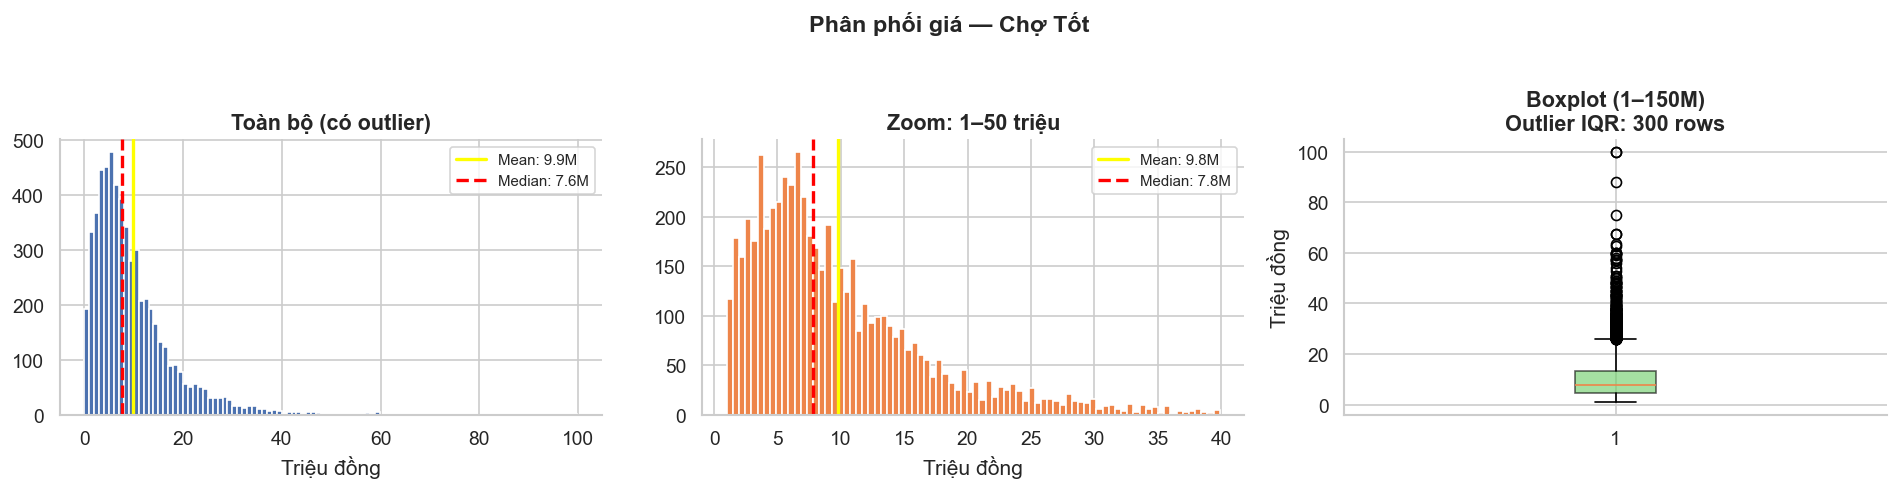

In [18]:
# ── Phân phối giá ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ===== Full range =====
axes[0].hist(price_mil, bins=100, color=ACCENT, edgecolor='white')

mean_full = price_mil.mean()
median_full = price_mil.median()

axes[0].axvline(mean_full, color='yellow', linestyle='-', linewidth=2,
                label=f'Mean: {mean_full:.1f}M')
axes[0].axvline(median_full, color='red', linestyle='--', linewidth=2,
                label=f'Median: {median_full:.1f}M')

axes[0].legend(fontsize=9)
axes[0].set_title("Toàn bộ (có outlier)")
axes[0].set_xlabel("Triệu đồng")


# ===== 1–40 triệu =====
p1_100 = price_mil[(price_mil >= 1) & (price_mil <= 40)]
axes[1].hist(p1_100, bins=80, color=COLORS[1], edgecolor='white')

mean_zoom = p1_100.mean()
median_zoom = p1_100.median()

axes[1].axvline(mean_zoom, color='yellow', linestyle='-', linewidth=2,
                label=f'Mean: {mean_zoom:.1f}M')
axes[1].axvline(median_zoom, color='red', linestyle='--', linewidth=2,
                label=f'Median: {median_zoom:.1f}M')

axes[1].legend(fontsize=9)
axes[1].set_title("Zoom: 1–50 triệu")
axes[1].set_xlabel("Triệu đồng")


# ===== Box & outlier detection =====
Q1, Q3 = price_mil.quantile(.25), price_mil.quantile(.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
n_outlier = ((price_mil < lo) | (price_mil > hi)).sum()

axes[2].boxplot(price_mil[(price_mil >= 1) & (price_mil <= 150)],
                vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLORS[2], alpha=0.6))

axes[2].set_title(f"Boxplot (1–150M)\nOutlier IQR: {n_outlier} rows")
axes[2].set_ylabel("Triệu đồng")


# ===== Style =====
for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Phân phối giá — Chợ Tốt", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Price Distribution Insight (with Mean & Median)

Biểu đồ cho thấy rõ **right-skewed distribution** khi đường **mean (~9.9M)** luôn nằm bên phải **median (~7.6–7.8M)** ở cả hai histogram. Điều này xác nhận rằng một số **high-end outliers** đang kéo giá trung bình lên.

Ở biểu đồ full range, phần lớn dữ liệu vẫn tập trung mạnh ở khoảng <15 triệu, nhưng có đuôi dài đến ~100 triệu. Khi zoom vào 1–40 triệu, cấu trúc phân phối rõ hơn: đỉnh mật độ nằm quanh ~5–10 triệu, phản ánh phân khúc **low–mid range** chiếm đa số.

Boxplot củng cố điều này khi IQR nằm thấp (~4–12 triệu) nhưng xuất hiện rất nhiều điểm vượt whiskers, cho thấy số lượng lớn **outliers** phía trên.

**Kết luận:** Mean > Median + đuôi dài bên phải ⇒ dữ liệu lệch phải rõ rệt, thị trường gồm nhiều laptop giá rẻ–trung và một số ít máy cao cấp kéo phân phối.

In [19]:
# ── Giá bất thường ──────────────────────────────────────────────────────────────
print("=== Giá thấp bất thường (< 1.000,000 đ) ===")
display(df[df['_price'] <1_000_000][['url', 'title', 'price', '_price']].head(10))

print("\n=== Giá cao (> 60 triệu) ===")
display(df[df['_price'] > 60_000_000][['url', 'title', 'price', '_price']].head(10))

PRICE_LO, PRICE_HI = 1_000_000, 60_000_000
n_invalid = ((df['_price'] < PRICE_LO) | (df['_price'] > PRICE_HI)).sum()
print(f"\nGiá ngoài ngưỡng [{PRICE_LO/1e6:.0f}M – {PRICE_HI/1e6:.0f}M]: {n_invalid} rows")

=== Giá thấp bất thường (< 1.000,000 đ) ===


,url,title,price,_price
51,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/132019136.htm,💥 LAPTOP Dell i5 XÀI TỐT CÓ CAMERA MÁY ZIN TEM,990.000 đ,990000.0
72,https://www.chotot.com/mua-ban-quan-ninh-kieu-can-tho/131938722.htm,(Đọc kỹ mô tả)Sạc laptop HP 90W đã qua sử dụng,120.000 đ,120000.0
78,https://www.chotot.com/mua-ban-quan-12-tp-ho-chi-minh/131968912.htm,lap top samsung,550.000 đ,550000.0
154,https://www.chotot.com/mua-ban-thanh-pho-thuan-an-binh-duong/132073283.htm,Acer Intel Core i3 4GB/500GB 95% mới,899.000 đ,899000.0
164,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/131955581.htm,Bán laptop IBM T60 Đen,600.000 đ,600000.0
246,https://www.chotot.com/mua-ban-huyen-bac-tan-uyen-binh-duong/132006127.htm,"Bộ máy tính NEC i5 màn 16"", tặng Loa, Phím, Chuột",850.000 đ,850000.0
254,https://www.chotot.com/mua-ban-thi-xa-phuoc-long-binh-phuoc/131978007.htm,Laptop I7 giá xác,400.000 đ,400000.0
256,https://www.chotot.com/mua-ban-quan-8-tp-ho-chi-minh/131253248.htm,"Laptop HP Stream 13, model 13-c010nr",650.000 đ,650000.0
279,https://www.chotot.com/mua-ban-thanh-pho-thu-dau-mot-binh-duong/132076341.htm,Máy tính xách tay Dell màu Đen,750.000 đ,750000.0
304,https://www.chotot.com/mua-ban-quan-6-tp-ho-chi-minh/132034257.htm,Acer Laptop i5 14 inch 6GB/320GB,950.000 đ,950000.0



=== Giá cao (> 60 triệu) ===


,url,title,price,_price
340,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/132035969.htm,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,74.900.000 đ,74900000.0
638,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131958179.htm,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,99.900.000 đ,99900000.0
1367,https://www.chotot.com/mua-ban-quan-3-tp-ho-chi-minh/131779673.htm,MB Pro 16” M4 Pro 48Gb/1Tb - Cấu hình khủng,63.500.000 đ,63500000.0
1708,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131999886.htm,Macbook M3 MAX 16' Spaceblack Ram 36GB / Ssd 1TB,62.900.000 đ,62900000.0
2689,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131979010.htm,Razer Blade 18 2025 Ultra 9 275HX RTX5080 4K 240Hz,88.000.000 đ,88000000.0
3212,https://www.chotot.com/mua-ban-quan-phu-nhuan-tp-ho-chi-minh/131981076.htm,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,67.500.000 đ,67500000.0
4838,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131935353.htm,ASUS ROG Strix SCAR 16 Ultra 9 32GB/8TB RTX 5090,99.900.000 đ,99900000.0
5651,https://www.chotot.com/mua-ban-quan-tan-binh-tp-ho-chi-minh/132015723.htm,MacBook Pro 16 inch M5 Pro 24/1TB Black LL Newseal,67.500.000 đ,67500000.0



Giá ngoài ngưỡng [1M – 60M]: 167 rows


### Outlier Inspection (Extreme Price Cases)

Quan sát các mẫu **giá thấp bất thường (< 1M)** cho thấy nhiều bản ghi không thực sự là laptop hoàn chỉnh, mà là **phụ kiện (sạc, linh kiện)**, **máy lỗi**, hoặc **bán xác / giá tượng trưng** (ví dụ: “giá xác”, “đọc kỹ mô tả”). Điều này cho thấy presence của **invalid samples / noise** trong dữ liệu, không phù hợp nếu mục tiêu là modeling giá laptop thực.

Ở phía ngược lại, các mẫu **giá cao (> 60M)** chủ yếu thuộc phân khúc **premium / gaming / workstation**, như MacBook Pro cấu hình cao, ASUS ROG, Razer Blade. Đây là các **valid high-end samples**, nhưng số lượng rất ít, tạo thành **high-end outliers** và góp phần làm phân phối bị lệch phải.

**Kết luận (Conclusion):**
- Nhóm giá thấp: phần lớn là **noise / non-standard listings** → nên **lọc bỏ hoặc xử lý riêng**.
- Nhóm giá cao: là **valid but rare samples** → có thể giữ lại nhưng cân nhắc **log-transform** hoặc **robust scaling** khi modeling.
- Tổng thể: cần **data cleaning** để đảm bảo mô hình học đúng phân phối thực của giá laptop.

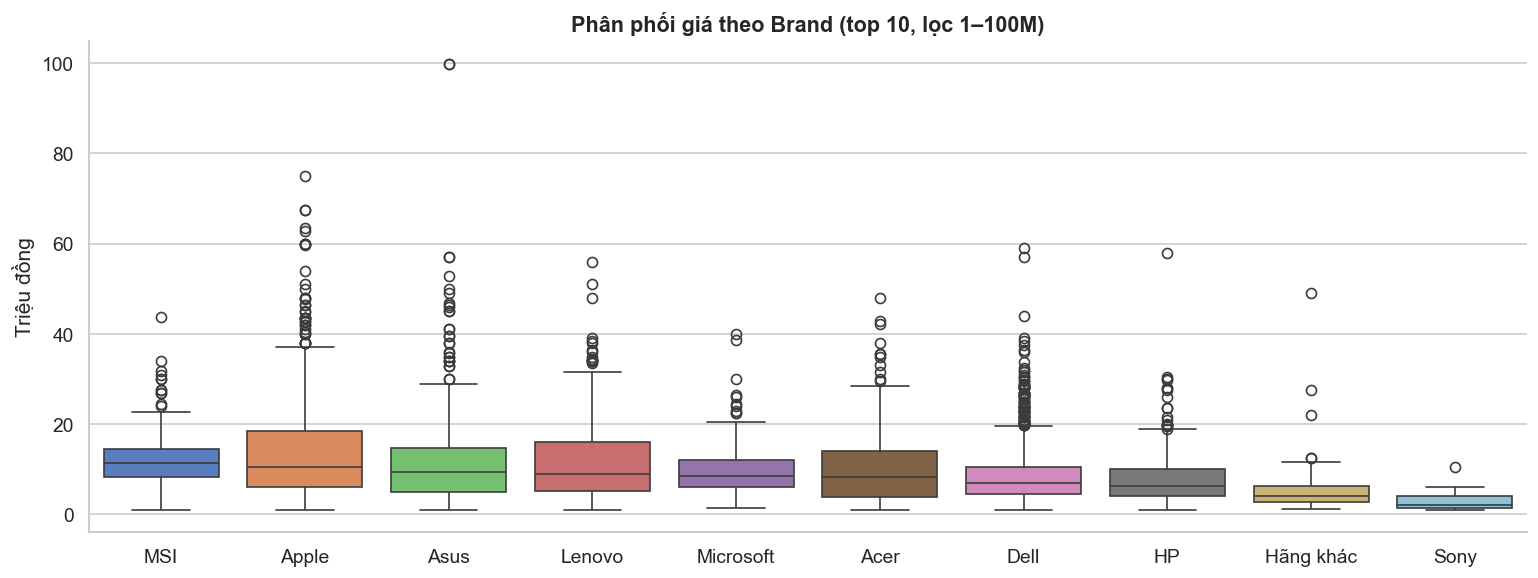

In [20]:
# ── Boxplot phân phối giá theo top-10 brand ────────────────────────────────────
top10_brands = df['Hãng'].value_counts().head(10).index
plot_brand = (df[df['Hãng'].isin(top10_brands) & df['_price'].between(1e6, 100e6)]
              .assign(price_mil=lambda x: x['_price']/1e6))
brand_order = plot_brand.groupby('Hãng')['price_mil'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=plot_brand, x='Hãng', y='price_mil', order=brand_order, palette='muted', ax=ax)
ax.set_title("Phân phối giá theo Brand (top 10, lọc 1–100M)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Price Distribution by Brand (Top 10)

Biểu đồ boxplot theo **brand** cho thấy sự khác biệt rõ rệt về **price distribution** giữa các hãng. Nhìn chung, hầu hết các brand đều có **median** nằm trong khoảng ~7–12 triệu, phản ánh phân khúc **low–mid range** chiếm chủ đạo trên thị trường.

Tuy nhiên, một số brand như **Apple, ASUS, Dell, MSI** có **upper range** và số lượng **high-end outliers** vượt trội, với nhiều điểm giá >40–60 triệu. Đặc biệt, Apple có độ phân tán lớn và xuất hiện các giá trị rất cao (~70–100 triệu), cho thấy tập trung nhiều ở phân khúc **premium**. ASUS và MSI cũng có đuôi phải dài, phù hợp với các dòng **gaming laptops**.

Ngược lại, các brand như **Sony, “Hãng khác”** có **median thấp** và phân phối hẹp hơn, chủ yếu nằm ở phân khúc giá rẻ–trung. Điều này cho thấy sự khác biệt về **product positioning** giữa các hãng.

Ngoài ra, số lượng **outliers ngoài ngưỡng [1M–60M] (~167 rows)** vẫn xuất hiện rải rác ở nhiều brand, tiếp tục khẳng định dữ liệu có **high variance** và **right-skewed distribution**.

**Kết luận (Conclusion):** Dù phần lớn laptop thuộc phân khúc **low–mid range**, một số brand (đặc biệt Apple, ASUS, MSI) đóng góp đáng kể vào **high-end segment**, tạo ra sự lệch phải và độ phân tán lớn trong phân phối giá.

In [21]:
# ===== Quick numeric features (temporary for EDA) =====
def parse_ram(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    return float(nums[0]) if nums else np.nan

def parse_storage(val):
    if pd.isna(val): return np.nan
    v = str(val).upper()
    nums = re.findall(r'[\d\.]+', v)
    if not nums: return np.nan
    val = float(nums[0])
    return val * 1024 if 'TB' in v else val

df['_ram_gb'] = df['RAM'].apply(parse_ram)
df['_storage_gb'] = df['Ổ cứng'].apply(parse_storage)
df['_value_simple'] = df['_ram_gb'] / (df['_price'] / 1e6)

In [22]:
df_clean = df[
    (df['_price'] > 1_000_000) &
    (df['_ram_gb'].between(2, 64)) &
    (df['_value_simple'] < df['_value_simple'].quantile(0.995))
]

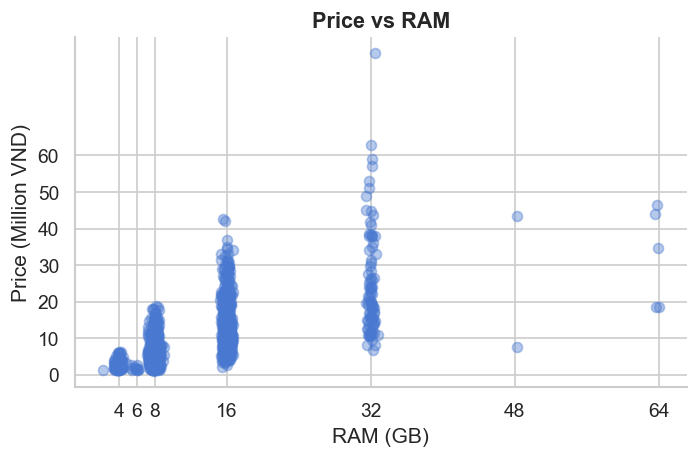

In [23]:
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_price', '_ram_gb']).sample(1500, random_state=42)

x = sample['_ram_gb'] + np.random.normal(0, 0.3, size=len(sample))

ax.scatter(x, sample['_price']/1e6, alpha=0.4)

ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Price (Million VND)")
ax.set_title("Price vs RAM")

ax.set_xticks([4, 6, 8, 16, 32, 48, 64])
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

plt.tight_layout()
plt.show()

### Price vs RAM — Trade-off Analysis

Biểu đồ scatter giữa **price và RAM** cho thấy các điểm dữ liệu không phân bố liên tục mà tập trung thành các cụm dọc tại các mức RAM phổ biến như 4GB, 8GB, 16GB và 32GB. Điều này phản ánh bản chất của RAM là một **discrete feature**, không phải biến liên tục.

Quan sát quan trọng hơn là trong cùng một mức RAM, giá có độ phân tán rất lớn. Ví dụ, với **16GB RAM**, giá có thể dao động từ khoảng 5 triệu đến hơn 40 triệu VND. Điều này cho thấy RAM **không phải là yếu tố quyết định chính của price**. Nói cách khác, cùng một cấu hình RAM nhưng giá có thể khác nhau rất nhiều do ảnh hưởng của các yếu tố khác như CPU, GPU, build quality, brand hoặc dòng sản phẩm.

Ngoài ra, xu hướng tổng thể vẫn tồn tại: RAM cao hơn thường đi kèm với mức giá trung bình cao hơn. Tuy nhiên, mối quan hệ này **không tuyến tính và có độ nhiễu lớn**, cho thấy price là kết quả của nhiều yếu tố kết hợp chứ không phụ thuộc vào một feature đơn lẻ.

Từ góc độ xây dựng, insight quan trọng rút ra là:

* Không thể sử dụng RAM như một proxy trực tiếp cho performance hoặc value
* Cần kết hợp nhiều feature (CPU, GPU, storage, brand, v.v.) để đánh giá đúng giá trị của một laptop
* Price nên được xem như một biến trade-off thay vì target đơn giản

Kết luận, biểu đồ này nhấn mạnh rằng bài toán không phải là “RAM cao → giá cao”, mà là **“với cùng mức price, laptop nào có cấu hình tốt hơn”**, đây chính là nền tảng cho các bước value analysis và ranking phía sau.


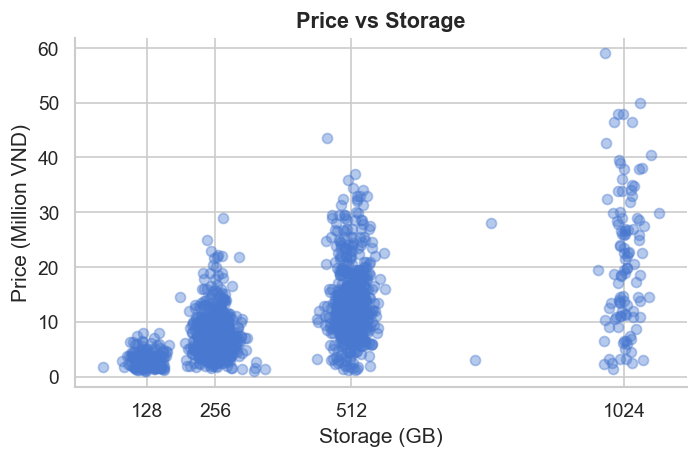

In [24]:
# ===== Price vs Storage (clean + improved) =====
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_price', '_storage_gb']).copy()

# lọc storage hợp lý (EDA-level)
sample = sample[
    (sample['_storage_gb'] >= 64) &
    (sample['_storage_gb'] <= 2048)
]

sample = sample.sample(1500, random_state=42)

# jitter để tránh chồng điểm
x = sample['_storage_gb'] + np.random.normal(0, 20, size=len(sample))

ax.scatter(x, sample['_price']/1e6, alpha=0.4)

ax.set_xlabel("Storage (GB)")
ax.set_ylabel("Price (Million VND)")
ax.set_title("Price vs Storage")

# ticks theo mốc phổ biến
ax.set_xticks([128, 256, 512, 1024])
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

plt.tight_layout()
plt.show()

### Price vs Storage — Trade-off Analysis

Biểu đồ **Price vs Storage** cho thấy dữ liệu tiếp tục phân bố theo các cụm dọc rõ ràng tại các mức dung lượng phổ biến như **128GB, 256GB, 512GB và 1024GB (1TB)**. Điều này phản ánh storage cũng là một **discrete feature**, tương tự như RAM, và không phân bố liên tục.

Quan sát quan trọng là mặc dù dung lượng ổ cứng tăng, giá trung bình có xu hướng tăng theo, nhưng mức độ ảnh hưởng là **không mạnh và không ổn định**. Ví dụ, tại mức **512GB**, giá có thể dao động rất rộng từ khoảng 5 triệu đến hơn 40 triệu VND. Tương tự, các laptop **1TB** cũng trải dài từ phân khúc trung đến cao cấp, thay vì tập trung ở một khoảng giá cụ thể.

So với RAM, storage có vẻ là một yếu tố **ít quyết định hơn đối với price**. Điều này hợp lý về mặt thực tế, vì chi phí nâng cấp ổ cứng thường thấp hơn nhiều so với CPU hoặc GPU. Do đó, sự khác biệt về giá giữa các laptop có cùng dung lượng storage chủ yếu đến từ các yếu tố khác như hiệu năng xử lý, card đồ họa, thương hiệu hoặc phân khúc sản phẩm.

Ngoài ra, có thể nhận thấy một số điểm giá cao xuất hiện ở các mức storage lớn (512GB–1TB), nhưng đây không phải là quy luật cứng mà chỉ phản ánh việc các dòng laptop cao cấp thường đi kèm dung lượng lưu trữ lớn hơn.

Ta rút ra một số nhận xét:

* Storage không nên được sử dụng như một chỉ báo chính cho value hoặc performance
* Cần kết hợp với các feature khác (đặc biệt là CPU và GPU) để đánh giá đúng giá trị thực
* Price cần được phân tích dưới dạng **trade-off đa chiều**, thay vì gắn trực tiếp với một feature riêng lẻ

Kết luận, tương tự như RAM, biểu đồ này cho thấy bài toán không phải là “storage lớn → giá cao”, mà là **“trong cùng một mức giá, dung lượng và cấu hình tổng thể có cân đối hay không”**, từ đó phục vụ cho các bước value analysis và ranking phía sau.


In [25]:
# ===== Overpriced candidates (improved with brand) =====

# Binning
df_clean['_ram_bin'] = pd.cut(df_clean['_ram_gb'], [0, 8, 16, 32, 64])
df_clean['_storage_bin'] = pd.cut(df_clean['_storage_gb'], [0, 256, 512, 1024, 2048])

# Group theo RAM + Storage + Brand
group_median = df_clean.groupby(
    ['Hãng', '_ram_bin', '_storage_bin']
)['_price'].median()

# Map expected price
df_clean['_expected_price'] = df_clean.set_index(
    ['Hãng', '_ram_bin', '_storage_bin']
).index.map(group_median)

# Price gap
df_clean['_price_gap'] = df_clean['_price'] - df_clean['_expected_price']

# % gap
df_clean['_price_gap_pct'] = df_clean['_price_gap'] / df_clean['_expected_price']

# Top overpriced
df_clean.sort_values('_price_gap_pct', ascending=False)[
    ['title', 'Hãng', '_ram_gb', '_storage_gb', '_price', '_expected_price', '_price_gap_pct']
].head(10)

,title,Hãng,_ram_gb,_storage_gb,_price,_expected_price,_price_gap_pct
3212,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,Apple,16.0,1024.0,67500000.0,16300000.0,3.141104
5651,MacBook Pro 16 inch M5 Pro 24/1TB Black LL Newseal,Apple,16.0,1024.0,67500000.0,16300000.0,3.141104
2056,DELL Precision 7670-I7-12850HX–R 32G-RTX A3000-12G,Dell,16.0,256.0,33800000.0,8500000.0,2.976471
695,Dell Precision 7550 i7-10750H/16GB/512GB/RTX 3000,Dell,8.0,256.0,16000000.0,5000000.0,2.200000
316,HP Victus 15 i5-13420H RTX 3050 6GB Newseal,HP,8.0,512.0,18800000.0,5974500.0,2.146707
5783,"Macbook Pro 2017 i5 8G 1TB\SSD 13"" inch BH 6 tháng",Apple,8.0,1024.0,9500000.0,3069950.0,2.094513
3614,Dell xps 9640 ultra 9 185h/64/2T/rtx4070/4k oled,Dell,32.0,1024.0,59000000.0,19245000.0,2.065731
5423,Lenovo Ideapad Duet màn 2.5k keng rẻ sài ít giờ,Hãng khác,8.0,250.0,11000000.0,3650000.0,2.013699
3546,Sony VAIO PRO i7-5500U 13.3 inch 8GB/256GB,Sony,8.0,256.0,6000000.0,2000000.0,2.000000
1953,"HP VICTUS 15 i5-13420H/8GB/512G/3050/15.6"" 144Hz",HP,8.0,512.0,17900000.0,5974500.0,1.996067


### Baseline Price Gap Analysis (RAM + Storage + Brand)

Trong bước này, một phương pháp heuristic đơn giản được sử dụng để ước lượng **expected price** cho mỗi laptop dựa trên các cấu hình tương tự. Cụ thể, dữ liệu được nhóm theo **brand, RAM và storage (đã được binning)**, sau đó lấy **median price** của mỗi nhóm làm giá tham chiếu.

- `_expected_price`: giá trung vị của các laptop có cấu hình tương tự
- `_price_gap`: chênh lệch giữa giá thực tế và giá kỳ vọng
- `_price_gap_pct`: chênh lệch theo tỷ lệ, giúp so sánh công bằng giữa các mức giá khác nhau

Kết quả cho thấy nhiều laptop, đặc biệt là các dòng cao cấp như MacBook hoặc workstation/gaming, có `_price_gap_pct` rất cao. Tuy nhiên, điều này **không có nghĩa là các sản phẩm này bị overpriced**, mà phản ánh rằng mô hình hiện tại chưa capture được các yếu tố quan trọng như CPU, GPU và phân khúc sản phẩm.

Nói cách khác, phương pháp này cho thấy **RAM, storage và brand vẫn chưa đủ để giải thích sự biến động của price**. Đây là một bước kiểm tra hữu ích để đánh giá giới hạn của feature hiện tại, và làm cơ sở để bổ sung các feature mạnh hơn trong các bước tiếp theo.

In [26]:
df['_value_simple'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count    5627.000000
mean        2.287086
std        22.202958
min         0.013351
50%         1.454545
90%         3.076923
95%         4.000000
99%         7.272727
99.9%      57.582851
max      1230.769231
Name: _value_simple, dtype: float64

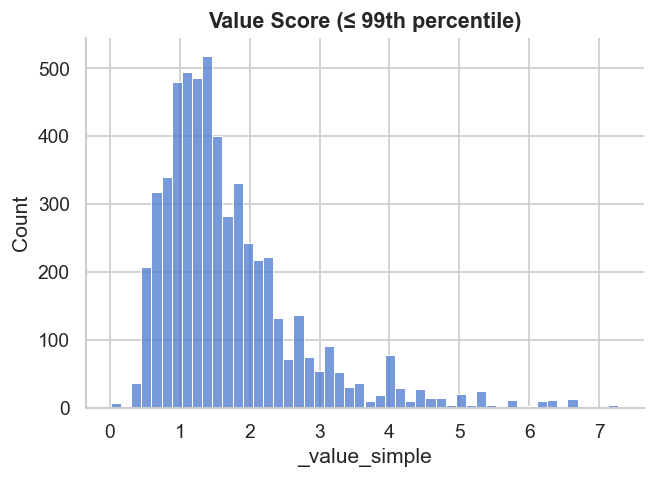

In [27]:
val = df['_value_simple'].dropna()

upper = val.quantile(0.99)   # hoặc 0.995 1 số outlier cực lớn phá distribution sẽ xử l sau tạm thời dùng 0.99
val_cut = val[val <= upper]

plt.figure(figsize=(6,4))
sns.histplot(val_cut, bins=50)
plt.title("Value Score (≤ 99th percentile)")
plt.show()

### Value Score Analysis (RAM / Price)

Giá trị `_value_simple` được định nghĩa là:

$$
\text{value\_simple} = \frac{\text{RAM (GB)}}{\text{price (million VND)}}
$$

Tức là đo lường **số GB RAM trên mỗi triệu VND**, nhằm đánh giá mức độ “bang-for-buck” cơ bản của laptop.

Sau khi loại bỏ các outlier (trên 99th percentile), phân phối value score cho thấy:

- Phần lớn laptop tập trung trong khoảng **1 → 2**
- Một số ít đạt **3 → 5**, được xem là các lựa chọn có value cao
- Đuôi phải (tail) vẫn tồn tại nhưng đã được kiểm soát, phản ánh các trường hợp giá thấp hoặc cấu hình tương đối tốt

Insight quan trọng:

- Giá trị value cao thường đến từ:
  - laptop giá rẻ nhưng RAM tương đối lớn
  - hoặc các cấu hình cân đối trong phân khúc tầm trung
- Ngược lại, các laptop cao cấp (MacBook, gaming high-end) thường có value thấp hơn vì giá bị chi phối bởi CPU, GPU và build quality, không chỉ RAM

Tuy nhiên, cần lưu ý:

- Metric này **rất đơn giản và chưa đầy đủ**, vì chỉ dựa trên RAM
- Không phản ánh hiệu năng tổng thể (CPU, GPU)
- Không phù hợp để dùng trực tiếp cho recommender

Do đó, `_value_simple` chỉ nên được xem là **baseline metric**, giúp hiểu sơ bộ về trade-off giữa RAM và price, trước khi xây dựng các value score phức tạp hơn.

In [28]:
df_clean.sort_values('_value_simple', ascending=False)[
    ['title', '_ram_gb', '_price', '_value_simple']
].head(15)

,title,_ram_gb,_price,_value_simple
1146,Toshiba Dynabook T554/45LR i3-4005U 15.6 inch 12GB,16.0,1800000.0,8.888889
4214,Apple MacBook Pro i5 10GB/500GB Bạc,16.0,2000000.0,8.000000
1464,Dell M4600 i7-2720QM 12GB/120GB,16.0,2000000.0,8.000000
1635,HP i3 12GB Đen,16.0,2000000.0,8.000000
2836,Laptop Dell E4310 i5 8GB SSD128GB Win11pro HDMI-TV,8.0,1090000.0,7.339450
3417,Dell Latitude E6430 i7 16GB Pin chai,16.0,2200000.0,7.272727
2102,Apple MacBook Pro Bạc Retina,8.0,1100000.0,7.272727
3381,Dell,8.0,1200000.0,6.666667
4792,Acer Corei5 -7200U / ddr4 8gb / ổ ssd M2 WD 250gb,8.0,1200000.0,6.666667
734,Lenovo Thinkpad T440p i5-4310m 8GB/500GB HDD,8.0,1200000.0,6.666667


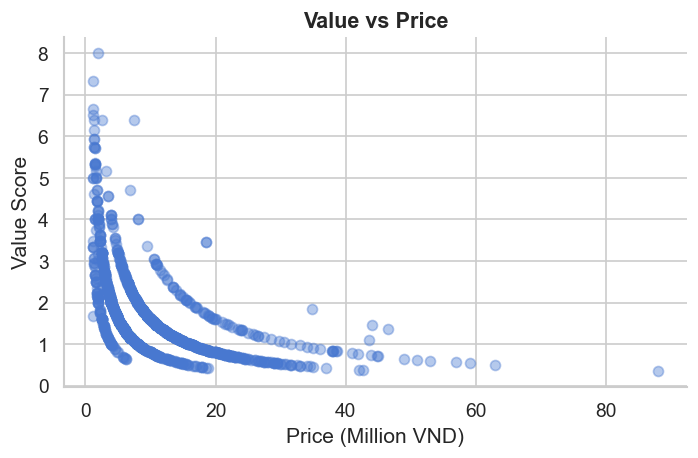

In [29]:
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_value_simple', '_price']).sample(1500, random_state=42)

ax.scatter(sample['_price']/1e6, sample['_value_simple'], alpha=0.4)
ax.set_xlabel("Price (Million VND)")
ax.set_ylabel("Value Score")
ax.set_title("Value vs Price")

plt.tight_layout()
plt.show()

### Value vs Price — Trade-off Analysis

Biểu đồ **Value vs Price** cho thấy mối quan hệ rất rõ giữa giá và value score (RAM / price). Cụ thể, tồn tại một xu hướng giảm mạnh: khi **price tăng**, value score có xu hướng **giảm nhanh theo dạng phi tuyến**.

Điều này là hợp lý về mặt định nghĩa, vì value score có price ở mẫu số. Tuy nhiên, biểu đồ vẫn mang lại một số insight quan trọng:

- Ở phân khúc giá thấp (dưới ~10 triệu), value score phân bố rộng và có nhiều điểm đạt giá trị cao (3–8), cho thấy đây là khu vực có nhiều “bang-for-buck” tốt.
- Khi giá tăng (20–40 triệu), value score bắt đầu co lại, chủ yếu nằm trong khoảng 0.5–2, phản ánh việc chi phí tăng nhưng RAM không tăng tương ứng.
- Ở phân khúc cao cấp (>40 triệu), value score rất thấp (<1), cho thấy giá không còn tỷ lệ thuận với RAM mà bị chi phối bởi các yếu tố khác như CPU, GPU, build quality và thương hiệu.

Một đặc điểm đáng chú ý là các đường cong (curves) xuất hiện trong biểu đồ. Đây thực chất là các mức RAM cố định (8GB, 16GB, 32GB…), vì với mỗi mức RAM, value score sẽ giảm theo dạng:

$$
value = \frac{\text{RAM}}{\text{price}}
$$

Do đó, mỗi “curve” tương ứng với một cấu hình RAM cụ thể.

Từ góc độ recommender system, insight chính là:

- Value cao không đồng nghĩa với laptop tốt hơn, mà chỉ phản ánh hiệu quả chi phí theo một chiều (RAM)
- Các laptop giá cao có value thấp nhưng vẫn đáng mua trong các use-case như gaming, development hoặc thiết kế
- Cần xây dựng value score đa chiều (CPU, GPU, RAM…) thay vì chỉ dựa trên RAM

Kết luận, biểu đồ này nhấn mạnh rằng bài toán không phải là “giá thấp → tốt hơn”, mà là **“giá đó mang lại hiệu năng tổng thể gì”**, từ đó dẫn tới việc xây dựng các scoring function phức tạp hơn ở các bước sau.

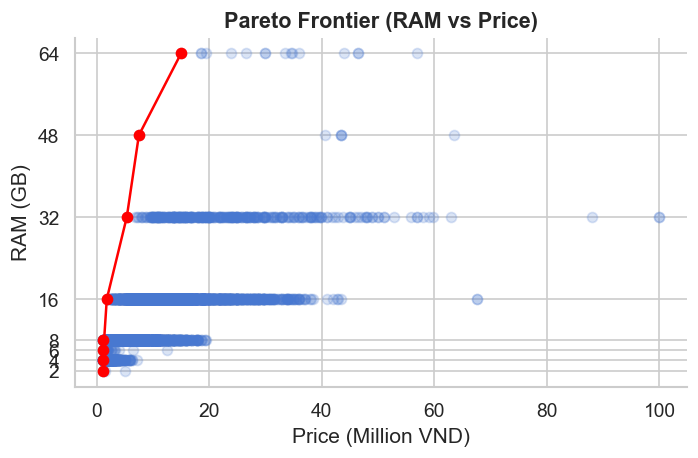

In [30]:
# ===== Pareto frontier (fixed RAM levels) =====

ram_levels = [2, 4, 6, 8, 16, 32, 48, 64]

# 1. Filter dữ liệu hợp lệ
df_pf = df_clean.dropna(subset=['_ram_gb', '_price']).copy()

# 2. Giữ các RAM gần nhất trong levels
df_pf = df_pf[df_pf['_ram_gb'].isin(ram_levels)]

# 3. Với mỗi RAM, lấy laptop rẻ nhất (best price)
pareto_df = (
    df_pf.groupby('_ram_gb')
    .apply(lambda x: x.loc[x['_price'].idxmin()])
    .reset_index(drop=True)
)

# 4. Sort theo price để vẽ đường frontier
pareto_df = pareto_df.sort_values('_price')

# ===== Plot =====
plt.figure(figsize=(6,4))

plt.scatter(df_pf['_price']/1e6, df_pf['_ram_gb'], alpha=0.2)

plt.plot(
    pareto_df['_price']/1e6,
    pareto_df['_ram_gb'],
    marker='o',
    color='red'
)

plt.xlabel("Price (Million VND)")
plt.ylabel("RAM (GB)")
plt.title("Pareto Frontier (RAM vs Price)")

plt.yticks(ram_levels)

plt.tight_layout()
plt.show()

### Pareto Frontier (RAM vs Price) — Analysis

Biểu đồ Pareto Frontier thể hiện **mức giá thấp nhất cần trả để đạt được từng mức RAM**, từ đó mô tả trade-off giữa chi phí và cấu hình.

Một số quan sát quan trọng:

- Đường Pareto (màu đỏ) có dạng **tăng dần rõ rệt**, cho thấy để đạt RAM cao hơn, người dùng phải trả mức giá tối thiểu ngày càng lớn.
- Từ **2GB → 8GB**, mức tăng giá là tương đối nhỏ, cho thấy đây là phân khúc phổ thông với chi phí nâng cấp thấp.
- Từ **8GB → 16GB**, bắt đầu xuất hiện bước nhảy đáng kể về giá, phản ánh sự chuyển dịch sang phân khúc tầm trung.
- Từ **16GB → 32GB**, chi phí tăng mạnh hơn, cho thấy đây là ngưỡng quan trọng về hiệu năng.
- Từ **32GB → 48GB → 64GB**, giá tăng rất nhanh, thể hiện hiện tượng **diminishing returns** — chi phí tăng nhiều nhưng lợi ích (RAM) không tăng tương ứng.

Ngoài ra, phần scatter cho thấy:
- Nhiều laptop có cùng mức RAM nhưng giá cao hơn đáng kể so với Pareto frontier → các sản phẩm này không tối ưu về mặt chi phí/RAM.
- Pareto frontier đại diện cho các lựa chọn “tối ưu nhất” nếu chỉ xét RAM và price.

Tuy nhiên, cần lưu ý:

- Phân tích này chỉ dựa trên RAM, nên chưa phản ánh đầy đủ hiệu năng thực tế (CPU, GPU, build quality).
- Các laptop nằm ngoài frontier không hẳn là lựa chọn kém, mà có thể cung cấp giá trị ở các khía cạnh khác.

Kết luận:

Pareto frontier cho thấy rõ trade-off giữa RAM và price, đồng thời giúp xác định các cấu hình có hiệu quả chi phí tốt nhất. Tuy nhiên, để xây dựng recommender system chính xác, cần mở rộng sang các dimension khác như CPU và GPU.

## 6. Column: `title`

Tiêu đề listing tự do — noisy nhưng có tiềm năng extract thêm thông tin cho các cột spec bị missing.


count    5866.0
mean       41.7
std         8.1
min         2.0
25%        37.0
50%        44.0
75%        48.0
max        50.0


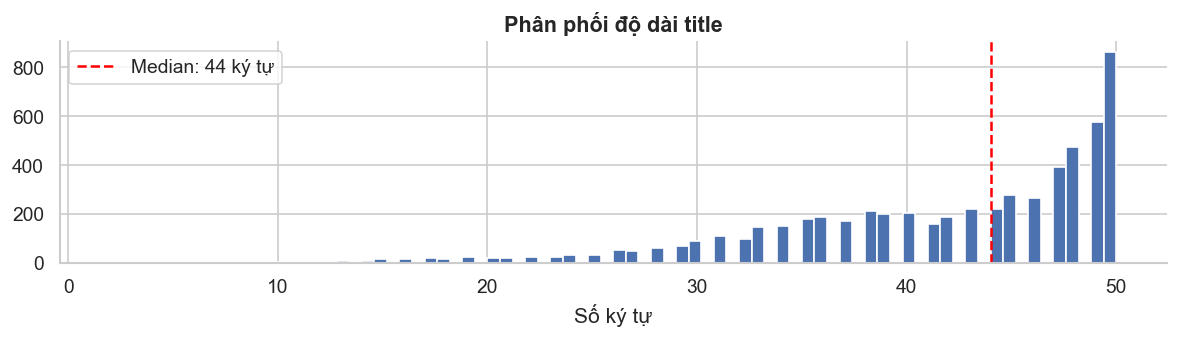

In [31]:
# ── Phân phối độ dài title ─────────────────────────────────────────────────────
title_len = df['title'].str.len()
print(title_len.describe().round(1).rename("Độ dài title (ký tự)").to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(title_len.dropna(), bins=80, color=ACCENT, edgecolor='white')
ax.axvline(title_len.median(), color='red', linestyle='--',
           label=f'Median: {title_len.median():.0f} ký tự')
ax.set_title("Phân phối độ dài title")
ax.set_xlabel("Số ký tự")
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
# ── Title basic quality ────────────────────────────────────────────────────────
title_s = df['title'].fillna('').astype(str)

title_quality = pd.DataFrame({
    'Metric': [
        'Missing title',
        'Empty after strip',
        'Duplicate title',
        'Unique title',
        'Avg chars',
        'Median chars',
        'Avg words',
        'Median words'
    ],
    'Value': [
        df['title'].isna().sum(),
        title_s.str.strip().eq('').sum(),
        df['title'].duplicated(keep=False).sum(),
        df['title'].nunique(),
        round(title_s.str.len().mean(), 1),
        round(title_s.str.len().median(), 1),
        round(title_s.str.split().str.len().mean(), 1),
        round(title_s.str.split().str.len().median(), 1),
    ]
})

display(title_quality)

,Metric,Value
0,Missing title,0.0
1,Empty after strip,0.0
2,Duplicate title,211.0
3,Unique title,5749.0
4,Avg chars,41.7
5,Median chars,44.0
6,Avg words,7.3
7,Median words,7.0


### Title Quality Analysis

Kết quả kiểm tra cho thấy cột `title` có chất lượng dữ liệu rất tốt về mức độ đầy đủ. Không có giá trị bị thiếu và cũng không tồn tại trường hợp chuỗi rỗng sau khi loại bỏ khoảng trắng. Điều này cho thấy tất cả các listing đều có tiêu đề hợp lệ, và `title` có thể được sử dụng xuyên suốt trong các bước phân tích mà không cần xử lý missing.

Bên cạnh đó, số lượng title unique chiếm gần như toàn bộ dataset (khoảng 98%), trong khi số lượng duplicate chỉ chiếm một tỷ lệ nhỏ. Điều này phản ánh đúng đặc trưng của dữ liệu marketplace, nơi mỗi listing thường được viết riêng biệt, nhưng vẫn tồn tại một số trường hợp trùng lặp về nội dung do nhiều người bán đăng cùng một sản phẩm hoặc đăng lại nhiều lần.

Xét về độ dài, title có trung bình khoảng 7 từ và khoảng 42 ký tự. Đây là mức độ dài tương đối hợp lý: không quá ngắn để thiếu thông tin, nhưng cũng không quá dài để trở nên nhiễu. Điều này cho thấy phần lớn title có cấu trúc cô đọng, thường bao gồm các thành phần chính như brand, model và một số thông tin cấu hình cơ bản.

Từ những đặc điểm trên, có thể nhận định rằng `title` khá đầy đủ. Tuy nhiên, do đây là dữ liệu do người bán tự nhập nên vẫn có khả năng chứa các yếu tố không chuẩn hóa hoặc mang tính quảng cáo. Vì vậy, trong các bước tiếp theo, `title` nên được sử dụng theo hướng trích xuất thông tin có cấu trúc (như CPU, RAM, storage) kết hợp với việc xử lý hoặc lọc các yếu tố nhiễu nếu cần thiết.

In [33]:
# ── Information coverage in title ──────────────────────────────────────────────
title_lower = df['title'].fillna('').str.lower()

patterns = {
    'Brand mentioned': r'\b(dell|hp|asus|acer|lenovo|apple|macbook|msi|lg|microsoft|surface|toshiba|sony|samsung|panasonic|razer|gigabyte)\b',
    'CPU mentioned': r'\b(i[3579][-\s]?\d{3,5}[a-z]{0,2}|intel core i[3579]|ryzen\s?[3579]|m[12345](\s?(pro|max|ultra))?|core ultra\s?[579])\b',
    'RAM mentioned': r'\b(4|8|12|16|24|32|36|48|64|96|128)\s?gb\b',
    'Storage mentioned': r'\b(128|256|512|1000|1024|1tb|2tb|500)\s?(gb|tb)?\b',
    'Screen mentioned': r'\b(10|11|12|13|13\.3|14|15|15\.6|16|17|17\.3)\s?(inch|inches|")\b',
    'GPU mentioned': r'\b(rtx|gtx|nvidia|quadro|mx\d+|radeon|iris xe|arc)\b',
    'Condition / promo words': r'\b(new|newseal|zin|đẹp|keng|like new|fullbox|bh|bảo hành|xách tay|thanh lý)\b',
}

coverage = []
for name, pat in patterns.items():
    mask = title_lower.str.contains(pat, regex=True, na=False)
    coverage.append({
        'Feature group': name,
        'Count': mask.sum(),
        'Percent (%)': round(mask.mean() * 100, 1)
    })

coverage_df = pd.DataFrame(coverage).sort_values('Percent (%)', ascending=False)
display(coverage_df)

,Feature group,Count,Percent (%)
0,Brand mentioned,5364,91.4
2,RAM mentioned,3348,57.1
3,Storage mentioned,3219,54.9
1,CPU mentioned,2636,44.9
4,Screen mentioned,1359,23.2
6,Condition / promo words,649,11.1
5,GPU mentioned,352,6.0


### Information Coverage in `title`

**Brand**, xuất hiện trong hơn 90% các title. Điều này cho thấy người bán gần như luôn đề cập đến hãng sản xuất, và do đó `title` có thể được xem là một nguồn đáng tin cậy để xác định brand trong trường hợp cột structured bị thiếu hoặc không chuẩn hóa.

Các thông tin về cấu hình phần cứng như **RAM** và **storage** cũng xuất hiện với tần suất khá cao, lần lượt khoảng 57% và 55%. Điều này cho thấy hơn một nửa các listing có đề cập trực tiếp đến dung lượng bộ nhớ và ổ cứng trong title. Tuy nhiên, mức coverage này vẫn chưa đủ để thay thế hoàn toàn các cột structured, mà chỉ nên được sử dụng như nguồn bổ sung.

Đối với **CPU**, tỷ lệ xuất hiện thấp hơn, khoảng 45%. Thông tin về **kích thước màn hình** xuất hiện khá hạn chế (khoảng 23%), cho thấy đây không phải là yếu tố thường xuyên được nhấn mạnh trong title. Tương tự, các thông tin về **GPU** chỉ xuất hiện trong khoảng 6% các trường hợp, chủ yếu tập trung ở các dòng máy gaming hoặc workstation

Ngoài ra, các từ khóa liên quan đến **tình trạng hoặc quảng cáo** như "new", "zin", "like new", "bảo hành" xuất hiện trong khoảng 11% title. Những từ này không mang ý nghĩa cấu hình nhưng có thể phản ánh tình trạng sản phẩm hoặc chiến lược bán hàng, và có thể được encode thành các feature dạng binary trong các mô hình.

Do mức độ coverage không đồng đều và tồn tại khả năng nhiễu, `title` nên được sử dụng một cách chọn lọc, ưu tiên cho feature extraction và hỗ trợ xử lý missing, thay vì thay thế hoàn toàn các cột structured.

In [34]:
cpu_pat_str = r'''(?ix)
\b(
    i[3579][-\s]?\d{4,5}[A-Z]{0,2} |
    Ryzen\s?[3579]\s?\d{3,5}[A-Z]{0,2} |
    Ryzen\s?[3579] |
    M[1-4]\s?(Pro|Max|Ultra)? |
    N\d{3,5} |
    Celeron | Pentium | Athlon | Core\s?Ultra
)\b
'''

ram_pat_str = r'(?i)\b(4|8|12|16|24|32|64|128)\s?GB\b'

# ── Mask missing ──────────────────────────────────────────────────────────────
missing_cpu_mask = df['Bộ vi xử lý'].isna()
missing_ram_mask = df['RAM'].isna()

# ── Detect trong title (Sử dụng string pattern trực tiếp) ──────────────────────
# Lưu ý: Không dùng case=False khi pattern đã có (?i)
title_has_cpu = df['title'].str.contains(cpu_pat_str, na=False, regex=True)
title_has_ram = df['title'].str.contains(ram_pat_str, na=False, regex=True)

# ── Tính đúng % trên subset missing ────────────────────────────────────────────
cpu_hits = (missing_cpu_mask & title_has_cpu).sum()
ram_hits = (missing_ram_mask & title_has_ram).sum()

cpu_total = missing_cpu_mask.sum()
ram_total = missing_ram_mask.sum()

cpu_rate = (cpu_hits / cpu_total * 100) if cpu_total > 0 else 0
ram_rate = (ram_hits / ram_total * 100) if ram_total > 0 else 0

# ── Output ─────────────────────────────────────────────────────────────────────
print(f"Dòng thiếu 'Bộ vi xử lý': {cpu_total}")
print(f"  → Title có CPU pattern: {cpu_hits} ({cpu_rate:.1f}%)")

print(f"\nDòng thiếu 'RAM': {ram_total}")
print(f"  → Title có RAM pattern: {ram_hits} ({ram_rate:.1f}%)")

Dòng thiếu 'Bộ vi xử lý': 249
  → Title có CPU pattern: 30 (12.0%)

Dòng thiếu 'RAM': 239
  → Title có RAM pattern: 32 (13.4%)


### Missing Recovery Potential from `title`

Mặc dù `title` có chứa nhiều thông tin cấu hình ở mức tổng thể, nhưng khi xét riêng trên các dòng bị thiếu dữ liệu structured, khả năng phục hồi từ title lại khá hạn chế.

Cụ thể, trong số 249 dòng thiếu thông tin về CPU, chỉ có khoảng 12% có thể phát hiện pattern CPU trong title. Tương tự, với 239 dòng thiếu RAM, tỷ lệ recover từ title chỉ khoảng 13%.

Điều này cho thấy một đặc điểm quan trọng của dataset: các listing bị thiếu thông tin cấu hình thường cũng không cung cấp đầy đủ thông tin trong title. Nói cách khác, việc thiếu dữ liệu không hoàn toàn ngẫu nhiên, mà có xu hướng đi kèm với title nghèo thông tin.

Do đó, mặc dù `title` có thể được sử dụng để bổ sung một phần nhỏ giá trị bị thiếu, nhưng không thể xem đây là giải pháp chính cho bài toán missing values. Trong pipeline xử lý dữ liệu, `title` nên được sử dụng như một nguồn fallback, kết hợp với các phương pháp imputation khác thay vì phụ thuộc hoàn toàn vào việc trích xuất từ text.

In [35]:
# ── RAM extraction risk: false positives from storage ──────────────────────────
ram_raw = df['title'].str.extract(r'(?i)\b(\d{1,3})\s?gb\b', expand=False)
ram_raw_num = pd.to_numeric(ram_raw, errors='coerce')

ram_raw_counts = ram_raw_num.value_counts().sort_index()

display(ram_raw_counts.rename('Count').to_frame())

# Các giá trị khó có khả năng là RAM laptop phổ biến
suspicious_ram = df[
    ram_raw_num.isin([120, 128, 240, 256, 500, 512, 750])
][['title', 'RAM', 'Ổ cứng']].head(20)

print(f"Số title có RAM-like value đáng nghi: {len(suspicious_ram)} sample shown")
display(suspicious_ram)

,Count
title,
2.0,25
3.0,1
4.0,241
6.0,46
8.0,1585
10.0,2
12.0,41
16.0,1202
18.0,10


Số title có RAM-like value đáng nghi: 20 sample shown


,title,RAM,Ổ cứng
15,Dell Precision 5550 750GB Xeon W-10855M RAM 32GB,32 GB,750 GB
45,Asus Tuf Ryzen 5 7535HS 16/512GB RTX 2050 còn BH,16 GB,512 GB
50,7TR5 CÓ NGAY MACBOOK AIR 2020 512GB - SIÊU PHẨM LƯ,NaN,512 GB
87,Macbook pro M3 PRO 14' Spaceblack Ram 36/Ssd 512GB,<1 GB,512 GB
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,NaN
188,Dell Latitude E5270 12.5 i5-6300U8GB/128GB Pin 4H,8 GB,< 128 GB
284,ACER ASPIRE 7 I5 12450H/8/512GB/RTX 2050,8 GB,512 GB
299,Surface Pro 5 M3 | Ram4 | 128GB tặng phím chuột,4 GB,128 GB
301,Asus TUF F15 FX506HF - i5 11400H/512GB/RTX 2050,16 GB,512 GB
358,HP ZBook Firefly 14 G8 i7-1165G7 16G 512GB FHD,16 GB,512 GB


### RAM Extraction Risk — False Positives from Storage

Khi thử extract giá trị RAM từ `title` bằng pattern đơn giản dạng `XGB`, kết quả phân phối cho thấy nhiều giá trị bất thường xuất hiện, chẳng hạn như 128GB, 256GB, 512GB, thậm chí 500GB hoặc 750GB. Đây là những mức dung lượng phổ biến của **ổ cứng (storage)** chứ không phải RAM trong laptop thông thường.

Phân tích chi tiết cho thấy các giá trị này xuất hiện với tần suất đáng kể, ví dụ 256GB và 512GB chiếm số lượng lớn trong các kết quả match. Điều này cho thấy regex hiện tại không phân biệt được ngữ cảnh và đang bắt nhầm các thông tin storage thành RAM.

Việc kiểm tra trực tiếp các sample title xác nhận vấn đề này. Trong nhiều trường hợp, các chuỗi như `512GB`, `256GB` hoặc `750GB` thực chất nằm trong cụm cấu hình kiểu `16GB/512GB`, trong đó giá trị đầu tiên là RAM và giá trị thứ hai là ổ cứng. Tuy nhiên, với cách match hiện tại, cả hai đều bị coi là RAM candidate.

Điều này dẫn đến một rủi ro quan trọng: nếu sử dụng trực tiếp các giá trị extract từ `title` để xây dựng feature RAM, mô hình sẽ bị nhiễu nghiêm trọng do lẫn lộn giữa RAM và storage. Đây là một dạng **false positive có hệ thống**, không phải lỗi ngẫu nhiên.

Do đó, việc trích xuất RAM từ `title` cần được thực hiện cẩn thận hơn, ví dụ:
- ưu tiên các pattern có ngữ cảnh rõ ràng như `ram 16gb` hoặc `16gb ram`;
- giới hạn các giá trị hợp lệ vào các mức RAM phổ biến (4, 8, 16, 32, 64 GB…);
- tránh sử dụng trực tiếp mọi pattern `XGB` mà không kiểm tra vị trí hoặc ngữ cảnh.

In [36]:
# ── Safer spec extraction from title ────────────────────────────────────────────
def extract_ram_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    # Ưu tiên pattern có chữ RAM
    m = re.search(r'\bram\s*(\d{1,3})\s?gb\b|\b(\d{1,3})\s?gb\s*ram\b', t)
    if m:
        val = m.group(1) or m.group(2)
        return float(val)

    # Fallback: bắt XGB nhưng chỉ nhận các mức RAM phổ biến
    candidates = re.findall(r'\b(\d{1,3})\s?gb\b', t)
    valid_ram_levels = {2, 4, 6, 8, 12, 16, 24, 32, 36, 48, 64, 96, 128}

    vals = [int(x) for x in candidates if int(x) in valid_ram_levels]
    return float(vals[0]) if vals else np.nan


def extract_storage_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    # TB
    m_tb = re.search(r'\b(\d+(?:\.\d+)?)\s?tb\b', t)
    if m_tb:
        return float(m_tb.group(1)) * 1024

    # GB storage levels
    candidates = re.findall(r'\b(128|256|512|500|1000|1024)\s?gb\b', t)
    if candidates:
        return float(candidates[-1])

    return np.nan


def extract_cpu_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    patterns = [
        r'\b(i[3579])[-\s]?(\d{4,5}[a-z]{0,2})\b',
        r'\bintel core\s?(i[3579])\b',
        r'\bryzen\s?([3579])\b',
        r'\b(m[12345])\s?(pro|max|ultra)?\b',
        r'\bcore ultra\s?([579])\b'
    ]

    for pat in patterns:
        m = re.search(pat, t)
        if m:
            return m.group(0)

    return np.nan


df['_title_ram_gb'] = df['title'].apply(extract_ram_from_title)
df['_title_storage_gb'] = df['title'].apply(extract_storage_from_title)
df['_title_cpu'] = df['title'].apply(extract_cpu_from_title)

extract_summary = pd.DataFrame({
    'Extracted feature': ['RAM from title', 'Storage from title', 'CPU from title'],
    'Non-null count': [
        df['_title_ram_gb'].notna().sum(),
        df['_title_storage_gb'].notna().sum(),
        df['_title_cpu'].notna().sum()
    ],
    'Coverage (%)': [
        round(df['_title_ram_gb'].notna().mean() * 100, 1),
        round(df['_title_storage_gb'].notna().mean() * 100, 1),
        round(df['_title_cpu'].notna().mean() * 100, 1)
    ]
})

display(extract_summary)

,Extracted feature,Non-null count,Coverage (%)
0,RAM from title,3438,58.6
1,Storage from title,2918,49.7
2,CPU from title,2625,44.7


### Extracted Features from `title`

Sau khi áp dụng các rule parsing, có thể trích xuất được một lượng đáng kể thông tin cấu hình từ `title`. Cụ thể, khoảng 58.6% số dòng có thể extract được giá trị RAM, gần 50% có thể extract được storage, và khoảng 44.7% có thể nhận diện được CPU.

Kết quả này cho thấy `title` thực sự chứa nhiều thông tin hữu ích ở dạng bán cấu trúc, và với cách tiếp cận phù hợp, có thể chuyển đổi một phần nội dung text thành các feature có ý nghĩa. So với việc sử dụng regex đơn giản, các rule parsing có kiểm soát giúp cải thiện độ tin cậy của dữ liệu extract và giảm thiểu các lỗi như nhầm lẫn giữa RAM và storage.

Tuy nhiên, cần lưu ý rằng mức coverage này phản ánh khả năng extract trên toàn bộ dataset, không phải trên các dòng bị thiếu dữ liệu structured. Trong thực tế, như đã phân tích ở phần trước, khả năng sử dụng `title` để phục hồi các giá trị bị thiếu chỉ ở mức khoảng 12–13%. Điều này cho thấy thông tin trong `title` không được phân bố đồng đều, và các dòng thiếu dữ liệu thường cũng thiếu thông tin trong title.

Do đó, các feature được extract từ `title` nên được sử dụng theo hai hướng chính:

- Thứ nhất, chúng có thể đóng vai trò là nguồn bổ sung để fill missing trong một số trường hợp.
- Thứ hai, chúng có thể được sử dụng như các feature độc lập trong mô hình, đặc biệt khi muốn tận dụng thêm thông tin từ text.

Tuy nhiên, không nên sử dụng các giá trị extract này để thay thế trực tiếp các cột structured đã có, do độ tin cậy của chúng vẫn thấp hơn.

In [37]:
# ── Potential missing recovery from title ──────────────────────────────────────
recovery_rows = []

checks = [
    ('RAM', '_title_ram_gb'),
    ('Ổ cứng', '_title_storage_gb'),
    ('Bộ vi xử lý', '_title_cpu')
]

for original_col, extracted_col in checks:
    missing_mask = df[original_col].isna()
    recoverable_mask = missing_mask & df[extracted_col].notna()

    total_missing = missing_mask.sum()
    recoverable = recoverable_mask.sum()
    recovery_rate = recoverable / total_missing * 100 if total_missing > 0 else 0

    recovery_rows.append({
        'Original column': original_col,
        'Missing rows': total_missing,
        'Recoverable from title': recoverable,
        'Recovery rate (%)': round(recovery_rate, 1)
    })

recovery_df = pd.DataFrame(recovery_rows)
display(recovery_df)

# Sample các dòng có thể recover
for original_col, extracted_col in checks:
    sample = df[df[original_col].isna() & df[extracted_col].notna()][
        ['title', original_col, extracted_col]
    ].head(10)

    print(f"\n=== Sample recoverable: {original_col} ===")
    display(sample)

,Original column,Missing rows,Recoverable from title,Recovery rate (%)
0,RAM,239,33,13.8
1,Ổ cứng,470,28,6.0
2,Bộ vi xử lý,249,31,12.4



=== Sample recoverable: RAM ===


,title,RAM,_title_ram_gb
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,NaN,4.0
129,"MSI Leopard GL65 i7-10750H Ram 24GB, SSD 512GB",NaN,24.0
302,HP Emitebook 745-G6✅ R5-3500U 8Gb 256Gb 14”,NaN,8.0
542,"Dell Latitude 5520 ✅ i5-1145G7 8Gb 256Gb 15,6”",NaN,8.0
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,8.0
602,Microsoft Surface Pro 7 Plus i5 8GB/128GB 99%,NaN,8.0
1056,HP 240 G8 I3 TH10 4GB 256GB MÁY ĐẸP NGUYÊN TEM,NaN,4.0
1202,Lenovo LOQ Gaming i5-13450HX RTX 3050 6GB - 512GB,NaN,6.0
1301,Dell Latitude i5 Gen 8th 8GB/256G cảm ứng/mỏng đẹp,NaN,8.0
1304,Dell Ins 5502 / i5-1135G7 16Gb 512Gb vỏ nhôm full,NaN,16.0



=== Sample recoverable: Ổ cứng ===


,title,Ổ cứng,_title_storage_gb
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,500.0
302,HP Emitebook 745-G6✅ R5-3500U 8Gb 256Gb 14”,NaN,256.0
542,"Dell Latitude 5520 ✅ i5-1145G7 8Gb 256Gb 15,6”",NaN,256.0
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,128.0
602,Microsoft Surface Pro 7 Plus i5 8GB/128GB 99%,NaN,128.0
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,NaN,1024.0
1056,HP 240 G8 I3 TH10 4GB 256GB MÁY ĐẸP NGUYÊN TEM,NaN,256.0
1202,Lenovo LOQ Gaming i5-13450HX RTX 3050 6GB - 512GB,NaN,512.0
1304,Dell Ins 5502 / i5-1135G7 16Gb 512Gb vỏ nhôm full,NaN,512.0
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,NaN,1024.0



=== Sample recoverable: Bộ vi xử lý ===


,title,Bộ vi xử lý,_title_cpu
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,NaN,i7 6700hq
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,i7 4600u
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,i5 7200u
952,Apple MacBook Air M1 Vàng hồng,NaN,m1
1406,Macbook Air M4 chính hãng sạc 2 lần như mới,NaN,m4
1631,Apple MacBook Pro M5 16GB/512GB Như mới,NaN,m5
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,NaN,i7 13650hx
1821,Acer Predator Helios Neo 16 i7-14700HX,NaN,i7-14700hx
2361,macbook air m2,NaN,m2
2603,Apple MacBook Air M1,NaN,m1


### Missing Recovery Potential from `title`

Khi đánh giá khả năng sử dụng `title` để phục hồi các giá trị bị thiếu trong các cột structured, kết quả cho thấy hiệu quả khá hạn chế và không đồng đều giữa các feature.

Cụ thể, trong số 239 dòng thiếu thông tin về RAM, chỉ có thể phục hồi được 33 dòng (khoảng 13.8%). Đối với CPU, tỷ lệ này là khoảng 12.4% (31 trên 249 dòng). Trong khi đó, khả năng phục hồi cho ổ cứng còn thấp hơn, chỉ khoảng 6% (28 trên 470 dòng).

Những con số này cho thấy một đặc điểm quan trọng của dataset: các dòng bị thiếu thông tin cấu hình thường cũng không chứa đầy đủ thông tin trong `title`. Điều này cho thấy dữ liệu bị thiếu không hoàn toàn ngẫu nhiên, mà có xu hướng đi kèm với các listing có nội dung mô tả nghèo thông tin.

Quan sát các sample recoverable cho thấy việc extract từ `title` là khả thi trong một số trường hợp điển hình, đặc biệt khi title chứa các pattern rõ ràng như `8GB/256GB`, `i7-1165G7`, hoặc `16GB RAM`. Tuy nhiên, những trường hợp này chỉ chiếm một phần nhỏ trong tổng số các dòng bị thiếu.

Từ góc độ xử lý dữ liệu, điều này dẫn đến một kết luận quan trọng: mặc dù `title` có thể được sử dụng để bổ sung một phần nhỏ các giá trị bị thiếu, nhưng không thể đóng vai trò là giải pháp chính cho bài toán missing values. Việc xử lý missing nên dựa vào các chiến lược khác như imputation theo nhóm hoặc gán giá trị mặc định, trong khi `title` chỉ nên được sử dụng như một nguồn fallback.

Ngoài ra, do việc extract từ `title` vẫn tiềm ẩn rủi ro sai lệch (đặc biệt với các pattern không rõ ràng), các giá trị phục hồi chỉ nên được sử dụng khi cột structured thực sự bị thiếu, và không nên dùng để ghi đè lên dữ liệu đã có.

In [38]:
# ── Consistency check: title-extracted vs structured columns ───────────────────
def parse_ram_gb(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r'(\d{1,3})', str(val))
    return float(m.group(1)) if m else np.nan

df['_ram_struct_gb'] = df['RAM'].apply(parse_ram_gb)
df['_storage_struct_gb'] = df['Ổ cứng'].apply(parse_storage_gb)

ram_conflict = df[
    df['_ram_struct_gb'].notna() &
    df['_title_ram_gb'].notna() &
    (df['_ram_struct_gb'] != df['_title_ram_gb'])
][['title', 'RAM', '_ram_struct_gb', '_title_ram_gb', 'price']]

storage_conflict = df[
    df['_storage_struct_gb'].notna() &
    df['_title_storage_gb'].notna() &
    (df['_storage_struct_gb'] != df['_title_storage_gb'])
][['title', 'Ổ cứng', '_storage_struct_gb', '_title_storage_gb', 'price']]

print(f"RAM conflict: {len(ram_conflict)} rows")
display(ram_conflict.head(10))

print(f"\nStorage conflict: {len(storage_conflict)} rows")
display(storage_conflict.head(10))

RAM conflict: 188 rows


,title,RAM,_ram_struct_gb,_title_ram_gb,price
6,Dell Latitude 7300 i5 13 inch 12GB/256GB,16 GB,16.0,12.0,6.000.000 đ
19,"Dell Precision 3560 i7-1185G7,16GB,256GB,card 2GB",8 GB,8.0,16.0,10.000.000 đ
49,HP VICTUS 15 R7-744HS Card 6Gb Như New BH 1 năm,16 GB,16.0,6.0,17.500.000 đ
137,Dell Inspiron 3542 i3 4GB/500GB,8 GB,8.0,4.0,1.650.000 đ
144,Acer Nitro Lite 16 NL16 I7-13620H RTX 3050 6GB,16 GB,16.0,6.0,17.500.000 đ
188,Dell Latitude E5270 12.5 i5-6300U8GB/128GB Pin 4H,8 GB,8.0,128.0,2.850.000 đ
195,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal,<1 GB,1.0,24.0,59.900.000 đ
211,HP Victus 16 R5-5600H 12GB/256GB/ GTX 1650 4GB,16 GB,16.0,12.0,8.500.000 đ
239,Surface Laptop Studio i7 11370H 32/1Tb A2000 4GB,32 GB,32.0,4.0,23.999.000 đ
269,HP Victus 15 i5-13420H (RTX 3050 6GB) 144HZ,16 GB,16.0,6.0,13.500.000 đ



Storage conflict: 96 rows


,title,Ổ cứng,_storage_struct_gb,_title_storage_gb,price
129,"MSI Leopard GL65 i7-10750H Ram 24GB, SSD 512GB",500 GB,500.0,512.0,10.000.000 đ
193,ASUS i7-7700HQ 15.6 inch 8GB/512GB,500 GB,500.0,512.0,4.700.000 đ
208,Lenovo Legion Y540 i7 16GB/1.25TB Đẹp như mới,1 TB,1024.0,1280.0,10.300.000 đ
318,Dell Inspiron 5570 i7-8550U 16GB/512GB,256 GB,256.0,512.0,4.500.000 đ
336,Macbook Pro 2019 Core i9 16' 64GB/2TB Card 8GB,1 TB,1024.0,2048.0,23.900.000 đ
340,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,1 TB,1024.0,2048.0,74.900.000 đ
538,✅Option đến 2TB SSD - MacBook Pro 16 inch M1 MAX !,> 1 TB,1024.0,2048.0,38.000.000 đ
591,"Acer Spin 3 SP314-51 14"" FHD i5-8250U 8GB 128GB",> 1 TB,1024.0,128.0,2.500.000 đ
638,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,> 1 TB,1024.0,8192.0,99.900.000 đ
653,Lenovo ThinkPad X1 Gen 6 i7 16GB/512GB,256 GB,256.0,512.0,6.500.000 đ


### Consistency Check: Storage — `title` vs Structured Column

Tương tự như với RAM, việc so sánh giữa giá trị storage trích xuất từ `title` và cột structured `Ổ cứng` cũng cho thấy tồn tại sự không nhất quán đáng kể, với tổng cộng 96 trường hợp bị conflict.

Quan sát các sample cho thấy phần lớn sự khác biệt không đến từ lỗi parsing, mà xuất phát từ cách biểu diễn thông tin trong `title`. Trong nhiều trường hợp, `title` ghi rõ cấu hình đầy đủ như `16GB/512GB` hoặc `1TB`, trong khi cột structured lại chứa giá trị khác như `256GB` hoặc `500GB`. Điều này có thể phản ánh việc listing có nhiều phiên bản cấu hình, hoặc người bán không cập nhật đầy đủ thông tin giữa các trường.

Một số trường hợp khác cho thấy sự khác biệt do cách chuẩn hóa đơn vị. Ví dụ, `1TB` trong `title` tương đương với `1024GB`, nhưng đôi khi structured column chỉ ghi `500GB` hoặc `256GB`, cho thấy khả năng dữ liệu bị nhập sai hoặc không đồng nhất.

Ngoài ra, cũng có những trường hợp `title` đề cập đến cấu hình cao hơn (ví dụ `2TB`, `8TB`), trong khi structured column chỉ ghi giá trị mặc định hoặc thấp hơn. Điều này cho thấy `title` đôi khi phản ánh cấu hình thực tế tốt hơn, nhưng không thể đảm bảo tính nhất quán trên toàn bộ dataset.

Từ các quan sát trên, có thể rút ra rằng mặc dù storage là một thông tin dễ extract hơn so với RAM (do ít bị nhầm với các thành phần khác), nhưng vẫn tồn tại rủi ro sai lệch giữa `title` và dữ liệu structured. Do đó, tương tự như với RAM, các giá trị extract từ `title` không nên được sử dụng để ghi đè lên dữ liệu structured đã có.

Trong pipeline xử lý dữ liệu, `title` chỉ nên được sử dụng như một nguồn bổ sung để fill missing, hoặc làm feature phụ trợ cho mô hình. Việc ưu tiên dữ liệu structured vẫn là cần thiết để đảm bảo tính ổn định và độ tin cậy của dataset.

In [39]:
df['title'].str.contains(r'\d+/\d+', na=False).sum()

np.int64(585)

### Semi-structured Pattern in `title`

Kết quả cho thấy có 585 title chứa pattern dạng “X/Y” (ví dụ: `8/256`, `16/512`). Đây là một dạng biểu diễn phổ biến trong các listing, trong đó hai giá trị thường tương ứng với RAM và dung lượng ổ cứng.

Mặc dù tỷ lệ này chỉ chiếm khoảng 10% toàn bộ dataset, nhưng đây là một tín hiệu quan trọng cho thấy một phần dữ liệu trong `title` được tổ chức theo dạng bán cấu trúc (semi-structured), thay vì hoàn toàn tự do.

Các pattern này đặc biệt hữu ích cho việc trích xuất đồng thời nhiều thông tin cấu hình (RAM và storage) từ cùng một chuỗi. Tuy nhiên, để sử dụng hiệu quả, cần có logic parsing phù hợp để xác định đúng thứ tự và ý nghĩa của từng giá trị.

Nhìn chung, sự tồn tại của các pattern dạng này cho thấy `title` không hoàn toàn là unstructured text, mà chứa một phần thông tin có thể khai thác bằng rule-based parsing.

## 7. Column: `Hãng`

Không có missing. Kiểm tra: phân phối brand, brand hiếm, tên không chuẩn.


In [40]:
df.groupby('Hãng')['title'].apply(
    lambda x: x.str.contains(cpu_pat_str, case=False, na=False).mean()
).sort_values(ascending=False)

Hãng
Gigabyte     0.733333
Xiaomi       0.714286
MSI          0.661458
Acer         0.542466
Razer        0.533333
Asus         0.484800
Dell         0.482308
Lenovo       0.426250
Apple        0.425926
HP           0.423295
Huawei       0.333333
Sony         0.297297
Hãng khác    0.274725
Panasonic    0.263158
LG           0.250000
Toshiba      0.242424
Samsung      0.187500
Microsoft    0.146067
Honor        0.000000
Name: title, dtype: float64

### Title Information Coverage by Brand

Mức độ thông tin trong `title` có sự khác biệt rõ rệt giữa các hãng. Một số hãng như Gigabyte, Xiaomi, MSI có tỷ lệ title chứa thông tin cấu hình cao (trên 65%), cho thấy người bán thường ghi chi tiết cấu hình trong tiêu đề.

Ngược lại, các hãng như Samsung, Microsoft, Honor có tỷ lệ thấp hơn đáng kể, cho thấy title thường ít thông tin hoặc mang tính mô tả chung.

Điều này cho thấy chất lượng và độ giàu thông tin của `title` không đồng đều giữa các brand, và việc sử dụng `title` để extract feature hoặc fill missing có thể hiệu quả hơn với một số hãng nhất định.

Số brand distinct: 18


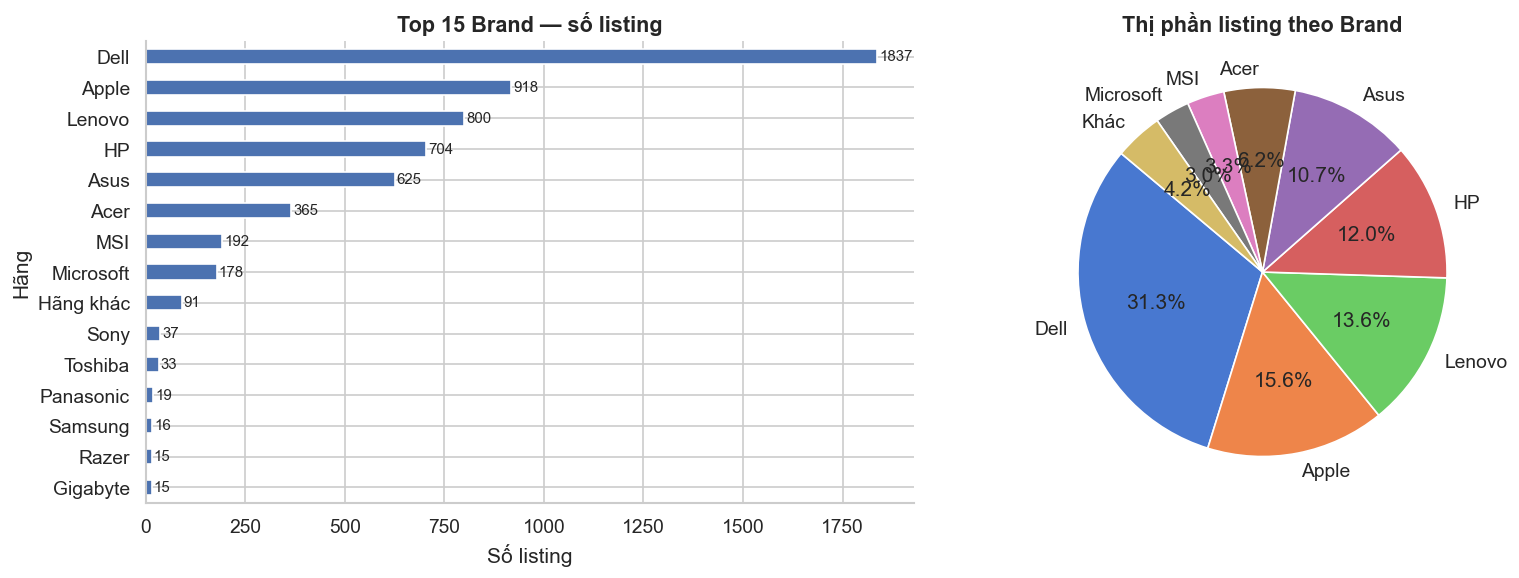

In [41]:
brand_counts = df['Hãng'].value_counts()
print(f"Số brand distinct: {brand_counts.nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top brands bar
top15 = brand_counts.head(15).sort_values()
top15.plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Top 15 Brand — số listing")
axes[0].set_xlabel("Số listing")
for i, v in enumerate(top15.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Pie: top 8 + Other
top8 = brand_counts.head(8)
other = brand_counts.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({'Khác': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=sns.color_palette("muted", len(pie_data)), startangle=140)
axes[1].set_title("Thị phần listing theo Brand")

plt.tight_layout()
plt.show()

### Brand Distribution Overview

Phân bố listing theo brand cho thấy sự tập trung rất cao vào một số hãng lớn. Dell chiếm tỷ trọng lớn nhất (31%), vượt xa các brand còn lại. Nhóm tiếp theo gồm Apple (15.6%), Lenovo (13.6%) và HP (12%), tạo thành nhóm dẫn đầu và chiếm phần lớn tổng số listing.

Các hãng như Asus và Acer nằm ở mức trung bình, trong khi các brand còn lại có tỷ trọng khá nhỏ và phân tán. Điều này cho thấy dữ liệu có sự **mất cân bằng rõ rệt theo brand**, phản ánh đúng thực tế thị trường nhưng không đồng đều.

Insight quan trọng là các phân tích và mô hình sau này sẽ bị chi phối mạnh bởi các brand lớn, trong khi các brand nhỏ có thể không đủ dữ liệu để học được pattern ổn định. Vì vậy, khi đánh giá hoặc xây dựng model, cần lưu ý đến yếu tố bias theo brand.

In [42]:
# ── Brand hiếm ─────────────────────────────────────────────────────────────────
RARE_THRESH = 30 # xấp xỉ 0.5%
rare = brand_counts[brand_counts < RARE_THRESH]
print(f"Brand có < {RARE_THRESH} listing: {len(rare)}")
display(rare.to_frame().rename(columns={'Hãng': 'count'}))

Brand có < 30 listing: 8


,count
Hãng,
Panasonic,19
Samsung,16
Gigabyte,15
Razer,15
Huawei,9
Xiaomi,7
LG,4
Honor,1


### Handling Low-frequency Brands

Một số brand có số lượng listing rất thấp (dưới 0.5% dữ liệu khoảng 30), chẳng hạn như Huawei, Xiaomi, LG và Honor. Những nhóm này không đủ dữ liệu để học được các pattern ổn định trong mô hình.

Trong bước phân tích (EDA), các brand này vẫn được giữ nguyên để phản ánh đúng đặc điểm của thị trường. Tuy nhiên, trong bước modeling, nên gộp các brand có tần suất thấp vào một nhóm chung (ví dụ: `Other`) để giảm độ thưa dữ liệu và cải thiện khả năng học của mô hình.

Cách tiếp cận này giúp cân bằng giữa việc giữ insight từ dữ liệu gốc và đảm bảo hiệu quả khi xây dựng mô hình.

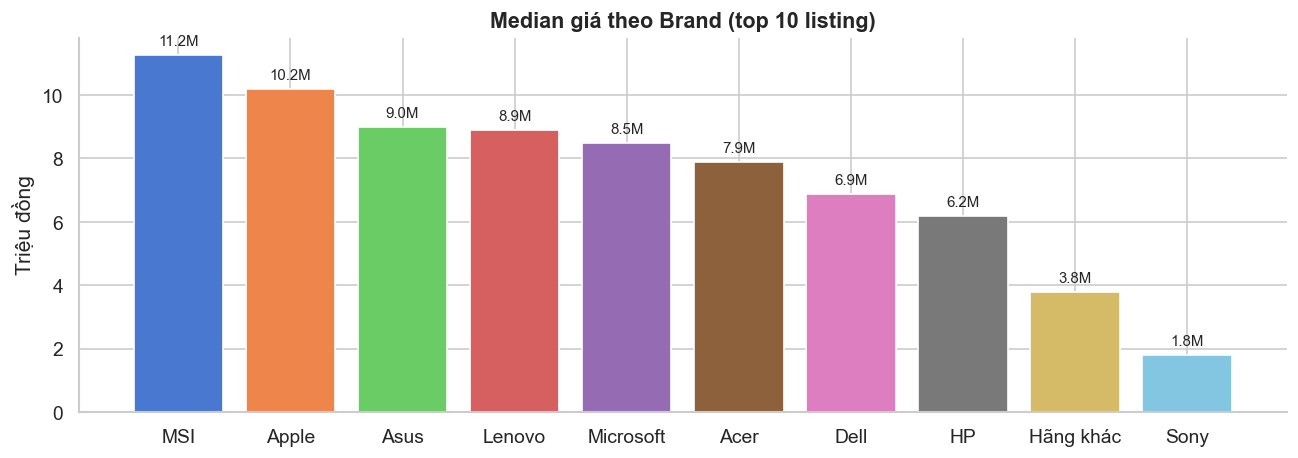

,Median (M),Mean (M),Count
Hãng,,,
MSI,11.2,12.3,192
Apple,10.2,13.7,918
Asus,9.0,11.2,625
Lenovo,8.9,11.3,800
Microsoft,8.5,9.9,178
Acer,7.9,9.7,365
Dell,6.9,8.3,1836
HP,6.2,7.4,704
Hãng khác,3.8,5.0,91


In [43]:
# ── Giá trung bình theo brand (top 10) ──────────────────────────────────────────
top10_brands = brand_counts.head(10).index
price_by_brand = (df[df['Hãng'].isin(top10_brands)]
                  .groupby('Hãng')['_price']
                  .agg(['median', 'mean', 'count'])
                  .sort_values('median', ascending=False))
price_by_brand.columns = ['Median (VNĐ)', 'Mean (VNĐ)', 'Count']

fig, ax = plt.subplots(figsize=(11, 4))
brands_sorted = price_by_brand.index.tolist()
medians_mil   = price_by_brand['Median (VNĐ)'] / 1e6
ax.bar(brands_sorted, medians_mil, color=COLORS[:len(brands_sorted)], edgecolor='white')
ax.set_title("Median giá theo Brand (top 10 listing)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
for i, v in enumerate(medians_mil):
    ax.text(i, v + 0.3, f"{v:.1f}M", ha='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
display(price_by_brand.assign(**{'Median (M)': price_by_brand['Median (VNĐ)']/1e6,
                                   'Mean (M)':   price_by_brand['Mean (VNĐ)']/1e6})[['Median (M)', 'Mean (M)', 'Count']].round(1))


### Price Distribution by Brand

Giá median theo brand cho thấy sự phân hóa rõ rệt giữa các phân khúc. Các hãng như MSI (11.2M) và Apple (10.2M) nằm ở nhóm giá cao, phản ánh positioning ở phân khúc premium hoặc gaming. Nhóm trung gồm Asus, Lenovo, Microsoft và Acer (khoảng 7.9–9.0M), trong khi Dell và HP nằm ở mức thấp hơn (~6–7M), phù hợp với phân khúc phổ thông và doanh nghiệp.

Đáng chú ý, giá mean luôn cao hơn median ở hầu hết các brand, cho thấy phân phối giá bị lệch phải (right-skewed) do tồn tại một số sản phẩm giá cao kéo trung bình lên.

Dựa trên kết quả phaan tích `price` ta cũng biết rằng có nheiefu laptop cũ đang kéo giá của phân phối xuống thấp, thcuwj tế sau khi loại outliers có thể cao hơn.

Insight quan trọng là **brand có ảnh hưởng mạnh đến giá**, không chỉ do cấu hình mà còn do định vị sản phẩm và thị trường mục tiêu. Vì vậy, `brand` là một feature quan trọng cần giữ trong mô hình để giải thích biến động của `price`.

In [44]:
# ── Brand vs spec (median) ─────────────────────────────────────────────────────
spec_by_brand = df.groupby('Hãng').agg({
    '_ram_struct_gb': 'median',
    '_storage_struct_gb': 'median'
}).rename(columns={
    '_ram_struct_gb': 'RAM_median',
    '_storage_struct_gb': 'Storage_median'
}).sort_values('RAM_median', ascending=False)

display(spec_by_brand.head(10))

,RAM_median,Storage_median
Hãng,,
Honor,32.0,1024.0
Gigabyte,16.0,512.0
Apple,16.0,256.0
Xiaomi,16.0,512.0
Razer,16.0,512.0
Lenovo,16.0,500.0
Huawei,16.0,512.0
Microsoft,16.0,256.0
MSI,16.0,512.0


### Brand vs Hardware Configuration

Cấu hình trung vị theo brand cho thấy phần lớn các hãng tập trung ở mức RAM phổ biến là 16GB và storage khoảng 256–512GB, phản ánh cấu hình tiêu chuẩn của laptop trên thị trường hiện tại.

Tuy nhiên, cần lưu ý rằng một số brand có giá trị median cao hơn (ví dụ Honor với 32GB RAM, 1TB storage) nhưng số lượng listing rất thấp, nên không mang tính đại diện và có thể bị ảnh hưởng bởi outlier.

Nhìn chung, sự khác biệt cấu hình giữa các brand không quá lớn, đặc biệt ở nhóm phổ biến, cho thấy giá không chỉ phụ thuộc vào phần cứng mà còn bị chi phối bởi brand và phân khúc sản phẩm.

In [45]:
# ── Missing rate theo brand ────────────────────────────────────────────────────
missing_by_brand = df.groupby('Hãng')[['RAM','Ổ cứng','Bộ vi xử lý']] \
    .apply(lambda x: x.isna().mean()) \
    .sort_values('RAM', ascending=False)

display(missing_by_brand.head(10))

,RAM,Ổ cứng,Bộ vi xử lý
Hãng,,,
LG,0.250000,0.250000,0.000000
Sony,0.135135,0.216216,0.162162
Samsung,0.125000,0.187500,0.000000
Hãng khác,0.120879,0.175824,0.098901
Apple,0.064270,0.092593,0.092593
Asus,0.044800,0.108800,0.051200
HP,0.041193,0.076705,0.025568
Microsoft,0.039326,0.061798,0.061798
Acer,0.035616,0.098630,0.035616


### Data Quality by Brand

Tỷ lệ missing cho thấy chất lượng dữ liệu không đồng đều giữa các brand. Một số hãng như LG, Sony và Samsung có tỷ lệ thiếu thông tin cao hơn, đặc biệt ở RAM và storage.

Tuy nhiên, cần lưu ý rằng các brand này có số lượng listing thấp, nên tỷ lệ missing dễ bị biến động và không mang tính đại diện. Ngược lại, các brand lớn như Dell, HP, Asus có tỷ lệ missing thấp và ổn định hơn, phản ánh dữ liệu đáng tin cậy hơn.

Insight quan trọng là chất lượng dữ liệu phụ thuộc vào brand và quy mô mẫu. Do đó, khi xử lý missing hoặc xây dựng mô hình, cần thận trọng với các brand có ít dữ liệu, vì chúng vừa thiếu thông tin vừa không đủ mẫu để học pattern ổn định.

In [46]:
# ── Price variance theo brand ──────────────────────────────────────────────────
price_stats = df.groupby('Hãng')['_price'].agg(['median','mean','std','count']) \
    .sort_values('median', ascending=False)

display(price_stats.head(10))

,median,mean,std,count
Hãng,,,,
Honor,21666666.0,2.166667e+07,NaN,1
Razer,16800000.0,2.070667e+07,1.965381e+07,15
Gigabyte,15500000.0,1.647533e+07,8.512745e+06,15
Xiaomi,12300000.0,1.138429e+07,2.666970e+06,7
MSI,11250000.0,1.225788e+07,6.295928e+06,192
Huawei,10490000.0,1.014222e+07,4.860043e+06,9
Apple,10200000.0,1.369390e+07,1.122104e+07,918
Asus,8999000.0,1.120438e+07,1.048186e+07,625
Lenovo,8900000.0,1.127108e+07,8.295360e+06,800


### Price Variability by Brand

Thống kê giá theo brand cho thấy sự khác biệt rõ rệt về cả mức giá và độ biến động. Một số brand như MSI và Apple có median cao, phản ánh phân khúc sản phẩm cao cấp hơn. Trong khi đó, các brand như Asus, Lenovo và Microsoft nằm ở mức trung bình.

Tuy nhiên, cần đặc biệt lưu ý rằng nhiều brand có số lượng listing rất thấp (ví dụ Honor, Xiaomi, Huawei), khiến các chỉ số như median, mean và đặc biệt là độ lệch chuẩn (std) không ổn định hoặc không có ý nghĩa đại diện. Trường hợp như Honor (count = 1) thậm chí không thể tính được độ biến động.

Ngoài ra, việc giá trung bình (mean) thường cao hơn median cho thấy phân phối giá bị lệch phải (right-skewed), do tồn tại các sản phẩm giá cao kéo trung bình lên.

Insight quan trọng là chỉ nên tin cậy các thống kê giá ở những brand có số lượng mẫu đủ lớn (như Apple, Dell, Lenovo, Asus). Các brand nhỏ vừa có dữ liệu ít vừa biến động cao, nên có thể gây nhiễu nếu đưa trực tiếp vào mô hình.

In [47]:
# ── Price segmentation ─────────────────────────────────────────────────────────
price_bins = pd.cut(
    df['_price'],
    bins=[0,5e6,10e6,20e6,1e9],
    labels=['low','mid','high','premium']
)

brand_segment = pd.crosstab(
    df['Hãng'],
    price_bins,
    normalize='index'
).sort_values('premium', ascending=False)

display(brand_segment.head(10))

_price,low,mid,high,premium
Hãng,,,,
Honor,0.000000,0.000000,0.000000,1.000000
Gigabyte,0.066667,0.200000,0.466667,0.266667
Apple,0.217865,0.276688,0.276688,0.228758
Lenovo,0.256250,0.297500,0.293750,0.152500
Razer,0.066667,0.133333,0.666667,0.133333
Asus,0.288000,0.272000,0.316800,0.123200
MSI,0.041667,0.380208,0.494792,0.083333
Acer,0.345205,0.260274,0.315068,0.079452
Microsoft,0.202247,0.432584,0.297753,0.067416


### Brand Positioning by Price Segment

Phân bố theo các mức giá cho thấy mỗi brand có định vị thị trường khác nhau. Một số hãng như MSI và Razer tập trung nhiều ở phân khúc high và premium, phản ánh dòng sản phẩm thiên về gaming hoặc hiệu năng cao.

Ngược lại, các brand như Dell, Acer và Asus có tỷ trọng lớn ở phân khúc low và mid, cho thấy sự tập trung vào thị trường phổ thông và đa dạng nhu cầu. Lenovo và Microsoft nằm ở mức cân bằng hơn giữa các phân khúc.

Cần lưu ý rằng một số brand có tỷ lệ premium cao bất thường (ví dụ Honor) nhưng số lượng mẫu rất nhỏ, nên không mang tính đại diện.

Insight quan trọng là `brand` có thể được xem như một proxy cho phân khúc giá, giúp mô hình hiểu rõ hơn về positioning sản phẩm thay vì chỉ dựa vào cấu hình.

## 8. Column: `Dòng máy`

Sub-category của brand. Nhiều giá trị distinct, có thể không nhất quán với Hãng.

Distinct dòng máy: 458
Missing:           0


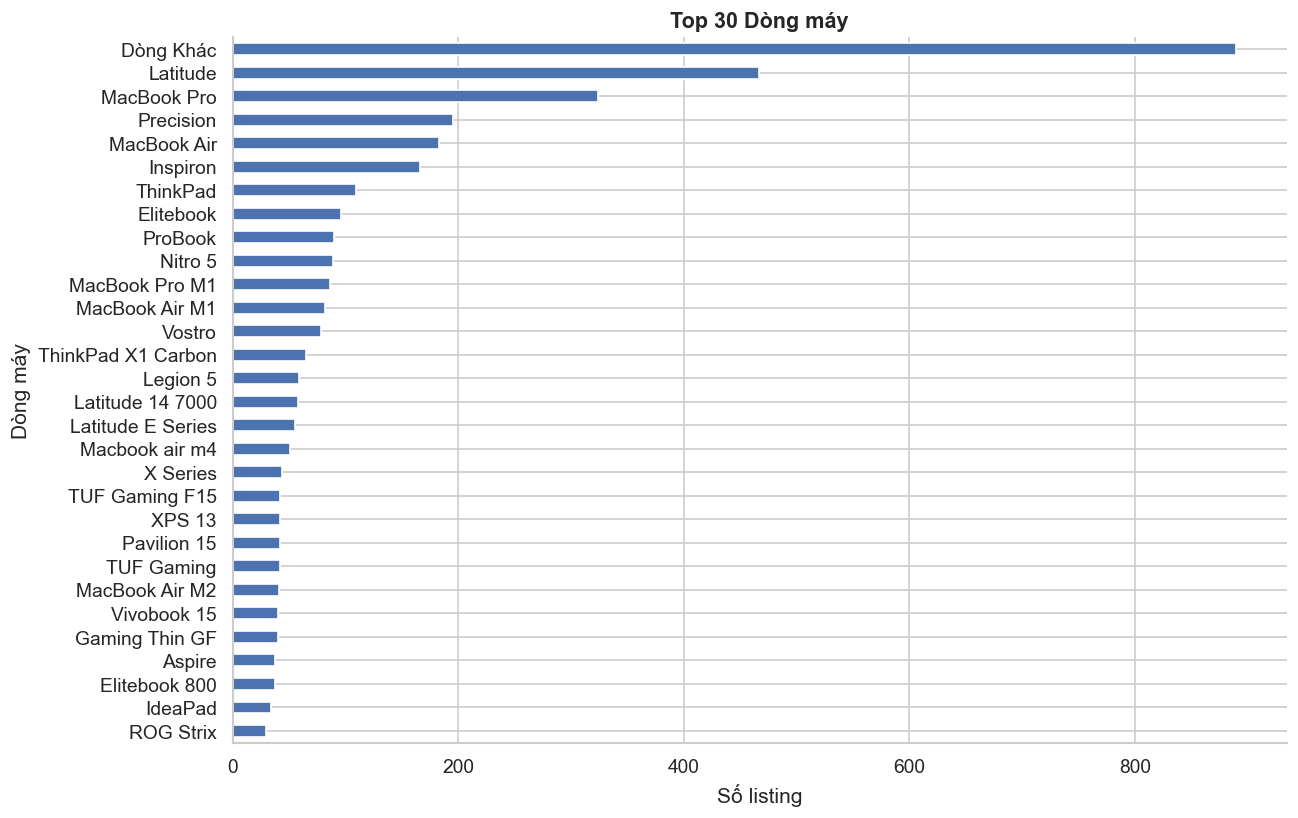

In [48]:
print(f"Distinct dòng máy: {df['Dòng máy'].nunique()}")
print(f"Missing:           {df['Dòng máy'].isna().sum()}")

top30 = df['Dòng máy'].value_counts().head(30)
fig, ax = plt.subplots(figsize=(11, 7))
top30.sort_values().plot(kind='barh', ax=ax, color=ACCENT)
ax.set_title("Top 30 Dòng máy")
ax.set_xlabel("Số listing")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### Laptop theo series

Thị trường laptop theo series thể hiện mức độ phân mảnh cao khi nhóm “Dòng khác” chiếm tỷ trọng lớn nhất, cho thấy không có một dòng sản phẩm nào thực sự chiếm ưu thế tuyệt đối. Trong các series cụ thể, Dell Latitude và MacBook Pro dẫn đầu về số lượng listing, phản ánh nhu cầu mạnh ở phân khúc doanh nghiệp và cao cấp. Hệ sinh thái MacBook với nhiều phiên bản (Pro, Air, M1, M2, M4) có độ phủ rộng và duy trì sức hút ổn định. Các dòng phổ thông như Inspiron, ThinkPad và EliteBook giữ mức hiện diện đều, cho thấy nhu cầu bền vững ở phân khúc tầm trung. Trong khi đó, các dòng gaming như Nitro, Legion, TUF hay ROG phân tán hơn, chưa có model nổi bật, thể hiện sự cạnh tranh cao và đa dạng trong phân khúc này.

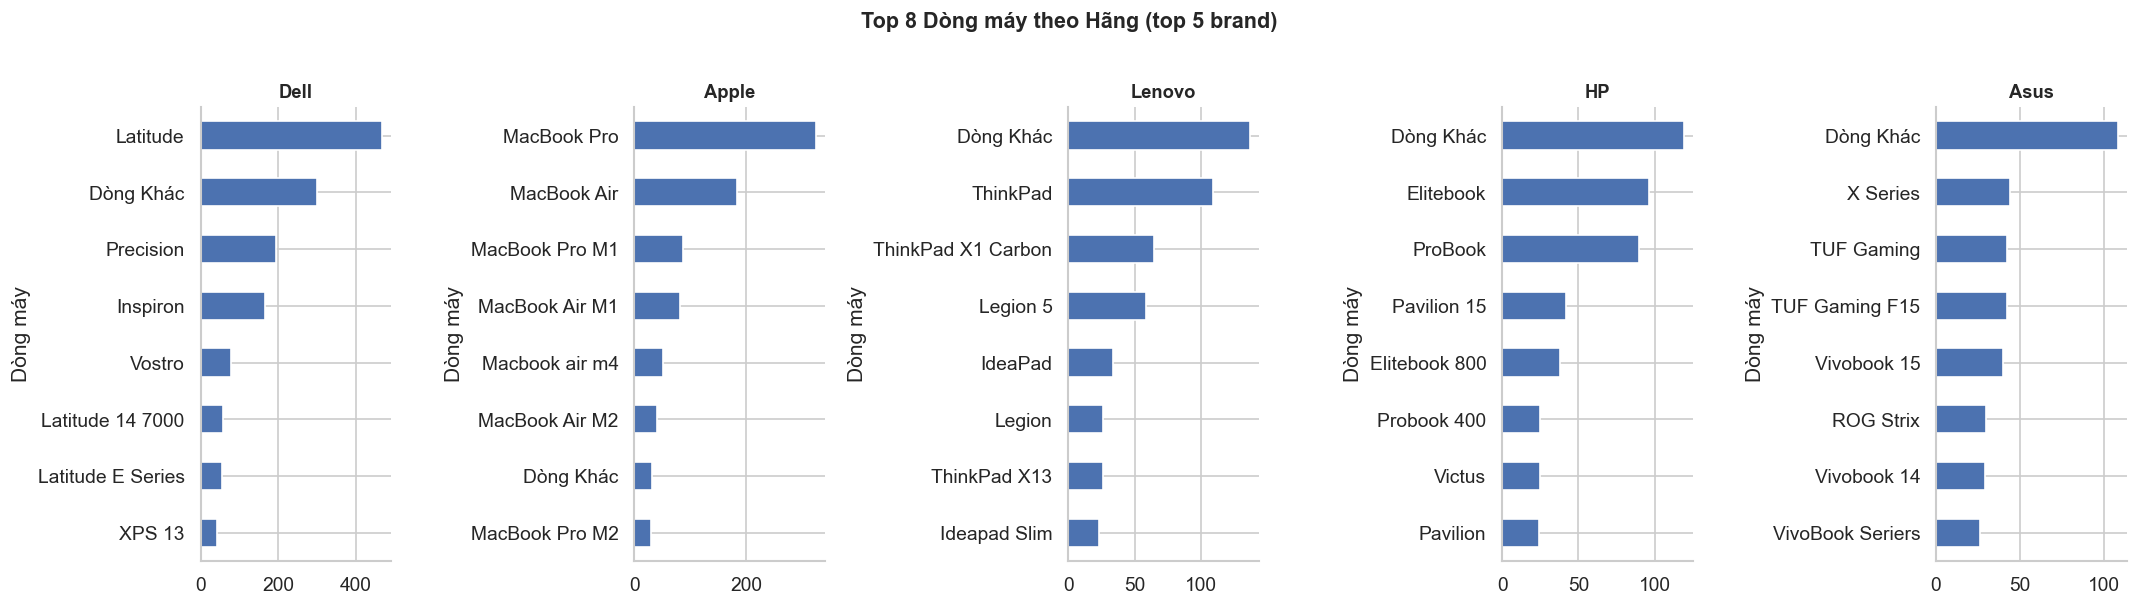

In [49]:
# ── Dòng máy theo từng Hãng (top 5 brand) ──────────────────────────────────────
top5_brands = df['Hãng'].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, brand in zip(axes, top5_brands):
    subset = df[df['Hãng'] == brand]['Dòng máy'].value_counts().head(8).sort_values()
    subset.plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(brand, fontsize=11)
    ax.set_xlabel("")
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Top 8 Dòng máy theo Hãng (top 5 brand)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Laptop theo hãng

Biểu đồ cho thấy mỗi hãng có sự tập trung rõ rệt vào một số dòng chủ lực, nhưng vẫn tồn tại mức độ phân mảnh nhất định thông qua nhóm “Dòng khác”. Với Dell, Latitude là dòng chiếm ưu thế vượt trội, cho thấy định vị mạnh ở phân khúc doanh nghiệp, trong khi Precision và Inspiron bổ trợ cho các nhu cầu chuyên môn và phổ thông. Apple thể hiện sự tập trung cao vào MacBook Pro và MacBook Air, phản ánh chiến lược sản phẩm tinh gọn nhưng hiệu quả, với các phiên bản chip M phân bổ ở mức thấp hơn. Lenovo có danh mục đa dạng hơn, trong đó ThinkPad dẫn đầu và đóng vai trò chủ lực ở phân khúc doanh nghiệp, bên cạnh các dòng như Legion và IdeaPad phục vụ gaming và phổ thông. HP phân bổ tương đối đồng đều giữa EliteBook, ProBook và Pavilion, cho thấy chiến lược trải rộng nhiều phân khúc thay vì tập trung vào một dòng duy nhất. Asus nổi bật với sự đa dạng ở cả gaming và phổ thông, khi các dòng như TUF, ROG Strix và Vivobook cùng xuất hiện nhưng không có dòng nào áp đảo hoàn toàn.

In [50]:
# Overview cột Dòng máy

model_col = "Dòng máy"
brand_col = "Hãng"
price_col = "_price"

model_df = df[df[price_col].notna()].copy()
model_df["_price_m"] = model_df[price_col] / 1_000_000

overview = pd.DataFrame({
    "metric": [
        "total_rows",
        "missing_rows",
        "missing_pct",
        "distinct_models",
        "rows_dong_khac",
        "dong_khac_pct"
    ],
    "value": [
        len(model_df),
        model_df[model_col].isna().sum(),
        round(model_df[model_col].isna().mean() * 100, 2),
        model_df[model_col].nunique(dropna=True),
        (model_df[model_col] == "Dòng Khác").sum(),
        round((model_df[model_col] == "Dòng Khác").mean() * 100, 2)
    ]
})

display(overview)

,metric,value
0,total_rows,5865.00
1,missing_rows,0.00
2,missing_pct,0.00
3,distinct_models,458.00
4,rows_dong_khac,890.00
5,dong_khac_pct,15.17


In [51]:
# Mức độ tập trung của Dòng máy: top N chiếm bao nhiêu % dữ liệu

model_counts = model_df[model_col].value_counts(dropna=False)

coverage_rows = []
for n in [5, 10, 20, 30, 50, 100]:
    coverage_rows.append({
        "Top N": n,
        "Số listing": model_counts.head(n).sum(),
        "Coverage (%)": round(model_counts.head(n).sum() / len(model_df) * 100, 2)
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

,Top N,Số listing,Coverage (%)
0,5,2059,35.11
1,10,2609,44.48
2,20,3229,55.06
3,30,3616,61.65
4,50,4110,70.08
5,100,4822,82.22


## Overview cột `Dòng máy`

Cột `Dòng máy` có số lượng giá trị phân biệt rất lớn (458 unique trên ~5.8k dòng), cho thấy đây là một feature có **high cardinality**. Không có giá trị missing, nhưng tồn tại khoảng **15.17% thuộc nhóm “Dòng Khác”**, phản ánh việc dữ liệu bị gom nhóm hoặc không được chuẩn hóa đầy đủ.

Điều này cho thấy hai vấn đề chính: (1) feature chứa nhiều thông tin chi tiết nhưng phân tán mạnh (long-tail), và (2) một phần đáng kể thông tin bị mất do gom vào “Dòng Khác”. Trong modeling, cần cân nhắc kỹ cách encode (tránh one-hot trực tiếp) và có thể cần grouping hoặc kết hợp với `Hãng` để khai thác tốt hơn tín hiệu từ feature này.

,count_bucket,num_models
0,1,138
1,2,67
2,3-5,97
3,6-10,63
4,11-20,44
5,21-50,31
6,51-100,11
7,>100,7


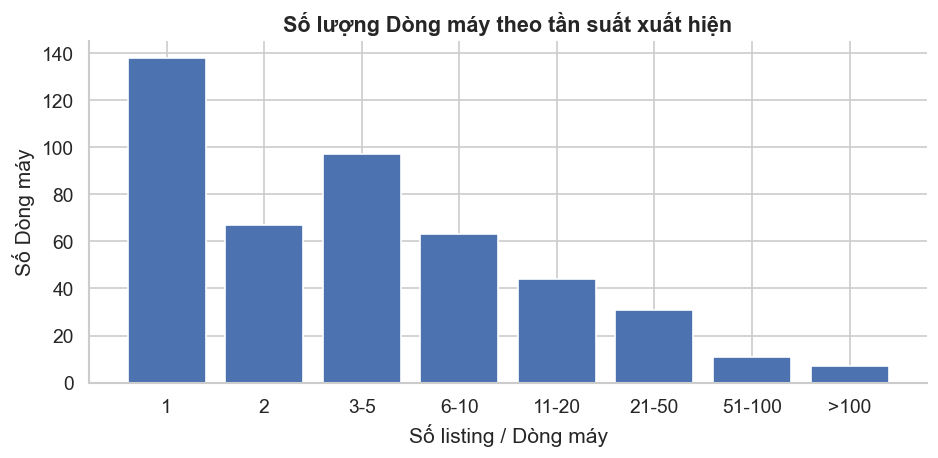

In [52]:
# Long-tail distribution: nhiều Dòng máy có rất ít listing hay không?

count_bucket = pd.cut(
    model_counts,
    bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf],
    labels=["1", "2", "3-5", "6-10", "11-20", "21-50", "51-100", ">100"]
)

bucket_summary = (
    pd.DataFrame({
        "count_bucket": count_bucket,
        "num_models": 1
    })
    .groupby("count_bucket", observed=False)
    .sum()
    .reset_index()
)

display(bucket_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bucket_summary["count_bucket"].astype(str), bucket_summary["num_models"], color=ACCENT)
ax.set_title("Số lượng Dòng máy theo tần suất xuất hiện")
ax.set_xlabel("Số listing / Dòng máy")
ax.set_ylabel("Số Dòng máy")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Long-tail distribution của `Dòng máy`

Phân tích tần suất xuất hiện cho thấy `Dòng máy` có phân phối **long-tail rất rõ rệt**. Cụ thể, có tới 138 dòng máy chỉ xuất hiện đúng 1 lần và phần lớn các dòng máy (≈300+) xuất hiện dưới 10 lần. Trong khi đó, chỉ có một số rất ít dòng máy phổ biến (7 dòng >100 listing) chiếm phần lớn dữ liệu.

Điều này cho thấy feature này vừa **giàu thông tin nhưng cực kỳ phân tán**, dẫn đến việc nhiều category không đủ dữ liệu để mô hình học ổn định. Đây là đặc trưng điển hình của high-cardinality categorical feature trong dữ liệu marketplace.

Vì vậy, trong bước modeling, không nên sử dụng one-hot encoding trực tiếp cho toàn bộ `Dòng máy`. Thay vào đó, cần cân nhắc các chiến lược như grouping các dòng hiếm (rare categories), kết hợp với `Hãng`, hoặc sử dụng các phương pháp encoding phù hợp (target/frequency encoding) để tận dụng signal mà không làm tăng sparsity quá mức.

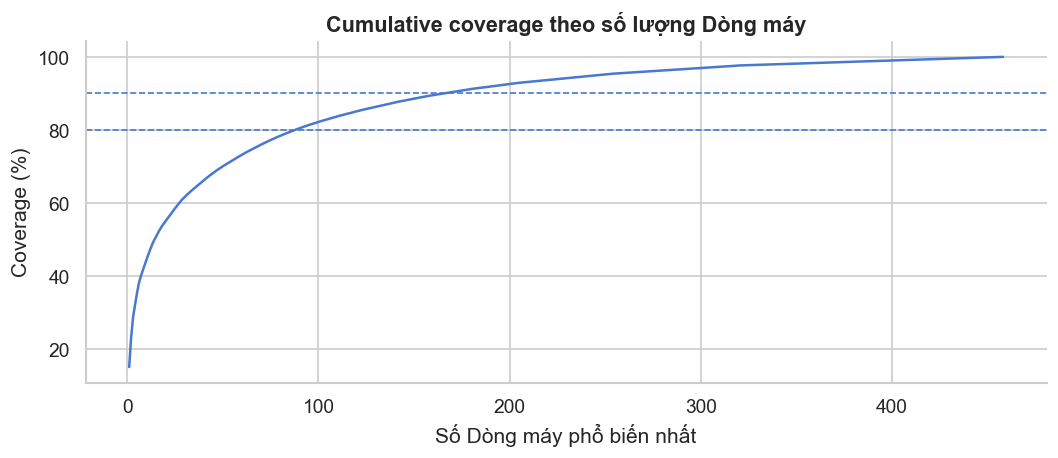

Số Dòng máy cần để cover 80% dữ liệu: 88
Số Dòng máy cần để cover 90% dữ liệu: 166


In [53]:
# Pareto / cumulative coverage của Dòng máy

model_counts_sorted = model_counts.sort_values(ascending=False)
cum_coverage = model_counts_sorted.cumsum() / model_counts_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cum_coverage) + 1), cum_coverage.values)
ax.axhline(80, linestyle="--", linewidth=1)
ax.axhline(90, linestyle="--", linewidth=1)
ax.set_title("Cumulative coverage theo số lượng Dòng máy")
ax.set_xlabel("Số Dòng máy phổ biến nhất")
ax.set_ylabel("Coverage (%)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

n_80 = int(np.argmax(cum_coverage.values >= 80) + 1)
n_90 = int(np.argmax(cum_coverage.values >= 90) + 1)

print(f"Số Dòng máy cần để cover 80% dữ liệu: {n_80}")
print(f"Số Dòng máy cần để cover 90% dữ liệu: {n_90}")

## Cumulative coverage của `Dòng máy`

Kết quả cho thấy cần khoảng **88 dòng máy phổ biến nhất để cover 80% dữ liệu** và **166 dòng để đạt 90% coverage**. So với tổng số 458 dòng máy, điều này xác nhận rằng dữ liệu có **long-tail mạnh**, với phần lớn các dòng máy xuất hiện rất ít và chỉ một tập nhỏ đóng góp phần lớn số lượng listing.

Điều này có ý nghĩa quan trọng trong modeling: nếu giữ nguyên toàn bộ category, phần lớn sẽ rơi vào nhóm hiếm và không đủ dữ liệu để học ổn định. Vì vậy, cần cân nhắc **giảm cardinality** (ví dụ: grouping rare categories hoặc chỉ giữ top-N) để tập trung vào các dòng máy có đủ signal, đồng thời hạn chế sparsity và overfitting.

,Hãng,count,dong_khac_count,dong_khac_pct,distinct_models
0,Hãng khác,91,91,100.00,1
1,Toshiba,33,25,75.76,5
2,LG,4,2,50.00,2
3,Panasonic,19,9,47.37,2
4,Razer,15,6,40.00,3
5,Sony,37,12,32.43,5
6,Samsung,16,4,25.00,7
7,Asus,625,108,17.28,76
8,Lenovo,800,137,17.12,86
9,HP,704,119,16.90,74


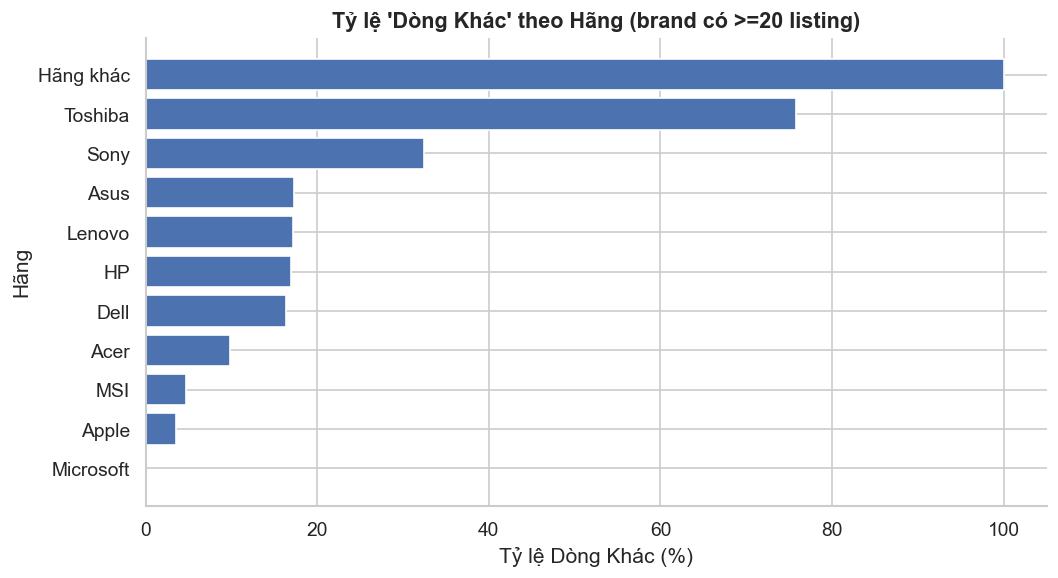

In [54]:
# Tỷ lệ "Dòng Khác" theo từng Hãng

dong_khac_by_brand = (
    model_df
    .assign(is_dong_khac=model_df[model_col].eq("Dòng Khác"))
    .groupby(brand_col)
    .agg(
        count=(model_col, "size"),
        dong_khac_count=("is_dong_khac", "sum"),
        dong_khac_pct=("is_dong_khac", lambda s: round(s.mean() * 100, 2)),
        distinct_models=(model_col, "nunique")
    )
    .sort_values(["dong_khac_pct", "count"], ascending=[False, False])
    .reset_index()
)

display(dong_khac_by_brand.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = dong_khac_by_brand[dong_khac_by_brand["count"] >= 20].sort_values("dong_khac_pct").tail(15)
ax.barh(plot_df[brand_col], plot_df["dong_khac_pct"], color=ACCENT)
ax.set_title("Tỷ lệ 'Dòng Khác' theo Hãng (brand có >=20 listing)")
ax.set_xlabel("Tỷ lệ Dòng Khác (%)")
ax.set_ylabel("Hãng")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Tỷ lệ “Dòng Khác” theo `Hãng`

Phân tích cho thấy tỷ lệ “Dòng Khác” khác nhau đáng kể giữa các hãng. Một số hãng nhỏ hoặc ít dữ liệu (như Toshiba, Sony) có tỷ lệ rất cao (30–75%), cho thấy việc **thiếu chuẩn hóa hoặc thiếu thông tin dòng máy cụ thể**. Ngược lại, các hãng lớn như Apple (3.5%), MSI (4.7%), Acer (9.9%) có tỷ lệ thấp hơn, phản ánh dữ liệu được phân loại rõ ràng và nhất quán hơn.

Đối với các hãng lớn như Dell, HP, Lenovo, Asus, tỷ lệ “Dòng Khác” vẫn ở mức ~16–17%, cho thấy vẫn còn một phần dữ liệu bị gom nhóm, có thể làm mất thông tin chi tiết về dòng máy. Trong khi đó, Microsoft gần như không có “Dòng Khác”, cho thấy cấu trúc sản phẩm rõ ràng và dễ phân loại.

Nhìn chung, “Dòng Khác” không phân bố đồng đều giữa các hãng, và thường cao ở các hãng ít phổ biến hoặc dữ liệu không được chuẩn hóa tốt. Điều này cho thấy cần cẩn trọng khi sử dụng `Dòng máy` riêng lẻ; nên kết hợp với `Hãng` hoặc xử lý riêng nhóm “Dòng Khác” để tránh mất tín hiệu trong modeling.

In [55]:
# Price summary theo Dòng máy phổ biến

MIN_COUNT_MODEL = 30

model_price_summary = (
    model_df
    .groupby(model_col)
    .agg(
        count=("title", "count"),
        median_price_m=("_price_m", "median"),
        mean_price_m=("_price_m", "mean"),
        p25_price_m=("_price_m", lambda s: s.quantile(0.25)),
        p75_price_m=("_price_m", lambda s: s.quantile(0.75)),
        brand_count=(brand_col, "nunique")
    )
    .query("count >= @MIN_COUNT_MODEL")
    .sort_values("median_price_m", ascending=False)
    .round(2)
    .reset_index()
)

display(model_price_summary.head(10))

,Dòng máy,count,median_price_m,mean_price_m,p25_price_m,p75_price_m,brand_count
0,MacBook Pro M2,30,23.50,24.59,17.60,31.50,1
1,Legion 5,59,22.99,22.40,17.85,26.99,1
2,Macbook air m4,51,22.49,23.46,21.60,24.70,1
3,MacBook Pro M1,86,20.65,21.18,13.55,25.88,1
4,MacBook Air M2,41,16.50,16.66,14.90,17.99,1
5,Precision,195,13.50,13.80,8.90,17.50,1
6,ROG Strix,30,13.15,14.55,9.00,19.00,1
7,TUF Gaming F15,42,12.20,12.50,10.58,14.57,1
8,Nitro 5,89,11.00,12.08,9.00,14.90,1
9,MacBook Air M1,82,10.75,10.98,9.92,11.98,1


## Price signal theo `Dòng máy` phổ biến

Kết quả cho thấy `Dòng máy` mang **signal giá rất rõ ràng và có tính phân tầng**. Các dòng như MacBook Pro M2, Legion 5, MacBook Air M4 nằm ở phân khúc cao (median 22–23M), trong khi các dòng gaming tầm trung như Nitro 5, TUF Gaming F15 và MacBook Air M1 nằm ở mức thấp hơn (10–12M).

Đáng chú ý, các dòng máy phổ biến đều có **brand_count = 1**, cho thấy `Dòng máy` gần như gắn chặt với một hãng cụ thể. Điều này đồng nghĩa rằng feature này thực chất là một dạng **fine-grained brand proxy**, phản ánh positioning sản phẩm chi tiết hơn so với chỉ dùng `Hãng`.

Ngoài ra, khoảng giá (P25–P75) của từng dòng tương đối ổn định, cho thấy giá trong cùng một dòng máy không quá phân tán, giúp mô hình dễ học hơn so với các feature bị nhiễu. Tuy nhiên, vẫn tồn tại một số độ lệch (mean > median), cho thấy có outlier ở phía giá cao.

Nhìn chung, `Dòng máy` là một feature rất mạnh cho bài toán dự đoán giá, nhưng do high cardinality, cần xử lý phù hợp (grouping, target encoding hoặc kết hợp với `Hãng`) để tận dụng signal mà không gây sparsity.

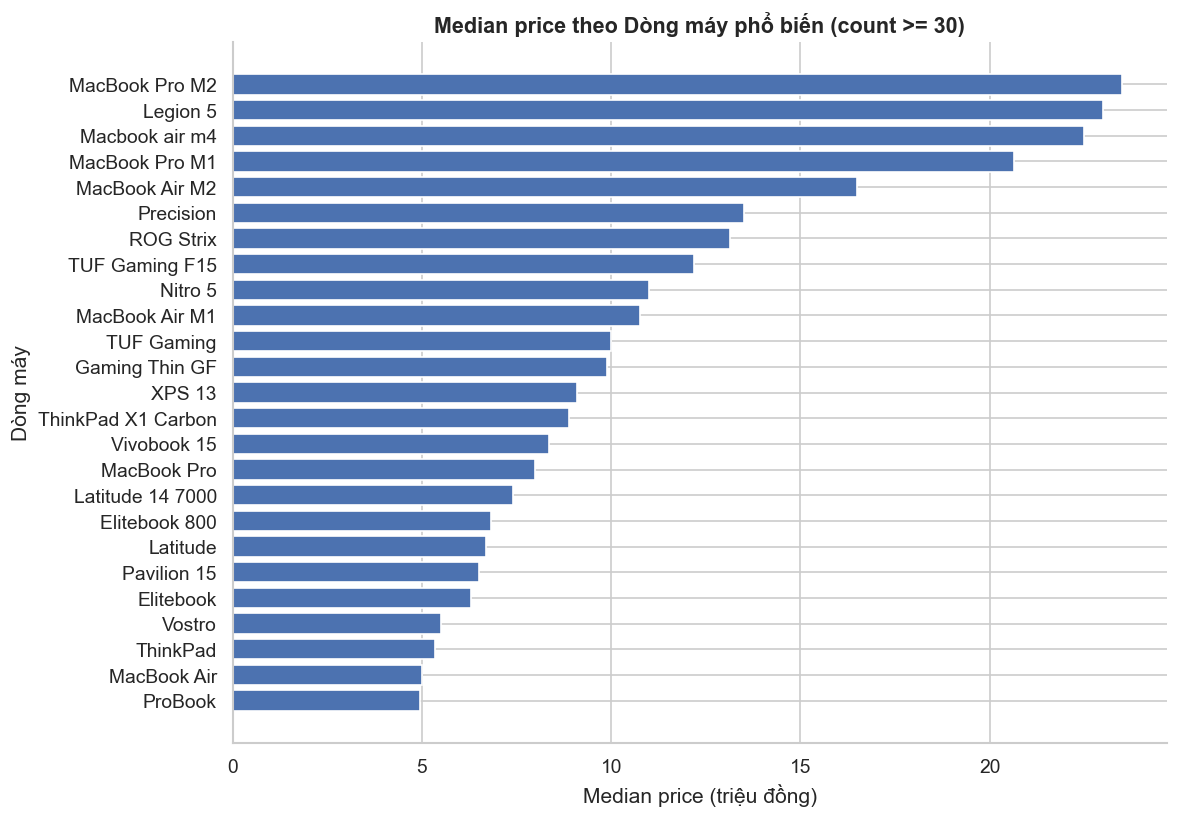

In [56]:
# Plot median price của các Dòng máy phổ biến

plot_df = model_price_summary.sort_values("median_price_m").tail(25)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df[model_col], plot_df["median_price_m"], color=ACCENT)
ax.set_title(f"Median price theo Dòng máy phổ biến (count >= {MIN_COUNT_MODEL})")
ax.set_xlabel("Median price (triệu đồng)")
ax.set_ylabel("Dòng máy")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Phân tầng giá theo `Dòng máy` (median)

Biểu đồ cho thấy sự **phân tầng giá rất rõ ràng giữa các dòng máy**, gần như tạo thành các cụm segment tự nhiên. Nhóm cao cấp gồm MacBook Pro (M1/M2), MacBook Air thế hệ mới và Legion 5 có median >20M, trong khi nhóm gaming tầm trung (ROG, TUF, Nitro) nằm khoảng 10–15M. Các dòng business và phổ thông như Latitude, Elitebook, ProBook, ThinkPad tập trung ở mức thấp hơn (~5–10M).

Điều này cho thấy `Dòng máy` không chỉ là một categorical feature đơn thuần mà thực chất phản ánh **product positioning và price segment** khá rõ. So với `Hãng`, feature này mang tính phân biệt mạnh hơn vì capture được sự khác biệt trong từng series sản phẩm.

Tuy nhiên, cũng thấy sự overlap nhẹ giữa các nhóm (ví dụ: gaming vs business), cho thấy giá không hoàn toàn tách biệt mà còn phụ thuộc vào cấu hình và tình trạng. Vì vậy, `Dòng máy` nên được sử dụng kết hợp với các feature khác thay vì xem như một rule cứng để phân loại giá.

In [57]:
# Price theo cặp Hãng + Dòng máy để tránh Dòng máy bị lẫn giữa nhiều hãng

MIN_COUNT_PAIR = 20

brand_model_price = (
    model_df
    .groupby([brand_col, model_col])
    .agg(
        count=("title", "count"),
        median_price_m=("_price_m", "median"),
        mean_price_m=("_price_m", "mean"),
        p25_price_m=("_price_m", lambda s: s.quantile(0.25)),
        p75_price_m=("_price_m", lambda s: s.quantile(0.75))
    )
    .query("count >= @MIN_COUNT_PAIR")
    .sort_values("median_price_m", ascending=False)
    .round(2)
    .reset_index()
)

display(brand_model_price.head(10))

,Hãng,Dòng máy,count,median_price_m,mean_price_m,p25_price_m,p75_price_m
0,Apple,MacBook Pro M2,30,23.50,24.59,17.60,31.50
1,Lenovo,Legion 5,59,22.99,22.40,17.85,26.99
2,Apple,Macbook air m4,51,22.49,23.46,21.60,24.70
3,Apple,MacBook Pro M1,86,20.65,21.18,13.55,25.88
4,Lenovo,Legion,26,18.74,20.00,16.14,24.12
5,Apple,MacBook Air M2,41,16.50,16.66,14.90,17.99
6,Acer,Nitro v15,26,15.50,16.29,14.12,17.88
7,Dell,Precision 15 5000,22,14.75,16.64,12.15,19.12
8,Apple,Dòng Khác,32,14.50,21.55,5.37,28.75
9,HP,Victus,25,13.99,14.17,12.00,16.90


In [58]:
# Các cặp Hãng + Dòng máy có độ phân tán giá lớn

brand_model_spread = brand_model_price.copy()
brand_model_spread["iqr_price_m"] = (
    brand_model_spread["p75_price_m"] - brand_model_spread["p25_price_m"]
).round(2)

brand_model_spread = brand_model_spread.sort_values(
    ["iqr_price_m", "count"],
    ascending=[False, False]
)

display(brand_model_spread.head(10))

,Hãng,Dòng máy,count,median_price_m,mean_price_m,p25_price_m,p75_price_m,iqr_price_m
8,Apple,Dòng Khác,32,14.50,21.55,5.37,28.75,23.38
23,Lenovo,Dòng Khác,137,8.50,10.64,3.60,17.50,13.90
0,Apple,MacBook Pro M2,30,23.50,24.59,17.60,31.50,13.90
3,Apple,MacBook Pro M1,86,20.65,21.18,13.55,25.88,12.33
36,Apple,MacBook,22,5.80,11.95,3.50,15.40,11.90
13,Dell,XPS,27,12.40,11.71,5.80,17.20,11.40
11,Asus,ROG Strix,30,13.15,14.55,9.00,19.00,10.00
1,Lenovo,Legion 5,59,22.99,22.40,17.85,26.99,9.14
10,Dell,Precision,195,13.50,13.80,8.90,17.50,8.60
22,Lenovo,ThinkPad X1 Carbon,65,8.89,10.24,5.59,13.80,8.21


## Price signal theo cặp `Hãng + Dòng máy`

Khi kết hợp `Hãng` và `Dòng máy`, tín hiệu giá trở nên **rõ ràng và ổn định hơn so với dùng riêng lẻ từng feature**. Các cặp như Apple–MacBook Pro M2, Lenovo–Legion 5 hay Apple–MacBook Air M4 đều nằm ở phân khúc cao với median 20–23M, trong khi các cặp như Acer–Nitro, Dell–Precision hoặc HP–Victus nằm ở mức thấp hơn (13–16M).

Điều này xác nhận rằng `Dòng máy` thực chất đã gắn chặt với `Hãng`, và việc tách riêng hai feature có thể làm mất một phần ngữ nghĩa. Khi ghép lại, mỗi cặp đại diện cho một **product line cụ thể**, giúp mô hình hiểu rõ hơn về positioning và phân khúc giá.

Ngoài ra, khoảng giá (P25–P75) của từng cặp tương đối ổn định, cho thấy mức độ biến động trong cùng một product line không quá lớn. Tuy nhiên, vẫn có một số trường hợp như “Apple – Dòng Khác” có độ phân tán cao, phản ánh việc gom nhóm làm mất thông tin chi tiết.

Nhìn chung, `Hãng + Dòng máy` là một representation mạnh hơn so với từng feature riêng lẻ. Trong modeling, nên cân nhắc sử dụng kết hợp này (hoặc encoding tương đương) để tận dụng tối đa signal mà không bị nhiễu bởi high-cardinality hoặc grouping thô như “Dòng Khác”.

In [59]:
# Kiểm tra Dòng máy có xuất hiện dưới nhiều Hãng khác nhau

model_brand_mix = (
    model_df
    .groupby(model_col)
    .agg(
        count=("title", "count"),
        num_brands=(brand_col, "nunique"),
        brands=(brand_col, lambda s: ", ".join(s.dropna().value_counts().head(5).index))
    )
    .query("num_brands > 1")
    .sort_values(["num_brands", "count"], ascending=[False, False])
    .reset_index()
)

display(model_brand_mix.head(30))

,Dòng máy,count,num_brands,brands
0,Dòng Khác,890,14,"Dell, Lenovo, HP, Asus, Hãng khác"
1,dòng khác,7,3,"Gigabyte, Xiaomi, Honor"
2,Dòng khác,7,2,"Huawei, Microsoft"
3,G Series,7,2,"Dell, Asus"
4,Chromebook 14,3,2,"HP, Asus"


## Độ phân tán giá theo `Hãng + Dòng máy`

Phân tích IQR cho thấy mức độ biến động giá khác nhau đáng kể giữa các cặp `Hãng + Dòng máy`. Đáng chú ý, các nhóm “Dòng Khác” có IQR rất cao (Apple ~23.38, Lenovo ~13.90), cho thấy đây là các nhóm **rất không đồng nhất**, bị trộn nhiều sản phẩm khác nhau nên mất tính đại diện.

Ngay cả trong cùng một hãng, các dòng cụ thể như MacBook Pro M2, Legion 5 hay Precision có IQR thấp hơn đáng kể, phản ánh giá ổn định hơn và mang tính “product line” rõ ràng. Ngược lại, các dòng như MacBook (chung chung) hoặc XPS có IQR cao hơn, cho thấy có sự pha trộn giữa nhiều cấu hình hoặc thế hệ.

Điều này củng cố hai điểm quan trọng: (1) các dòng máy cụ thể cung cấp signal giá ổn định hơn, và (2) các nhóm bị gom (như “Dòng Khác”) hoặc tên gọi không đủ chi tiết sẽ làm tăng noise. Trong modeling, cần ưu tiên giữ các dòng máy rõ ràng và xử lý riêng các nhóm có độ phân tán cao để tránh làm giảm chất lượng dự đoán.

In [60]:
# Kiểm tra biến thể tên Dòng máy sau khi normalize text đơn giản

def normalize_model_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", "", x)
    return x

model_df["_model_norm"] = model_df[model_col].apply(normalize_model_name)

model_name_variants = (
    model_df
    .dropna(subset=["_model_norm"])
    .groupby("_model_norm")
    .agg(
        raw_variants=(model_col, lambda s: sorted(set(s.dropna()))),
        n_variants=(model_col, lambda s: len(set(s.dropna()))),
        count=(model_col, "count")
    )
    .query("n_variants > 1")
    .sort_values(["n_variants", "count"], ascending=[False, False])
    .reset_index()
)

display(model_name_variants.head(30))

,_model_norm,raw_variants,n_variants,count
0,dng khc,"[Dòng Khác, Dòng khác, dòng khác]",3,904
1,surface pro 7,"[Surface Pro 7, Surface Pro 7+]",2,19
2,chromebook,"[ChromeBook, Chromebook]",2,5
3,chromebook 14,"[ChromeBook 14, Chromebook 14]",2,4
4,chromebook 15,"[ChromeBook 15, Chromebook 15]",2,3


## Biến thể tên trong `Dòng máy`

Kết quả cho thấy tồn tại các biến thể tên cho cùng một dòng máy, chủ yếu do khác biệt về viết hoa/thường, ký tự đặc biệt hoặc cách ghi không nhất quán (ví dụ: “Surface Pro 7” vs “Surface Pro 7+”, “Chromebook” vs “ChromeBook”). Trường hợp “Dòng Khác” cũng xuất hiện dưới nhiều dạng viết khác nhau.

Mặc dù số lượng biến thể không quá lớn, nhưng chúng có thể gây phân mảnh dữ liệu và làm tăng cardinality không cần thiết. Điều này đặc biệt quan trọng với các dòng máy ít dữ liệu, nơi việc tách thành nhiều biến thể sẽ làm giảm khả năng học của mô hình.

Vì vậy, cần cân nhắc bước **chuẩn hóa tên (text normalization)** trong preprocessing để gom các biến thể về cùng một dạng, giúp giảm sparsity và cải thiện chất lượng feature.

In [61]:
# Kiểm tra các dòng "Dòng Khác" nhưng title có chứa series phổ biến

series_keywords = [
    "latitude", "inspiron", "precision", "xps", "vostro", "alienware",
    "macbook", "thinkpad", "ideapad", "legion", "yoga",
    "elitebook", "probook", "pavilion", "victus", "spectre",
    "vivobook", "zenbook", "rog", "tuf", "aspire", "swift", "nitro"
]

pattern = r"(" + "|".join(series_keywords) + r")"

dong_khac_with_series = model_df[
    (model_df[model_col] == "Dòng Khác") &
    (model_df["title"].str.lower().str.contains(pattern, regex=True, na=False))
].copy()

dong_khac_with_series["_matched_series"] = dong_khac_with_series["title"].str.lower().str.extract(pattern)

print(f"'Dòng Khác' nhưng title có chứa series phổ biến: {len(dong_khac_with_series)} rows")
display(
    dong_khac_with_series[
        ["title", brand_col, model_col, "_matched_series", "price", "Bộ vi xử lý", "RAM", "Ổ cứng"]
    ].head(10)
)

'Dòng Khác' nhưng title có chứa series phổ biến: 324 rows


,title,Hãng,Dòng máy,_matched_series,price,Bộ vi xử lý,RAM,Ổ cứng
13,"Dell Latitude 5320 2in1 i5 1145G7 16G/256G/13""X360",Dell,Dòng Khác,latitude,8.700.000 đ,Intel Core i7,16 GB,256 GB
29,Dell Latitude 5420 i5-1145G7 14 inch FHD 8GB/256GB,Dell,Dòng Khác,latitude,7.000.000 đ,Intel Core i5,8 GB,256 GB
58,M cần bán Thinkpad L390 i5-8250U 8GB/256GB,Lenovo,Dòng Khác,thinkpad,3.800.000 đ,Intel Core i5,8 GB,256 GB
69,Dell Latitude 5300 i7-8665U 13.3 inch 8GB/256GB,Dell,Dòng Khác,latitude,5.000.000 đ,Intel Core i7,8 GB,256 GB
81,Acer Aspire A514-54 i5 14 inch 8GB/512GB,Acer,Dòng Khác,aspire,6.800.000 đ,Intel Core i5,8 GB,512 GB
97,"Lenovo ThinkPad X230 Hỏng pin, kênh bàn phím",Lenovo,Dòng Khác,thinkpad,1.300.000 đ,Intel Core i5,4 GB,128 GB
123,Dell Precision M4800 i7-4810QM 16GB/240GB card 2gb,Dell,Dòng Khác,precision,2.999.000 đ,Intel Core i7,16 GB,250 GB
126,"Dell Latitude 5510 i7 15.6 inch 16GB/256GB 15"" FHD",Dell,Dòng Khác,latitude,6.999.000 đ,Intel Core i7,16 GB,256 GB
127,Dell Latitude 5480 i5-6300U 8GB,Dell,Dòng Khác,latitude,1.800.000 đ,Intel Core i5,8 GB,NaN
144,Acer Nitro Lite 16 NL16 I7-13620H RTX 3050 6GB,Acer,Dòng Khác,nitro,17.500.000 đ,Intel Core i7,16 GB,512 GB


In [62]:
# Mô phỏng grouping rare Dòng máy để giảm high-cardinality

RARE_MODEL_THRESHOLD = 10

model_freq = model_df[model_col].value_counts(dropna=False)
rare_models = model_freq[model_freq < RARE_MODEL_THRESHOLD].index

model_df["_model_grouped"] = model_df[model_col].where(
    ~model_df[model_col].isin(rare_models),
    "Rare/Other"
)

grouping_summary = pd.DataFrame({
    "metric": [
        "distinct_before",
        "distinct_after",
        "rare_model_count",
        "rows_grouped_to_rare",
        "rows_grouped_pct"
    ],
    "value": [
        model_df[model_col].nunique(dropna=True),
        model_df["_model_grouped"].nunique(dropna=True),
        len(rare_models),
        model_df[model_col].isin(rare_models).sum(),
        round(model_df[model_col].isin(rare_models).mean() * 100, 2)
    ]
})

display(grouping_summary)
display(model_df["_model_grouped"].value_counts().head(10))

,metric,value
0,distinct_before,458.00
1,distinct_after,101.00
2,rare_model_count,358.00
3,rows_grouped_to_rare,1043.00
4,rows_grouped_pct,17.78


_model_grouped
Rare/Other     1043
Dòng Khác       890
Latitude        467
MacBook Pro     324
Precision       195
MacBook Air     183
Inspiron        166
ThinkPad        109
Elitebook        96
ProBook          90
Name: count, dtype: int64

## Giảm cardinality của `Dòng máy` bằng grouping

Việc grouping các dòng máy hiếm giúp giảm số lượng category từ **458 xuống còn 101**, tức giảm đáng kể độ phức tạp của feature. Khoảng **78% số dòng máy là hiếm** (358/458), nhưng chỉ chiếm ~17.78% số dòng dữ liệu, cho thấy phần lớn signal vẫn nằm ở các dòng phổ biến.

Điều này xác nhận rằng chiến lược grouping rare categories là hợp lý: vừa giảm sparsity, vừa giữ lại phần lớn thông tin quan trọng. Tuy nhiên, cần lưu ý rằng nhóm “Rare/Other” sau khi gom sẽ có tính không đồng nhất cao, nên có thể mang nhiều noise và cần được xử lý cẩn thận trong modeling.

In [63]:
# So sánh price giữa Dòng Khác, Rare/Other và các dòng phổ biến

grouped_price_summary = (
    model_df
    .groupby("_model_grouped")
    .agg(
        count=("title", "count"),
        median_price_m=("_price_m", "median"),
        mean_price_m=("_price_m", "mean"),
        p25_price_m=("_price_m", lambda s: s.quantile(0.25)),
        p75_price_m=("_price_m", lambda s: s.quantile(0.75))
    )
    .sort_values("count", ascending=False)
    .round(2)
    .reset_index()
)

display(grouped_price_summary.head(10))

,_model_grouped,count,median_price_m,mean_price_m,p25_price_m,p75_price_m
0,Rare/Other,1043,9.50,12.03,5.00,15.90
1,Dòng Khác,890,4.72,6.86,2.50,7.99
2,Latitude,467,6.70,6.83,4.70,8.50
3,MacBook Pro,324,8.00,10.63,5.00,11.42
4,Precision,195,13.50,13.80,8.90,17.50
5,MacBook Air,183,5.00,6.35,3.14,6.97
6,Inspiron,166,4.68,5.82,2.65,8.20
7,ThinkPad,109,5.35,7.36,3.90,10.00
8,Elitebook,96,6.30,7.21,4.50,8.27
9,ProBook,90,4.95,5.61,3.20,7.00


## Price signal sau khi grouping `Dòng máy`

Sau khi grouping các dòng máy hiếm, tín hiệu giá vẫn được giữ khá tốt ở các nhóm phổ biến. Các dòng như Precision (~13.5M), MacBook Pro (~8–10M), Latitude (~6–7M) vẫn thể hiện rõ phân khúc giá riêng, cho thấy việc giảm cardinality không làm mất các pattern quan trọng.

Tuy nhiên, hai nhóm tổng hợp là “Rare/Other” và “Dòng Khác” có đặc điểm rất khác nhau. “Rare/Other” có median ~9.5M và độ phân tán lớn, phản ánh việc gom nhiều dòng máy khác nhau nhưng vẫn giữ được một phần signal giá. Trong khi đó, “Dòng Khác” có median thấp hơn (~4.7M) và phân phối hẹp hơn, cho thấy đây có thể là nhóm bị thiếu thông tin hoặc thiên về các sản phẩm giá rẻ.

Điều này cho thấy grouping là một bước hợp lý để giảm sparsity, nhưng đồng thời tạo ra các nhóm không đồng nhất. Vì vậy, trong modeling, cần cân nhắc xử lý riêng các nhóm tổng hợp này (ví dụ: thêm flag hoặc kết hợp với `Hãng`) để tránh làm giảm chất lượng dự đoán.

## 9. Column: `Tình trạng`

Quan trọng nhất về domain — ảnh hưởng trực tiếp đến giá. Kiểm tra categories và phân phối giá theo tình trạng.


In [64]:
cond_vc = df['Tình trạng'].value_counts(dropna=False)
print("Phân phối Tình trạng:")
display(cond_vc.to_frame())

Phân phối Tình trạng:


,count
Tình trạng,
Đã sử dụng (chưa sửa chữa),5594
Mới,182
Đã sử dụng (qua sửa chữa),90


## Insight

Cột `Tình trạng` thể hiện chất lượng và mức độ sử dụng của sản phẩm, bao gồm ba nhóm chính: *Mới*, *Đã sử dụng (chưa sửa chữa)* và *Đã sử dụng (qua sửa chữa)*. Phân bố dữ liệu cho thấy phần lớn các mẫu thuộc nhóm “đã sử dụng (chưa sửa chữa)”, trong khi hai nhóm còn lại chiếm tỷ lệ rất nhỏ, phản ánh đúng đặc trưng của dữ liệu marketplace – nơi phần lớn sản phẩm được giao dịch là hàng đã qua sử dụng.

Về mặt ngữ nghĩa, đây là một **ordinal feature** với thứ tự tự nhiên về chất lượng:
> *Mới > Đã sử dụng (chưa sửa chữa) > Đã sử dụng (qua sửa chữa)*.

Điều này cho phép cân nhắc sử dụng **ordinal encoding** thay vì one-hot encoding, nhằm giữ lại thông tin về thứ tự và mức độ “tốt hơn/kém hơn” giữa các trạng thái.

Tuy nhiên, cần lưu ý rằng ordinal encoding ngầm giả định khoảng cách giữa các mức là tuyến tính, trong khi thực tế chênh lệch giá giữa các nhóm có thể không đồng đều (ví dụ: “mới” có thể cao hơn đáng kể so với hai nhóm còn lại). Ngoài ra, do dữ liệu bị **mất cân bằng**, mô hình có thể học lệch về nhóm chiếm đa số.

Vì vậy, ordinal encoding là một lựa chọn hợp lý cho bước baseline, đặc biệt khi sử dụng các mô hình dạng tree. Tuy nhiên, để đảm bảo hiệu quả, nên so sánh với one-hot encoding hoặc các phương pháp nâng cao hơn như **target encoding** trong giai đoạn modeling.

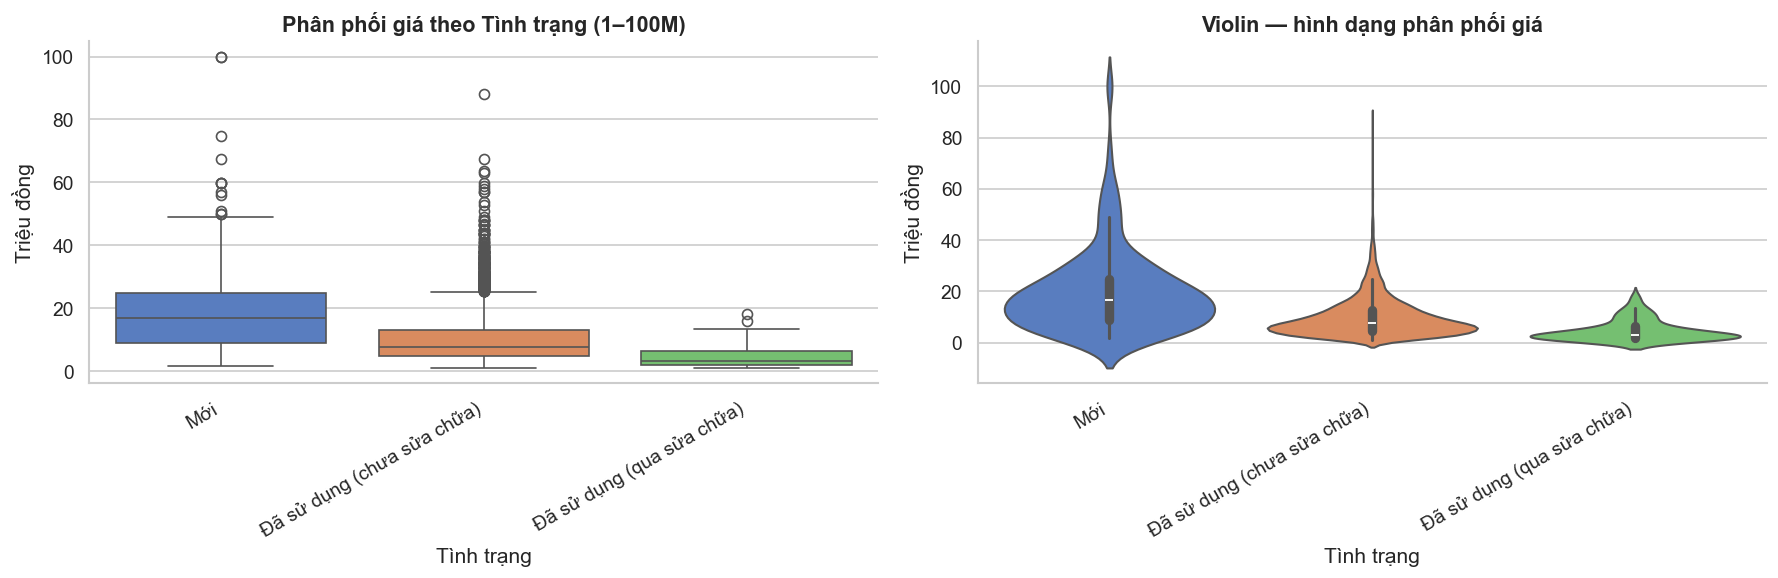

In [65]:
# ── Boxplot giá theo Tình trạng ─────────────────────────────────────────────────
plot_df = df[df['_price'].between(1e6, 100e6)].copy()
plot_df['price_mil'] = plot_df['_price'] / 1e6

order = (plot_df.groupby('Tình trạng')['price_mil']
         .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=plot_df, x='Tình trạng', y='price_mil',
            order=order, palette='muted', ax=axes[0])
axes[0].set_title("Phân phối giá theo Tình trạng (1–100M)")
axes[0].set_ylabel("Triệu đồng")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Violin — thấy rõ multimodal
sns.violinplot(data=plot_df, x='Tình trạng', y='price_mil',
               order=order, palette='muted', inner='box', ax=axes[1])
axes[1].set_title("Violin — hình dạng phân phối giá")
axes[1].set_ylabel("Triệu đồng")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Price Distribution Insight

Phân tích phân phối giá theo `Tình trạng` cho thấy sự khác biệt rõ ràng giữa các nhóm. Nhóm “Mới” có mức giá trung vị cao nhất và độ phân tán lớn, với nhiều outliers ở phân khúc giá cao, phản ánh việc các sản phẩm mới thường thuộc các dòng cao cấp hoặc cấu hình mạnh. Nhóm “Đã sử dụng (chưa sửa chữa)” có mức giá thấp hơn đáng kể nhưng vẫn có độ phân tán rộng, cho thấy sự đa dạng về cấu hình và chất lượng trong nhóm này. Trong khi đó, nhóm “Đã sử dụng (qua sửa chữa)” có mức giá thấp nhất và phân phối hẹp hơn, phù hợp với kỳ vọng về việc giá bị giảm do đã qua can thiệp sửa chữa.

Quan sát từ boxplot và violin plot cho thấy mối quan hệ giữa `Tình trạng` và `price` mang tính đơn điệu (monotonic), tức là chất lượng càng cao thì giá càng cao. Điều này củng cố giả định rằng `Tình trạng` là một **ordinal feature có ý nghĩa thực tế** trong bài toán dự đoán giá.

Do đó, việc sử dụng **ordinal encoding** cho cột này là hợp lý trong bước baseline, vì vừa giữ được thứ tự ngữ nghĩa vừa không làm tăng số chiều dữ liệu như one-hot encoding. Tuy nhiên, cần lưu ý rằng khoảng cách giá giữa các nhóm không hoàn toàn đồng đều, và sự tồn tại của nhiều outliers có thể ảnh hưởng đến mô hình. Vì vậy, trong giai đoạn modeling, nên kiểm chứng hiệu quả của ordinal encoding so với các phương pháp khác như one-hot hoặc target encoding để lựa chọn cách biểu diễn tối ưu.

In [66]:
# ── Thống kê giá theo Tình trạng ────────────────────────────────────────────────
stats = (df.groupby('Tình trạng')['_price']
         .describe(percentiles=[.25, .5, .75])
         .assign(**{'Median (M)': lambda x: x['50%']/1e6,
                    'Mean (M)':   lambda x: x['mean']/1e6,
                    'P25 (M)':    lambda x: x['25%']/1e6,
                    'P75 (M)':    lambda x: x['75%']/1e6})
         [['count', 'Median (M)', 'Mean (M)', 'P25 (M)', 'P75 (M)']]
         .sort_values('Median (M)', ascending=False)
         .round(2))
display(stats)

,count,Median (M),Mean (M),P25 (M),P75 (M)
Tình trạng,,,,,
Mới,182.0,16.75,19.77,8.90,24.97
Đã sử dụng (chưa sửa chữa),5593.0,7.50,9.70,4.50,12.70
Đã sử dụng (qua sửa chữa),90.0,2.10,3.54,0.86,4.45


## Statistical Summary

Thống kê mô tả theo từng nhóm `Tình trạng` cho thấy sự khác biệt rõ rệt về mức giá. Nhóm “Mới” có **median ~16.75M** và **mean ~19.77M**, cao hơn đáng kể so với hai nhóm còn lại, đồng thời khoảng P25–P75 khá rộng (8.90M – 24.97M), phản ánh sự đa dạng về phân khúc sản phẩm. Nhóm “Đã sử dụng (chưa sửa chữa)” có mức giá trung vị khoảng **7.50M**, với phân phối tập trung hơn (P25–P75: 4.50M – 12.70M), nhưng vẫn tồn tại một số giá trị cao kéo mean lên ~9.70M. Trong khi đó, nhóm “Đã sử dụng (qua sửa chữa)” có giá thấp nhất, với **median ~2.10M** và phân phối hẹp hơn (P25–P75: 0.86M – 4.45M), phù hợp với kỳ vọng về mức giảm giá sau sửa chữa.

Quan trọng hơn, cả **median và các quantile đều tuân theo thứ tự nhất quán**:
Mới > Đã sử dụng (chưa sửa chữa) > Đã sử dụng (qua sửa chữa). Điều này xác nhận rằng mối quan hệ giữa `Tình trạng` và `price` là **đơn điệu (monotonic)** và có ý nghĩa thực tế.

In [67]:
# Chuẩn bị dataframe riêng cho phần phân tích Tình trạng

condition_col = "Tình trạng"
price_col = "_price"

cond_df = df[df[price_col].notna()].copy()
cond_df["_price_m"] = cond_df[price_col] / 1_000_000

condition_order = [
    "Mới",
    "Đã sử dụng (chưa sửa chữa)",
    "Đã sử dụng (qua sửa chữa)"
]

cond_df[condition_col] = pd.Categorical(
    cond_df[condition_col],
    categories=condition_order,
    ordered=True
)

print(f"Số dòng dùng để phân tích: {len(cond_df):,}")
display(cond_df[[condition_col, "price", "_price_m", "title"]].head())

Số dòng dùng để phân tích: 5,865


,Tình trạng,price,_price_m,title
0,Đã sử dụng (chưa sửa chữa),9.990.000 đ,9.99,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G
1,Đã sử dụng (chưa sửa chữa),4.500.000 đ,4.50,Acer Aspire A315-58 i3-1115G4
2,Đã sử dụng (chưa sửa chữa),3.500.000 đ,3.50,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1
3,Đã sử dụng (chưa sửa chữa),37.500.000 đ,37.50,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB
4,Đã sử dụng (chưa sửa chữa),7.990.000 đ,7.99,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ


In [68]:
# Kiểm tra độ nhạy theo nhiều ngưỡng giá thấp trong nhóm "Mới"

thresholds = [3, 5, 7, 10]

rows = []
new_df = cond_df[cond_df[condition_col] == "Mới"]

for t in thresholds:
    mask = new_df["_price_m"] < t
    rows.append({
        "Ngưỡng giá (triệu)": f"< {t}M",
        "Số laptop 'Mới'": len(new_df),
        "Số dòng dưới ngưỡng": mask.sum(),
        "Tỷ lệ trong nhóm 'Mới' (%)": round(mask.mean() * 100, 2)
    })

low_new_summary = pd.DataFrame(rows)
display(low_new_summary)

,Ngưỡng giá (triệu),Số laptop 'Mới',Số dòng dưới ngưỡng,Tỷ lệ trong nhóm 'Mới' (%)
0,< 3M,182,7,3.85
1,< 5M,182,25,13.74
2,< 7M,182,39,21.43
3,< 10M,182,55,30.22


Kết quả cho thấy tỷ lệ laptop được gắn nhãn “Mới” nhưng có giá thấp không hề nhỏ và tăng nhanh theo ngưỡng. Cụ thể, khoảng 3.85% dưới 3 triệu, 13.74% dưới 5 triệu và lên tới hơn 30% dưới 10 triệu. Điều này cho thấy nhãn “Mới” trong dữ liệu không đáng tin cậy tuyệt đối và có xu hướng bị sử dụng theo mục đích marketing. Do đó, cần cẩn trọng khi sử dụng trực tiếp feature này và nên kết hợp thêm các rule hoặc flag để xử lý các trường hợp bất thường.

In [69]:
# Xem chi tiết các laptop "Mới" nhưng có giá thấp bất thường

LOW_NEW_THRESHOLD = 5  # triệu đồng

low_new = cond_df[
    (cond_df[condition_col] == "Mới") &
    (cond_df["_price_m"] < LOW_NEW_THRESHOLD)
].sort_values("_price_m")

cols_to_show = [
    "title", condition_col, "price", "Hãng", "Dòng máy",
    "Bộ vi xử lý", "RAM", "Ổ cứng", "Chính sách bảo hành"
]

cols_to_show = [c for c in cols_to_show if c in cond_df.columns]

print(f"Laptop 'Mới' có giá < {LOW_NEW_THRESHOLD} triệu: {len(low_new)} rows")
display(low_new[cols_to_show].head(50))

Laptop 'Mới' có giá < 5 triệu: 25 rows


,title,Tình trạng,price,Hãng,Dòng máy,Bộ vi xử lý,RAM,Ổ cứng,Chính sách bảo hành
766,Dell Latitude E7250 pin 4h,Mới,1.700.000 đ,Dell,Latitude 14 7000,Intel Core i5,8 GB,NaN,Bảo hành hãng
3076,"Dell Vostro 3468 Core i3-6006U, RAM 4GB, SSD 120GB",Mới,1.800.000 đ,Dell,Dòng Khác,Intel Core i3,4 GB,128 GB,1 tháng
3565,"Dell Inspiron 3467 Core i3-7020U, 4GB, SSD 128GB",Mới,1.900.000 đ,Dell,Inspiron 14 3000,Intel Core i3,4 GB,128 GB,1 tháng
1667,LAPTOP DELL I5 - MỚI 100% - GÓP NHANH,Mới,2.300.000 đ,Dell,Dòng Khác,Intel Core i5,8 GB,512 GB,>12 tháng
26,"HP 15-da0056TU i3 8130U, 4GB, SSD 128GB, 15.6"" HD",Mới,2.300.000 đ,HP,Dòng Khác,Intel Core i3,4 GB,128 GB,1 tháng
4695,Bán Macbook 12inch 2015 Ram 8G/512G màu Gold,Mới,2.450.000 đ,Apple,Dòng Khác,Intel Core i5,8 GB,256 GB,Bảo hành hãng
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,Mới,2.600.000 đ,Asus,Vivobook 14,Intel Core i3,8 GB,256 GB,Hết bảo hành
3186,Dell Laptop Đen/ BÁN TRẢ GÓP,Mới,3.200.000 đ,Dell,Latitude,Intel Core i7,8 GB,256 GB,7-12 tháng
5523,"HP 14s-dk0117AU Ryzen 3 3200U, RAM 8GB, SSD 256GB",Mới,3.300.000 đ,HP,Pavilion,Ryzen 3,8 GB,256 GB,1 tháng
1316,MacBook Air 13inch i5 2017 8G/ssd 128G đẹp keng,Mới,3.650.000 đ,Apple,MacBook Air,Intel Core i5,8 GB,< 128 GB,1 tháng


## Data Quality Check — “Mới” nhưng giá thấp (< 5 triệu)

Mở rộng kiểm tra với ngưỡng giá < 5 triệu cho thấy số lượng bản ghi “Mới” bất thường tăng lên đáng kể (25 rows). Khi quan sát chi tiết các mẫu này, có thể thấy nhiều dấu hiệu cho thấy nhãn “Mới” không phản ánh đúng trạng thái thực tế của sản phẩm.

Cụ thể, nhiều listing thuộc các dòng máy cũ (ví dụ: CPU thế hệ thấp như i3-6006U, i3-7020U, hoặc MacBook 2015), nhưng vẫn được gắn nhãn “Mới”. Ngoài ra, một số tiêu đề chứa các từ như “đẹp 98%”, “góp nhanh”, “pin 4h”, cho thấy đây thực chất là hàng đã qua sử dụng nhưng được mô tả lại theo hướng marketing. Điều này cho thấy người bán có xu hướng sử dụng “Mới” như một cách **tăng độ hấp dẫn của listing**, thay vì tuân theo định nghĩa chuẩn.

Những trường hợp này tạo ra **noise có hệ thống (systematic noise)** trong dữ liệu, làm suy yếu mối quan hệ giữa `Tình trạng` và `price`. Nếu không xử lý, mô hình có thể học sai rằng một số sản phẩm “Mới” có giá rất thấp, dẫn đến giảm chất lượng dự đoán.

### Handling Strategy

- Không nên loại bỏ toàn bộ, vì vẫn có thể chứa thông tin hữu ích
- Có thể:
  - Gắn nhãn các trường hợp này là **outlier**
  - Hoặc tạo rule-based feature (ví dụ: flag “mới nhưng giá thấp”)
- Kết hợp thêm thông tin từ `title` để phát hiện inconsistency (keyword như “98%”, “đẹp”, “pin”,…)

### Conclusion

Mặc dù `Tình trạng` nhìn chung có ý nghĩa và tương quan với giá, nhưng tồn tại một lượng không nhỏ các ngoại lệ do hành vi người dùng. Do đó, cần bổ sung bước kiểm tra và xử lý các trường hợp bất thường để đảm bảo tính nhất quán trước khi đưa vào modeling.

In [70]:
# Kiểm tra các keyword liên quan sửa chữa/lỗi nhưng tình trạng không phải "qua sửa chữa"

repair_pattern = (
    r"(qua\s*sửa|đã\s*sửa|sửa\s+chữa|"
    r"lỗi|hỏng|bể|vỡ|"
    r"thay\s+(pin|màn|main|bàn phím|keyboard|ổ|ssd|ram)|"
    r"chai\s*pin|pin\s*yếu|mất\s+\w+)"
)

cond_df["_title_suggests_repaired_or_defect"] = cond_df["title"].str.lower().str.contains(
    repair_pattern,
    regex=True,
    na=False
)

repair_mismatch = cond_df[
    (cond_df["_title_suggests_repaired_or_defect"]) &
    (cond_df[condition_col] != "Đã sử dụng (qua sửa chữa)")
].sort_values("_price_m")

print(f"Số dòng title có dấu hiệu lỗi/sửa chữa nhưng Tình trạng không phải 'qua sửa chữa': {len(repair_mismatch)}")
display(repair_mismatch[cols_to_show].head(50))

Số dòng title có dấu hiệu lỗi/sửa chữa nhưng Tình trạng không phải 'qua sửa chữa': 15


,title,Tình trạng,price,Hãng,Dòng máy,Bộ vi xử lý,RAM,Ổ cứng,Chính sách bảo hành
3793,Apple Macbook Air Bạc Hỏng,Đã sử dụng (chưa sửa chữa),450.000 đ,Apple,MacBook Air,NaN,NaN,NaN,Hết bảo hành
715,Masstel L133 Hỏng,Đã sử dụng (chưa sửa chữa),690.000 đ,Hãng khác,Dòng Khác,Intel Celeron,NaN,NaN,Hết bảo hành
3792,Toshiba Core i5 4GB/120GB SSD Pin lỗi,Đã sử dụng (chưa sửa chữa),1.500.000 đ,Toshiba,Satellite Series,Intel Core i5,4 GB,< 128 GB,Hết bảo hành
3470,Alienware gaming 15 R2 i7 6700HQ GTX 970M 4K Lỗi,Đã sử dụng (chưa sửa chữa),2.000.000 đ,Dell,Alienware 15,Intel Core i7,NaN,NaN,Hết bảo hành
1088,Apple Macbook Retina 12 inch 2015 - Màn có lỗi,Đã sử dụng (chưa sửa chữa),2.300.000 đ,Apple,Dòng Khác,Khác,8 GB,512 GB,Bảo hành hãng
2305,NEC Core i5 10210y 8/128 (lỗi nhỏ),Đã sử dụng (chưa sửa chữa),2.800.000 đ,Hãng khác,Dòng Khác,Intel Core i5,8 GB,< 128 GB,Bảo hành hãng
4161,HP Probook 440 G8 Bạc Lỗi main,Đã sử dụng (chưa sửa chữa),3.000.000 đ,HP,Probook 400,NaN,8 GB,NaN,Hết bảo hành
5789,Lenovo Ryzen5 7th 8/256 NVMe card2GB mất ốp bản lề,Đã sử dụng (chưa sửa chữa),3.850.000 đ,Lenovo,Ideapad 1,AMD,8 GB,256 GB,Còn bảo hành
883,HP 15s-fq2xxx i7-1165G7 lỗi không sạc pin,Đã sử dụng (chưa sửa chữa),4.000.000 đ,HP,Dòng Khác,Intel Core i7,NaN,NaN,Bảo hành hãng
3963,"Bán Surface Pro 7 Plus i5 8GB/256GB, vỡ màn hình",Đã sử dụng (chưa sửa chữa),5.300.000 đ,Microsoft,Surface Pro 7+,Intel Core i5,8 GB,256 GB,Bảo hành hãng


Kết quả cho thấy tồn tại một số lượng đáng kể các bản ghi có **dấu hiệu lỗi/sửa chữa trong `title` nhưng `Tình trạng` vẫn là “chưa sửa chữa”**. Điều này phản ánh sự **không nhất quán (inconsistency)** giữa các cột, nhiều khả năng do người bán mô tả chi tiết tình trạng thực tế trong tiêu đề nhưng không cập nhật đúng trường structured.

Các keyword như “lỗi”, “lỗi main”, “mất ốc”, “vỡ màn hình”,… xuất hiện trực tiếp trong `title` nhưng không được phản ánh ở `Tình trạng`, cho thấy dữ liệu mang tính **user-generated noise** rõ rệt. Nếu không xử lý, mô hình có thể học sai rằng những sản phẩm có lỗi vẫn thuộc nhóm “chưa sửa chữa” với mức giá tương ứng, làm giảm chất lượng dự đoán.

Do đó, cần xem đây là một dạng **cross-column inconsistency**, và có thể xử lý bằng cách tạo flag hoặc bổ sung feature dựa trên `title` để hỗ trợ mô hình nhận diện các trường hợp bất thường.

In [71]:
# Outlier giá theo từng nhóm Tình trạng bằng IQR

q1 = cond_df.groupby(condition_col)["_price_m"].transform(lambda s: s.quantile(0.25))
q3 = cond_df.groupby(condition_col)["_price_m"].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1

cond_df["_price_lower_iqr"] = (q1 - 1.5 * iqr).clip(lower=0)
cond_df["_price_upper_iqr"] = q3 + 1.5 * iqr

cond_df["_condition_price_outlier"] = (
    (cond_df["_price_m"] < cond_df["_price_lower_iqr"]) |
    (cond_df["_price_m"] > cond_df["_price_upper_iqr"])
)

outlier_summary = (
    cond_df.groupby(condition_col)
    .agg(
        count=("title", "count"),
        outliers=("_condition_price_outlier", "sum"),
        outlier_pct=("_condition_price_outlier", lambda s: round(s.mean() * 100, 2)),
        lower_bound=("_price_lower_iqr", "median"),
        upper_bound=("_price_upper_iqr", "median")
    )
    .reset_index()
)

display(outlier_summary)

,Tình trạng,count,outliers,outlier_pct,lower_bound,upper_bound
0,Mới,182,12,6.59,0.0,49.085625
1,Đã sử dụng (chưa sửa chữa),5593,268,4.79,0.0,25.000000
2,Đã sử dụng (qua sửa chữa),90,10,11.11,0.0,9.831250


## Outlier Analysis theo `Tình trạng`

Phân tích outlier theo từng nhóm `Tình trạng` cho thấy tỷ lệ outlier không quá lớn nhưng có sự khác biệt giữa các nhóm. Nhóm “Đã sử dụng (qua sửa chữa)” có tỷ lệ outlier cao nhất (~11.11%), phản ánh sự biến động giá lớn hơn, có thể do mức độ sửa chữa không đồng đều giữa các sản phẩm. Nhóm “Mới” (~6.59%) có outlier chủ yếu ở phía giá cao, tương ứng với các sản phẩm cao cấp. Trong khi đó, nhóm “Đã sử dụng (chưa sửa chữa)” (~4.79%) có phân phối ổn định hơn, ít outlier hơn do dữ liệu tập trung quanh mức giá trung bình. Nhìn chung, outlier tồn tại ở cả ba nhóm nhưng không ở mức nghiêm trọng, tuy nhiên vẫn cần được cân nhắc xử lý hoặc giữ lại tùy theo mục tiêu modeling.

In [72]:
# Kiểm tra consistency giữa Tình trạng và Chính sách bảo hành

warranty_col = "Chính sách bảo hành"

if warranty_col in cond_df.columns:
    warranty_crosstab = pd.crosstab(
        cond_df[condition_col],
        cond_df[warranty_col],
        margins=True
    )

    display(warranty_crosstab)

    warranty_crosstab_pct = pd.crosstab(
        cond_df[condition_col],
        cond_df[warranty_col],
        normalize="index"
    ).mul(100).round(2)

    display(warranty_crosstab_pct)

Chính sách bảo hành,1 tháng,2 tháng,3 tháng,4-6 tháng,7-12 tháng,>12 tháng,Bảo hành hãng,Còn bảo hành,Hết bảo hành,All
Tình trạng,,,,,,,,,,
Mới,32,0,16,7,25,18,39,42,3,182
Đã sử dụng (chưa sửa chữa),582,15,879,278,107,54,2901,345,432,5593
Đã sử dụng (qua sửa chữa),3,2,2,1,2,0,64,0,16,90
All,617,17,897,286,134,72,3004,387,451,5865


Chính sách bảo hành,1 tháng,2 tháng,3 tháng,4-6 tháng,7-12 tháng,>12 tháng,Bảo hành hãng,Còn bảo hành,Hết bảo hành
Tình trạng,,,,,,,,,
Mới,17.58,0.00,8.79,3.85,13.74,9.89,21.43,23.08,1.65
Đã sử dụng (chưa sửa chữa),10.41,0.27,15.72,4.97,1.91,0.97,51.87,6.17,7.72
Đã sử dụng (qua sửa chữa),3.33,2.22,2.22,1.11,2.22,0.00,71.11,0.00,17.78


## Consistency giữa `Tình trạng` và `Chính sách bảo hành`

Phân tích chéo giữa `Tình trạng` và `Chính sách bảo hành` cho thấy tồn tại một số điểm không nhất quán nhưng vẫn có tín hiệu hợp lý. Nhóm “Mới” có tỷ lệ “Còn bảo hành” và “Bảo hành hãng” tương đối cao (lần lượt 23% và 21%), phù hợp với kỳ vọng. Tuy nhiên, vẫn có một tỷ lệ nhỏ (~1.65%) được gắn nhãn “Hết bảo hành”, cho thấy khả năng nhãn “Mới” không phản ánh đúng trạng thái thực tế.

Ở nhóm “Đã sử dụng (chưa sửa chữa)”, phần lớn tập trung ở “Bảo hành hãng” (51.87%), nhưng cũng có tỷ lệ đáng kể “Hết bảo hành” (7.72%), phản ánh đúng đặc trưng của sản phẩm đã qua sử dụng. Nhóm “Đã sử dụng (qua sửa chữa)” có tỷ lệ “Bảo hành hãng” cao (71.11%) nhưng cũng có tỷ lệ “Hết bảo hành” lớn (17.78%), cho thấy sự không đồng nhất trong chính sách sau sửa chữa.

Nhìn chung, mặc dù có mối quan hệ hợp lý giữa `Tình trạng` và `Chính sách bảo hành`, vẫn tồn tại các trường hợp bất thường do dữ liệu user-generated. Điều này củng cố nhận định rằng cần kiểm tra cross-column consistency và có thể tạo thêm các flag để xử lý các trường hợp không nhất quán trong giai đoạn cleaning hoặc modeling.

In [73]:
# Các trường hợp "Mới" nhưng bảo hành có vẻ không phù hợp

if warranty_col in cond_df.columns:
    suspicious_warranty_pattern = r"(hết|không|no warranty)"

    new_bad_warranty = cond_df[
        (cond_df[condition_col] == "Mới") &
        (cond_df[warranty_col].astype(str).str.lower().str.contains(
            suspicious_warranty_pattern,
            regex=True,
            na=False
        ))
    ].sort_values("_price_m")

    print(f"Số dòng 'Mới' nhưng chính sách bảo hành có vẻ không phù hợp: {len(new_bad_warranty)}")
    display(new_bad_warranty[cols_to_show].head(10))

Số dòng 'Mới' nhưng chính sách bảo hành có vẻ không phù hợp: 3


,title,Tình trạng,price,Hãng,Dòng máy,Bộ vi xử lý,RAM,Ổ cứng,Chính sách bảo hành
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,Mới,2.600.000 đ,Asus,Vivobook 14,Intel Core i3,8 GB,256 GB,Hết bảo hành
28,Macbook 12 inch retina 2017,Mới,4.000.000 đ,Apple,MacBook,M3,8 GB,256 GB,Hết bảo hành
2360,Microsoft Surface Pro 9 i7 1265U 16GB/2TB,Mới,26.000.000 đ,Microsoft,Surface Pro 9,Intel Core i9,16 GB,> 1 TB,Hết bảo hành


## Inconsistency: “Mới” nhưng hết bảo hành

Kết quả cho thấy tồn tại một số trường hợp được gắn nhãn “Mới” nhưng lại có trạng thái “Hết bảo hành”. Điều này không phù hợp với kỳ vọng thông thường, vì sản phẩm mới thường đi kèm bảo hành hoặc ít nhất là còn thời hạn bảo hành.

Mặc dù số lượng không nhiều (3 dòng), đây vẫn là dấu hiệu của **data inconsistency** do dữ liệu được nhập từ người dùng. Những trường hợp này có thể là hàng cũ nhưng được mô tả là “mới”, hoặc người bán không cập nhật đúng thông tin bảo hành.

Nhìn chung, đây là các ngoại lệ nhỏ nhưng đáng chú ý, và có thể được xử lý bằng cách tạo flag hoặc giữ lại để mô hình tự học nếu không ảnh hưởng đáng kể đến tổng thể.

# 10. Column: `Chính sách bảo hành`
Category text phản ánh thời gian bảo hành còn lại — có thể encode thành số tháng.

,count
Chính sách bảo hành,
Bảo hành hãng,3005
3 tháng,897
1 tháng,617
Hết bảo hành,451
Còn bảo hành,387
4-6 tháng,286
7-12 tháng,134
>12 tháng,72
2 tháng,17


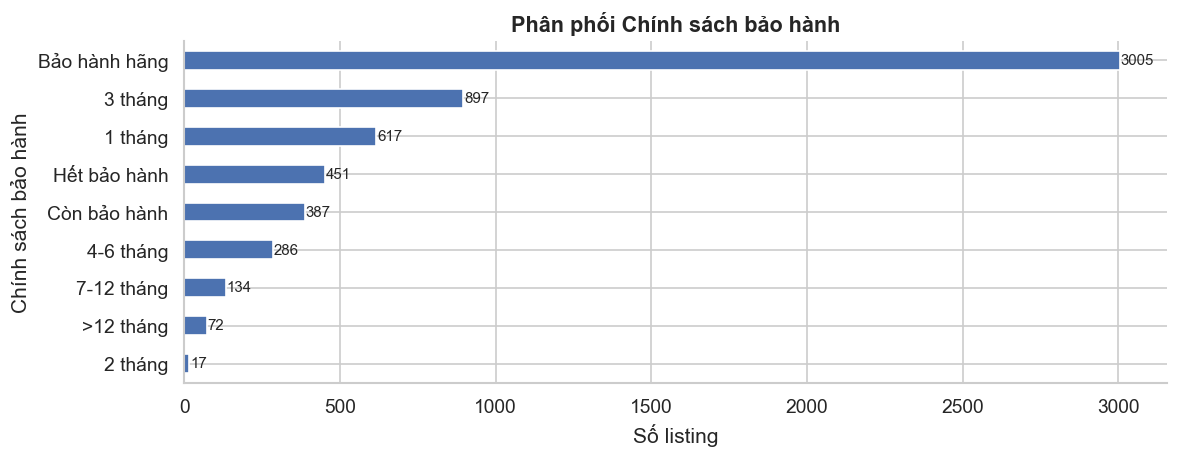

In [74]:
wty_vc = df['Chính sách bảo hành'].value_counts(dropna=False)
display(wty_vc.to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
wty_vc.sort_values().plot(kind='barh', ax=ax, color=ACCENT)
ax.set_title("Phân phối Chính sách bảo hành")
ax.set_xlabel("Số listing")
for i, v in enumerate(wty_vc.sort_values().values):
    ax.text(v + 3, i, str(v), va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## Phân phối `Chính sách bảo hành`

Cột `Chính sách bảo hành` có phân phối không đồng đều, với “Bảo hành hãng” chiếm tỷ trọng lớn nhất (~50% dữ liệu), trong khi các nhóm còn lại phân tán và có nhiều category nhỏ. Điều này cho thấy feature này bị **imbalance**, có thể khiến mô hình học lệch nếu không xử lý phù hợp.

Ngoài ra, các giá trị trong cột này không cùng một loại ngữ nghĩa: một số thể hiện **thời gian bảo hành** (“1 tháng”, “3 tháng”, “4–6 tháng”), trong khi số khác lại thể hiện **trạng thái** (“Còn bảo hành”, “Hết bảo hành”) hoặc **nguồn bảo hành** (“Bảo hành hãng”). Điều này tạo ra sự **không nhất quán về schema**, khiến việc encode trực tiếp trở nên khó khăn.

In [75]:
# ── Mapping → số tháng ──────────────────────────────────────────────────────────
WARRANTY_MAP = {
    'Không bảo hành': 0,
    'Dưới 3 tháng':   1.5,
    '3 - 6 tháng':    4.5,
    '6 - 12 tháng':   9,
    'Trên 12 tháng':  18,   # ước tính
    'Bảo hành chính hãng': 12,
}

def map_warranty(val):
    if pd.isna(val): return np.nan
    # exact match trước
    for k, v in WARRANTY_MAP.items():
        if k.lower() in str(val).lower():
            return v
    nums = re.findall(r'\d+', str(val))
    return np.mean([int(n) for n in nums]) if nums else np.nan

df['warranty_est'] = df['Chính sách bảo hành'].apply(map_warranty)
mapping_result = (df.groupby('Chính sách bảo hành')['warranty_est']
                  .first().sort_values().reset_index())
mapping_result.columns = ['Category gốc', 'Số tháng ước tính']
display(mapping_result)

print(f"\nUnmapped (NaN): {df['warranty_est'].isna().sum()}")
df.drop(columns='warranty_est', inplace=True, errors='ignore')

,Category gốc,Số tháng ước tính
0,1 tháng,1.0
1,2 tháng,2.0
2,3 tháng,3.0
3,4-6 tháng,5.0
4,7-12 tháng,9.5
5,>12 tháng,12.0
6,Bảo hành hãng,NaN
7,Còn bảo hành,NaN
8,Hết bảo hành,NaN



Unmapped (NaN): 3843


## Mapping `Chính sách bảo hành` → số tháng

Kết quả mapping cho thấy chỉ các giá trị dạng **duration (tháng)** có thể chuyển đổi trực tiếp sang số (1, 2, 3, 4–6, 7–12, >12), trong khi các giá trị như “Bảo hành hãng”, “Còn bảo hành”, “Hết bảo hành” không thể ánh xạ (NaN). Điều này dẫn đến **số lượng lớn dữ liệu không được map (~3.8k dòng)**, chiếm phần đáng kể dataset.

Điều này xác nhận rằng cột `Chính sách bảo hành` thực chất đang **trộn nhiều loại thông tin khác nhau**: duration (thời gian), status (còn/hết), và source (hãng). Việc cố ép tất cả về một trục “số tháng” sẽ làm mất thông tin và tạo nhiều missing không cần thiết.

Do đó, thay vì map về một biến duy nhất, nên tách feature này thành nhiều thành phần riêng biệt (ví dụ: `warranty_months`, `warranty_status`, `warranty_source`). Cách này vừa giữ được tối đa thông tin, vừa tránh tạo ra lượng lớn giá trị thiếu trong quá trình preprocessing.

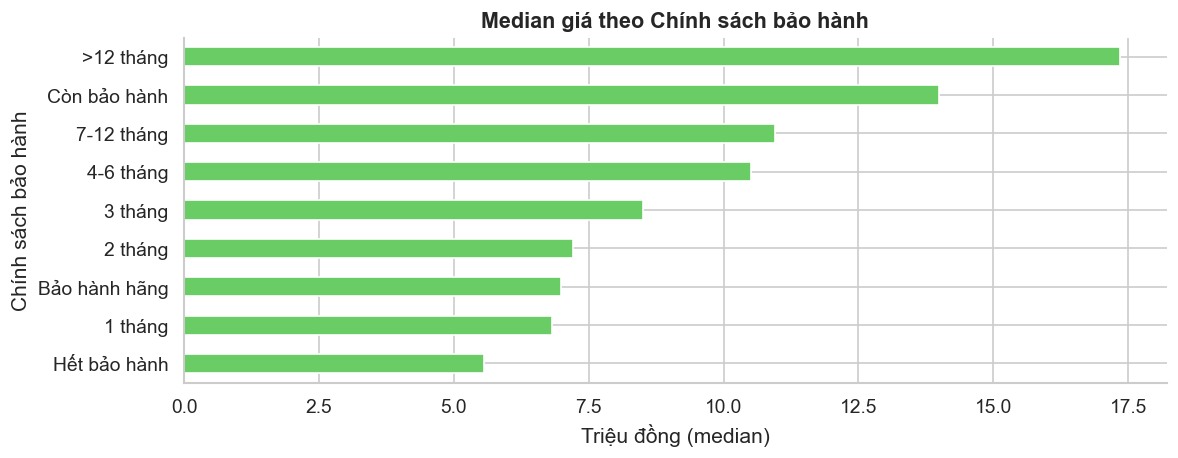

In [76]:
# ── Giá theo nhóm bảo hành ──────────────────────────────────────────────────────
wty_price = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6)
             .groupby('Chính sách bảo hành')['price_mil']
             .median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
wty_price.sort_values().plot(kind='barh', ax=ax, color=COLORS[2])
ax.set_title("Median giá theo Chính sách bảo hành")
ax.set_xlabel("Triệu đồng (median)")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## Price signal theo `Chính sách bảo hành`

Phân tích median giá cho thấy `Chính sách bảo hành` có **mối quan hệ rõ ràng với giá**, đặc biệt đối với các giá trị dạng thời gian. Nhóm có thời hạn dài hơn (>12 tháng, 7–12 tháng, 4–6 tháng) có median giá cao hơn đáng kể so với các nhóm ngắn hạn (1–3 tháng), phản ánh mối quan hệ hợp lý: **bảo hành dài hơn → giá cao hơn**.

Ngoài ra, các giá trị dạng trạng thái cũng thể hiện signal rõ: “Còn bảo hành” có mức giá cao hơn đáng kể so với “Hết bảo hành”, cho thấy feature này mang thông tin quan trọng về chất lượng/giá trị sản phẩm.

Tuy nhiên, “Bảo hành hãng” lại nằm ở mức giá trung bình (~7M), thấp hơn kỳ vọng so với nhóm bảo hành dài hạn. Điều này cho thấy giá trị này không đồng nghĩa với duration cụ thể và mang ý nghĩa khác (nguồn bảo hành), càng củng cố rằng feature này đang trộn nhiều loại thông tin.

Nhìn chung, `Chính sách bảo hành` là feature có signal tốt cho giá, nhưng cần được **tách và chuẩn hóa** (duration vs status vs source) để mô hình có thể khai thác hiệu quả và nhất quán hơn.

## Nhận xét về `Chính sách bảo hành`

Cột `Chính sách bảo hành` có một số tín hiệu liên quan đến giá, đặc biệt ở các nhóm có thông tin thời hạn rõ ràng. Các giá trị như “>12 tháng”, “7-12 tháng” hoặc “Còn bảo hành” thường có median giá cao hơn so với “Hết bảo hành”, cho thấy bảo hành vẫn phản ánh một phần giá trị sản phẩm.

Tuy nhiên, insight từ cột này không quá mạnh do các giá trị không cùng một loại ngữ nghĩa. Một số category thể hiện thời gian bảo hành, một số thể hiện trạng thái, trong khi “Bảo hành hãng” lại thể hiện nguồn bảo hành. Vì vậy, nếu encode trực tiếp toàn bộ cột này như một categorical feature, mô hình có thể học được signal nhưng khó diễn giải rõ ràng.

Do đó, `Chính sách bảo hành` nên được xem là feature phụ trợ hơn là feature chính. Trong preprocessing, có thể tách nhẹ thành các feature đơn giản như `warranty_months`, `has_warranty` hoặc `is_official_warranty`, nhưng không nên dành quá nhiều effort cho cột này nếu mục tiêu là tối ưu model nhanh.

## 11. Column: `Kích cỡ màn hình`

Missing ~18%. Giá trị là range text (`"13 - 14.9 inch"`) — cần extract midpoint số.


In [77]:
display(df['Kích cỡ màn hình'].value_counts(dropna=False).to_frame())

,count
Kích cỡ màn hình,
13 - 14.9 inch,2380
15 - 16.9 inch,2110
NaN,1037
11 - 12.9 inch,210
17 - 18.9 inch,103
9 - 10.9 inch,19
19 - 20.9 inch,3
< 9 inch,2
>= 21 inch,2


## Phân phối `Kích cỡ màn hình`

Cột `Kích cỡ màn hình` có phân phối khá rõ ràng theo các phân khúc phổ biến. Hai nhóm chính là **13–14.9 inch (2.3k)** và **15–16.9 inch (2.1k)** chiếm phần lớn dữ liệu, phản ánh đúng thị trường laptop phổ biến (ultrabook và laptop 15 inch). Các nhóm khác như 11–12.9 inch hoặc >17 inch chiếm tỷ lệ nhỏ, mang tính niche.

Tuy nhiên, tồn tại một tỷ lệ missing khá lớn (~1k dòng, ~17–18%), cho thấy dữ liệu chưa đầy đủ hoặc không được extract tốt từ title. Ngoài ra, một số bucket rất nhỏ (<9 inch, ≥21 inch) có thể là noise hoặc dữ liệu không liên quan (tablet, màn hình rời, nhập sai).

Nhìn chung, đây là feature có **signal tốt và dễ diễn giải**, vì kích thước màn hình thường liên quan đến phân khúc và giá. Trong preprocessing, có thể:
- giữ nguyên dạng bucket như hiện tại (ordinal)
- hoặc map về giá trị trung bình (numeric)
- xử lý riêng nhóm missing (có thể infer từ title nếu cần)

So với `Chính sách bảo hành`, đây là feature mạnh và đáng ưu tiên hơn trong modeling.

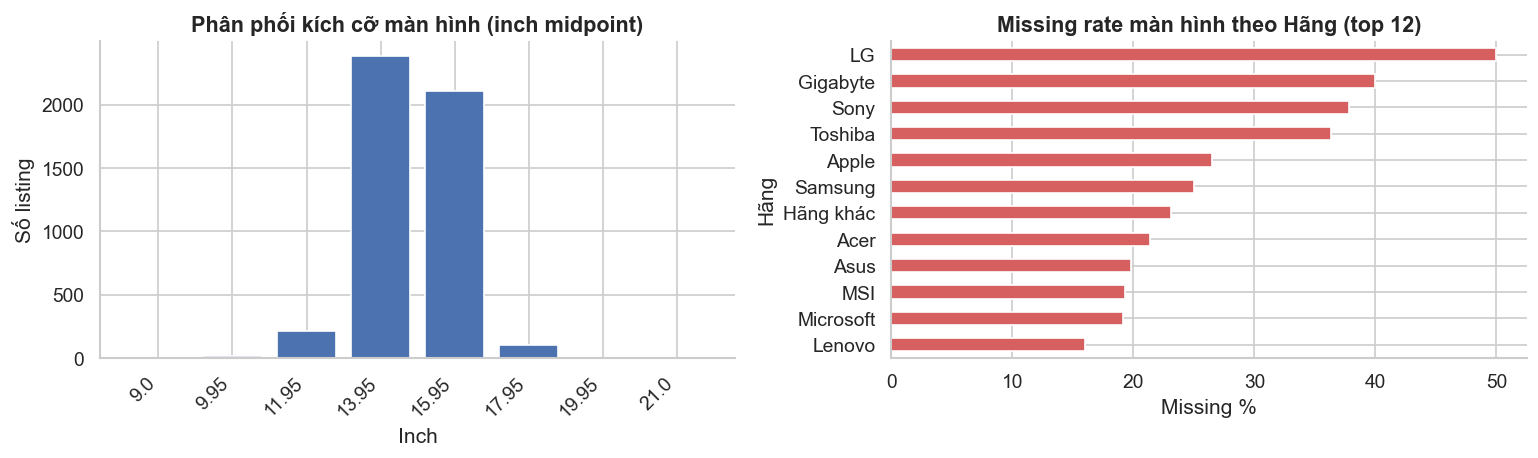

In [78]:
# ── Extract midpoint ────────────────────────────────────────────────────────────
def screen_midpoint(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'[\d\.]+', str(val))
    if len(nums) >= 2: return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) == 1: return float(nums[0])
    return np.nan

df['screen_mid'] = df['Kích cỡ màn hình'].apply(screen_midpoint)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Phân phối inch
vc_inch = df['screen_mid'].value_counts().sort_index()
axes[0].bar(vc_inch.index.astype(str), vc_inch.values, color=ACCENT, edgecolor='white')
axes[0].set_title("Phân phối kích cỡ màn hình (inch midpoint)")
axes[0].set_xlabel("Inch")
axes[0].set_ylabel("Số listing")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Missing rate theo hãng
miss_screen = (df.groupby('Hãng')['Kích cỡ màn hình']
               .apply(lambda x: x.isna().mean()*100)
               .sort_values(ascending=False).head(12).sort_values())
miss_screen.plot(kind='barh', ax=axes[1], color=COLORS[3])
axes[1].set_title("Missing rate màn hình theo Hãng (top 12)")
axes[1].set_xlabel("Missing %")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## Phân phối và missing của `Kích cỡ màn hình`

Phân phối kích cỡ màn hình (sau khi map về midpoint) tập trung mạnh ở hai cụm **~13.9 inch và ~15.6 inch**, phản ánh đúng hai phân khúc chính của thị trường laptop: ultrabook và laptop 15 inch. Các kích cỡ khác (11–12 inch, >17 inch) chiếm tỷ lệ rất nhỏ và mang tính niche.

Tuy nhiên, tỷ lệ missing không đồng đều giữa các hãng. Một số hãng như LG, Gigabyte, Sony, Toshiba có missing rate rất cao (30–50%), trong khi các hãng lớn như Lenovo, Asus, MSI thấp hơn (~15–20%). Điều này cho thấy missing không hoàn toàn ngẫu nhiên mà có tính **systematic theo brand**, nhiều khả năng do khác biệt trong cách đăng tin hoặc khả năng extract từ title.

Điều này có hai hệ quả quan trọng:
- Missing có thể mang thông tin (informative missing), không nên xử lý như missing ngẫu nhiên
- Có thể tận dụng `Hãng` để hỗ trợ impute hoặc infer kích cỡ màn hình

Nhìn chung, `Kích cỡ màn hình` là feature có signal tốt và phân phối rõ ràng, nhưng cần xử lý missing cẩn thận để tránh làm mất thông tin hoặc introduce bias.

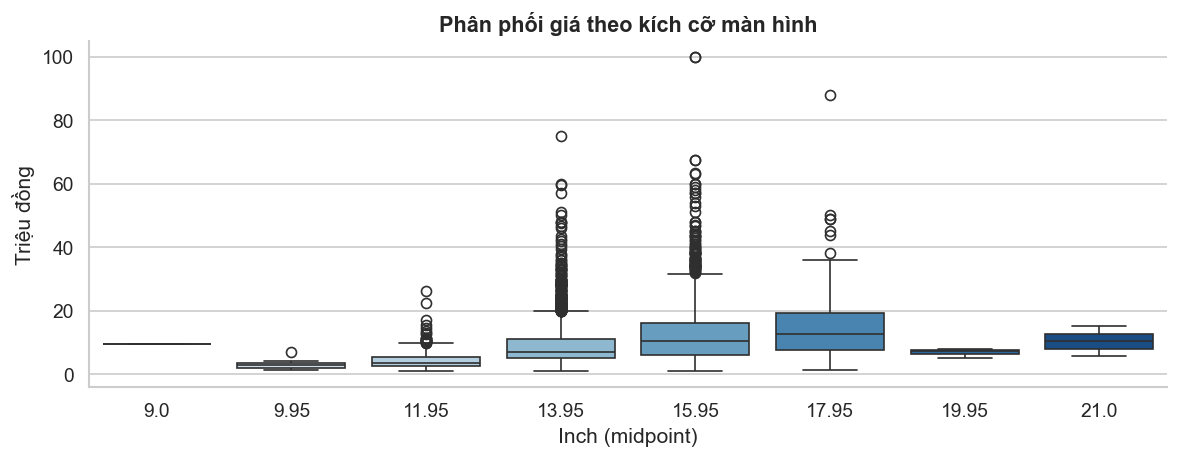

In [79]:
# ── Giá theo kích cỡ màn hình ───────────────────────────────────────────────────
plot_df = (df[df['_price'].between(1e6, 100e6) & df['screen_mid'].notna()]
           .assign(price_mil=lambda x: x['_price']/1e6))

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=plot_df, x='screen_mid', y='price_mil',
            order=sorted(plot_df['screen_mid'].unique()),
            palette='Blues', ax=ax)
ax.set_title("Phân phối giá theo kích cỡ màn hình")
ax.set_xlabel("Inch (midpoint)")
ax.set_ylabel("Triệu đồng")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='screen_mid', inplace=True, errors='ignore')


## Price theo `Kích cỡ màn hình`

Phân tích cho thấy giá có xu hướng **tăng theo kích thước màn hình**, đặc biệt từ 11–12 inch lên ~15–17 inch. Nhóm 13–16 inch (phổ biến nhất) có dải giá rộng và median tăng dần theo kích thước, phản ánh sự khác biệt giữa ultrabook (13–14 inch) và laptop hiệu năng cao hơn (15–16 inch).

Tuy nhiên, mối quan hệ này **không hoàn toàn tuyến tính**. Một số nhóm nhỏ như 19–21 inch hoặc <10 inch không theo xu hướng rõ ràng do số lượng ít (noise). Ngoài ra, trong cùng một kích thước (đặc biệt 13.9 và 15.6 inch), giá vẫn phân tán rất rộng, cho thấy kích thước màn hình chỉ là một yếu tố phụ và còn phụ thuộc mạnh vào cấu hình (CPU, RAM, GPU) và dòng máy.

Nhìn chung, `Kích cỡ màn hình` là feature có **signal trung bình**: có tương quan với giá nhưng không đủ mạnh để sử dụng độc lập. Nên kết hợp với các feature khác để tận dụng tốt hơn trong modeling.

In [80]:
# ── Screen size summary theo giá ────────────────────────────────────────────────

def screen_midpoint(val):
    if pd.isna(val):
        return np.nan

    nums = re.findall(r'[\d\.]+', str(val))

    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])

    return np.nan


screen_df = df[df["_price"].between(1e6, 100e6)].copy()
screen_df["screen_mid"] = screen_df["Kích cỡ màn hình"].apply(screen_midpoint)
screen_df["price_mil"] = screen_df["_price"] / 1e6

screen_price_summary = (
    screen_df
    .groupby(["Kích cỡ màn hình", "screen_mid"], dropna=False)
    .agg(
        count=("title", "count"),
        median_price_m=("price_mil", "median"),
        mean_price_m=("price_mil", "mean"),
        p25_price_m=("price_mil", lambda s: s.quantile(0.25)),
        p75_price_m=("price_mil", lambda s: s.quantile(0.75))
    )
    .round(2)
    .reset_index()
    .sort_values("screen_mid")
)

display(screen_price_summary)

,Kích cỡ màn hình,screen_mid,count,median_price_m,mean_price_m,p25_price_m,p75_price_m
6,< 9 inch,9.00,1,9.50,9.50,9.50,9.50
5,9 - 10.9 inch,9.95,18,2.90,2.86,1.78,3.42
0,11 - 12.9 inch,11.95,207,3.59,4.68,2.50,5.40
1,13 - 14.9 inch,13.95,2347,7.00,9.15,4.90,10.90
2,15 - 16.9 inch,15.95,2094,10.50,12.53,6.00,16.20
3,17 - 18.9 inch,17.95,103,12.50,16.24,7.64,19.20
4,19 - 20.9 inch,19.95,3,7.30,6.77,6.15,7.65
7,>= 21 inch,21.00,2,10.34,10.34,8.02,12.67
8,NaN,NaN,931,6.00,8.16,3.00,10.90


## Price theo `Kích cỡ màn hình`

Kết quả cho thấy giá có xu hướng **tăng theo kích thước màn hình**, đặc biệt từ nhóm 11–12.9 inch (~3.6M) lên 15–16.9 inch (~10.5M) và 17–18.9 inch (~12.5M). Điều này phản ánh đúng thực tế: laptop màn hình lớn thường đi kèm cấu hình cao hơn và thuộc phân khúc cao hơn.

Tuy nhiên, mối quan hệ này **không hoàn toàn tuyến tính và không quá mạnh**. Trong cùng một nhóm kích thước (đặc biệt 13–16 inch), giá vẫn phân tán khá rộng, cho thấy kích thước màn hình không phải yếu tố quyết định chính mà chỉ đóng vai trò bổ trợ bên cạnh cấu hình và dòng máy.

Ngoài ra, các nhóm nhỏ như <10 inch, >19 inch có rất ít dữ liệu nên không đáng tin cậy (noise). Nhóm missing (~931 dòng) có median ~6M, nằm giữa các phân khúc, cho thấy missing không hoàn toàn ngẫu nhiên nhưng cũng không quá lệch.

In [81]:
# ── Missing màn hình có liên quan đến giá không? ───────────────────────────────

screen_missing_price = (
    screen_df
    .assign(screen_missing=screen_df["Kích cỡ màn hình"].isna())
    .groupby("screen_missing")
    .agg(
        count=("title", "count"),
        median_price_m=("price_mil", "median"),
        mean_price_m=("price_mil", "mean"),
        p25_price_m=("price_mil", lambda s: s.quantile(0.25)),
        p75_price_m=("price_mil", lambda s: s.quantile(0.75))
    )
    .round(2)
    .reset_index()
)

display(screen_missing_price)

,screen_missing,count,median_price_m,mean_price_m,p25_price_m,p75_price_m
0,False,4775,8.0,10.57,5.0,13.5
1,True,931,6.0,8.16,3.0,10.9


## Missing `Kích cỡ màn hình` và price

So sánh giữa nhóm có và không có thông tin màn hình cho thấy sự khác biệt rõ ràng về giá. Các dòng **có thông tin màn hình** có median ~8M, trong khi nhóm **missing** chỉ ~6M. Phân phối cũng thấp hơn ở cả P25 và P75.

Điều này cho thấy missing **không phải ngẫu nhiên (not MCAR)** mà có xu hướng xuất hiện nhiều hơn ở các sản phẩm giá rẻ hoặc listing chất lượng thấp (ít thông tin). Đây là dấu hiệu của **informative missing**.

Hệ quả là:
- Không nên impute đơn giản (mean/median) vì sẽ làm mất signal này
- Có thể giữ một flag `screen_missing` như một feature riêng
- Hoặc kết hợp với `Hãng` / `title` để recover thêm thông tin nếu cần

Nhìn chung, missing ở cột này bản thân nó đã mang thông tin và có thể giúp cải thiện model nếu được xử lý đúng cách.

In [82]:
# ── Recover kích cỡ màn hình từ title cho các dòng bị missing ─────────────────

def extract_screen_from_title(title):
    if pd.isna(title):
        return np.nan

    text = str(title).lower().replace(",", ".")

    patterns = [
        r'(?<!\d)(\d{1,2}(?:\.\d)?)\s*(?:inch|inches)\b',
        r'(?<!\d)(\d{1,2}(?:\.\d)?)\s*["”]'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            val = float(match.group(1))
            if 8 <= val <= 22:
                return val

    return np.nan


screen_df["screen_from_title"] = screen_df["title"].apply(extract_screen_from_title)

recoverable_screen = screen_df[
    screen_df["Kích cỡ màn hình"].isna() &
    screen_df["screen_from_title"].notna()
].copy()

print(f"Missing màn hình có thể recover từ title: {len(recoverable_screen)} rows")
print(
    f"Tỷ lệ trên tổng missing màn hình: "
    f"{len(recoverable_screen) / screen_df['Kích cỡ màn hình'].isna().sum() * 100:.2f}%"
)

display(
    recoverable_screen[
        ["title", "Hãng", "Dòng máy", "screen_from_title", "price", "Bộ vi xử lý", "RAM", "Ổ cứng"]
    ].head(10)
)

Missing màn hình có thể recover từ title: 39 rows
Tỷ lệ trên tổng missing màn hình: 4.19%


,title,Hãng,Dòng máy,screen_from_title,price,Bộ vi xử lý,RAM,Ổ cứng
251,MacBook Pro 16” 2019 i9/64GB/1TB card AMD 8GB zin,Apple,MacBook Pro,16.0,18.500.000 đ,Intel Core i9,64 GB,1 TB
302,HP Emitebook 745-G6✅ R5-3500U 8Gb 256Gb 14”,HP,Elitebook,14.0,5.999.999 đ,NaN,NaN,NaN
542,"Dell Latitude 5520 ✅ i5-1145G7 8Gb 256Gb 15,6”",Dell,Latitude,15.6,8.500.000 đ,NaN,NaN,NaN
694,MacBook Pro 16” M1 Max Ram 64GB/1TB US máy zin,Apple,MacBook Pro M1,16.0,34.800.000 đ,M1 Max,64 GB,1 TB
885,MacBook Air 15inch M3/8GB/256GB Pin 100,Apple,Macbook Air M3,15.0,16.500.000 đ,M3,8 GB,256 GB
1031,Apple MacBook 12 inch 2015 Bạc,Apple,Dòng Khác,12.0,4.000.000 đ,NaN,NaN,NaN
1142,MacBook Pro 16” M1 Pro 16GB/512GB nguyên zin,Apple,MacBook Pro M1,16.0,23.500.000 đ,M1 Pro,16 GB,512 GB
1819,"Macbook Pro 14” M2 Pro 16GB/1TB 12cpu-19gpu, us",Apple,MacBook Pro M2,14.0,31.500.000 đ,M2 Pro,16 GB,1 TB
1976,Asus Tuf 705DT Ryzen 7 16GB/512GB Đen Màn 17inch,Asus,TUF Gaming F17,17.0,7.800.000 đ,Ryzen 7,16 GB,512 GB
2046,"HP 830G6 i7-8565u/16GB/SSD 256/13.3""FHD",HP,Elitebook,13.3,5.600.000 đ,Intel Core i7,16 GB,256 GB


## Khả năng recover `Kích cỡ màn hình` từ `title`

Kết quả cho thấy chỉ có **39 dòng (~4.2% trong nhóm missing)** có thể recover kích thước màn hình từ `title`. Điều này cho thấy phần lớn missing không phải do thiếu extraction đơn giản, mà nhiều khả năng do **title không chứa thông tin hoặc dữ liệu gốc không đầy đủ**.

Như vậy, unlike `Dòng máy`, việc recover từ `title` cho `Kích cỡ màn hình` **không mang lại nhiều giá trị** vì coverage thấp. Việc đầu tư xây rule phức tạp để extract thêm cũng khó cải thiện đáng kể.

Tuy nhiên, các case recover được cho thấy pattern khá rõ (ví dụ: “14 inch”, “15.6”, “16”...), nên vẫn có thể áp dụng như một bước bổ sung nhẹ trong preprocessing.

Nhìn chung:
- Recover từ `title`: có thể làm nhưng **impact thấp**
- Missing chủ yếu là **thực sự thiếu thông tin**
- Nên ưu tiên giữ `screen_missing` như một feature thay vì cố gắng fill toàn bộ

In [83]:
# ── Kiểm tra mismatch giữa cột Kích cỡ màn hình và title ──────────────────────

screen_df["screen_title_mismatch"] = (
    screen_df["screen_mid"].notna() &
    screen_df["screen_from_title"].notna() &
    ((screen_df["screen_mid"] - screen_df["screen_from_title"]).abs() > 1.0)
)

screen_mismatch = screen_df[screen_df["screen_title_mismatch"]].copy()

print(f"Số dòng có mismatch giữa Kích cỡ màn hình và title: {len(screen_mismatch)}")

display(
    screen_mismatch[
        [
            "title", "Hãng", "Dòng máy",
            "Kích cỡ màn hình", "screen_mid", "screen_from_title",
            "price"
        ]
    ].head(10)
)

Số dòng có mismatch giữa Kích cỡ màn hình và title: 9


,title,Hãng,Dòng máy,Kích cỡ màn hình,screen_mid,screen_from_title,price
443,HP Pavilion 15 i3-1125G4 15.6 inch 8GB/256GB,HP,Pavilion 15,13 - 14.9 inch,13.95,15.6,6.500.000 đ
936,💻 Dell 3567 i3 – Giá Rẻ | SSD Nhanh | Màn 15.6”,Dell,Inspiron,13 - 14.9 inch,13.95,15.6,2.800.000 đ
1209,Dư thanh lý laptop hp11 inch,HP,Pavilion,9 - 10.9 inch,9.95,11.0,1.200.000 đ
2005,Lenovo Thinkpad T490s i5-8265U 14 inch 8GB/256GB,Lenovo,ThinkPad,19 - 20.9 inch,19.95,14.0,5.000.000 đ
3185,"HP 15s- i3 1005G1/4G/256G/14"" FHD zin đẹp. Xài tốt",HP,Pavilion 15,15 - 16.9 inch,15.95,14.0,3.900.000 đ
3726,Frontier FRT210P 10.5 inch 4GB/64GB,Hãng khác,Dòng Khác,11 - 12.9 inch,11.95,10.5,1.250.000 đ
4891,Laptop ASUS i7-13620H 16/512GB 15.6inch BH 1/2027,Asus,Vivobook 14,13 - 14.9 inch,13.95,15.6,11.000.000 đ
4950,Laptop Dell Precision 3510 i7 15.6 inch cho VP,Dell,Precision 15 3000,13 - 14.9 inch,13.95,15.6,3.800.000 đ
5186,Apple Macbook Air Core i5/i7 11 inch 8GB/128GB,Apple,MacBook Air,13 - 14.9 inch,13.95,11.0,2.499.000 đ


## Mismatch giữa `Kích cỡ màn hình` và `title`

Kết quả cho thấy chỉ có **9 dòng bị mismatch**, chiếm tỷ lệ rất nhỏ so với toàn bộ dataset. Điều này cho thấy dữ liệu `Kích cỡ màn hình` nhìn chung **khá nhất quán và đáng tin cậy**.

Các mismatch chủ yếu đến từ:
- Bucket hóa (ví dụ: 13–14.9 inch vs 15.6 inch thực tế)
- Hoặc title chứa kích thước chính xác hơn (15.6, 11 inch) trong khi cột được làm tròn theo range

Điều này không phải lỗi nghiêm trọng mà là **khác biệt về mức độ chi tiết (granularity)** giữa hai nguồn dữ liệu:
- `Kích cỡ màn hình`: dạng bucket (coarse)
- `title`: dạng numeric cụ thể (fine-grained)

Nhìn chung:
- Không cần xử lý mạnh tay
- Có thể ưu tiên giá trị từ `title` nếu cần độ chính xác cao
- Hoặc giữ nguyên vì sai lệch nhỏ và không ảnh hưởng đáng kể đến modeling

Đây là một tín hiệu tốt cho thấy feature này **sạch hơn nhiều so với các cột khác như `Tình trạng` hay `Dòng máy`**

In [84]:
# ── Dominant screen size theo Hãng: hỗ trợ imputation ─────────────────────────

def mode_or_nan(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]


def dominant_pct(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return round(s.value_counts(normalize=True).iloc[0] * 100, 2)


brand_screen_summary = (
    screen_df
    .groupby("Hãng")
    .agg(
        count=("title", "count"),
        missing_count=("Kích cỡ màn hình", lambda s: s.isna().sum()),
        missing_pct=("Kích cỡ màn hình", lambda s: round(s.isna().mean() * 100, 2)),
        distinct_screen=("Kích cỡ màn hình", "nunique"),
        dominant_screen=("Kích cỡ màn hình", mode_or_nan),
        dominant_screen_pct=("Kích cỡ màn hình", dominant_pct)
    )
    .sort_values(["count", "missing_pct"], ascending=[False, False])
    .reset_index()
)

display(brand_screen_summary)

display(
    brand_screen_summary[
        brand_screen_summary["count"] >= 30
    ].sort_values("dominant_screen_pct", ascending=False)
)

,Hãng,count,missing_count,missing_pct,distinct_screen,dominant_screen,dominant_screen_pct
0,Dell,1797,197,10.96,6,13 - 14.9 inch,53.44
1,Apple,908,238,26.21,5,13 - 14.9 inch,71.19
2,Lenovo,789,123,15.59,7,13 - 14.9 inch,51.65
3,HP,684,95,13.89,5,13 - 14.9 inch,52.12
4,Asus,594,96,16.16,5,15 - 16.9 inch,63.25
5,Acer,349,72,20.63,4,15 - 16.9 inch,81.59
6,MSI,191,36,18.85,3,15 - 16.9 inch,74.84
7,Microsoft,177,33,18.64,4,13 - 14.9 inch,50.00
8,Hãng khác,79,12,15.19,6,15 - 16.9 inch,38.81
9,Sony,30,10,33.33,3,13 - 14.9 inch,80.00


,Hãng,count,missing_count,missing_pct,distinct_screen,dominant_screen,dominant_screen_pct
5,Acer,349,72,20.63,4,15 - 16.9 inch,81.59
9,Sony,30,10,33.33,3,13 - 14.9 inch,80.00
6,MSI,191,36,18.85,3,15 - 16.9 inch,74.84
1,Apple,908,238,26.21,5,13 - 14.9 inch,71.19
4,Asus,594,96,16.16,5,15 - 16.9 inch,63.25
0,Dell,1797,197,10.96,6,13 - 14.9 inch,53.44
3,HP,684,95,13.89,5,13 - 14.9 inch,52.12
2,Lenovo,789,123,15.59,7,13 - 14.9 inch,51.65
7,Microsoft,177,33,18.64,4,13 - 14.9 inch,50.00
8,Hãng khác,79,12,15.19,6,15 - 16.9 inch,38.81


## Dominant `Kích cỡ màn hình` theo `Hãng`

Kết quả cho thấy mỗi hãng có xu hướng tập trung vào một vài kích cỡ màn hình chủ đạo, đặc biệt là hai nhóm **13–14.9 inch** và **15–16.9 inch**. Phần lớn các hãng lớn (Dell, HP, Lenovo, Microsoft) có dominant screen 13–14.9 inch với tỷ lệ 50–55%, trong khi một số hãng như Acer, MSI, Asus thiên về nhóm 15–16.9 inch với tỷ lệ cao hơn 60–80%).

Đáng chú ý, một số hãng có **dominant_screen_pct rất cao** (Acer 81%, Sony 0%, MSI 75%), cho thấy phân phối kích thước trong hãng khá tập trung. Điều này mở ra khả năng **impute theo Hãng** cho các giá trị missing.

Tuy nhiên, cần lưu ý:
- Một số hãng có missing rate khá cao (Apple ~26%, Acer ~20%) → việc impute có thể introduce bias
- Một số hãng có phân phối không quá tập trung (Dell ~53%, Lenovo ~51%) → dominant screen không đủ mạnh để thay thế hoàn toàn

Nhìn chung:
- `Hãng` có thể dùng để hỗ trợ impute `Kích cỡ màn hình`
- Nhưng nên dùng **có điều kiện** (chỉ áp dụng cho hãng có dominant_pct cao)
- Hoặc kết hợp thêm feature khác (Dòng máy) để tăng độ chính xác

Đây là một hướng preprocessing hợp lý nhưng không nên áp dụng hard rule cho toàn bộ dataset.

## 12. Column: `Bộ vi xử lý`

Text tự do, missing ~4%. Cần chuẩn hóa brand, tier (i3/i5/i7/i9, Ryzen 3/5/7/9), và thế hệ Intel — ba chiều này ảnh hưởng mạnh đến giá.


In [110]:
print(f"Distinct CPU values: {df['Bộ vi xử lý'].nunique()}")
print(f"Missing: {df['Bộ vi xử lý'].isna().sum()}")
print("\nTop 10 giá trị phổ biến:")
display(df['Bộ vi xử lý'].value_counts().head(10).to_frame())

Distinct CPU values: 33
Missing: 249

Top 10 giá trị phổ biến:


,count
Bộ vi xử lý,
Intel Core i5,2327
Intel Core i7,1609
Intel Core i3,376
Ryzen 5,190
Ryzen 7,171
M1,134
Intel Core i9,132
Khác,113
Intel Core Ultra,112


Cột **“Bộ vi xử lý”** có tổng cộng 33 giá trị khác nhau, tuy nhiên phân phối dữ liệu không đồng đều và bị lệch mạnh về một số nhóm phổ biến. Cụ thể, các dòng CPU Intel chiếm ưu thế rõ rệt, trong đó **Intel Core i5 (2327)** và **Intel Core i7 (1609)** là hai nhóm lớn nhất, bỏ xa các nhóm còn lại như **Intel Core i3 (376)**, **Ryzen 5 (190)** hay **Ryzen 7 (171)**. Các dòng CPU của Apple như **M1 (134)** và **M2 (56)** cũng xuất hiện nhưng chiếm tỷ trọng nhỏ hơn. Điều này cho thấy dữ liệu chủ yếu tập trung vào các laptop sử dụng CPU Intel, đặc biệt là phân khúc tầm trung và cận cao cấp.

Bên cạnh đó, dữ liệu tồn tại một số vấn đề cần lưu ý. Số lượng giá trị thiếu tương đối lớn (**249 bản ghi**), có thể ảnh hưởng đến các bước phân tích hoặc xây dựng mô hình sau này. Ngoài ra, sự xuất hiện của các nhãn như **“Khác”** hoặc **“Intel Core Ultra”** cho thấy dữ liệu chưa được chuẩn hóa hoàn toàn, có thể tồn tại nhiều cách ghi khác nhau cho cùng một loại CPU. Phân phối dạng “long-tail” (đuôi dài) cũng thể hiện qua việc nhiều giá trị hiếm chỉ xuất hiện với tần suất thấp.

In [113]:
# ── Phân loại CPU Brand ─────────────────────────────────────────────────────────
def cpu_brand(val):
    if pd.isna(val): return 'Missing'
    v = str(val).lower()
    if any(k in v for k in ['intel', 'core i', 'celeron', 'pentium', 'xeon', 'core ultra']): return 'Intel'
    if any(k in v for k in ['amd', 'ryzen', 'athlon']): return 'AMD'
    if any(k in v for k in ['apple', ' m1', ' m2', ' m3', 'm1 ', 'm2 ', 'm3 ']): return 'Apple Silicon'
    return 'Other/Unknown'

df['cpu_brand_t'] = df['Bộ vi xử lý'].apply(cpu_brand)

# ── Phân loại CPU Tier ──────────────────────────────────────────────────────────
def cpu_tier(val):
    if pd.isna(val): return 'Missing'          # FIX: 'Missing' không phải 'Unknown'
    v = str(val).lower()
    if 'core ultra' in v: return 'Core Ultra'
    for tier in ['i9', 'i7', 'i5', 'i3']:
        if tier in v: return tier.upper()
    for tier in ['ryzen 9', 'ryzen 7', 'ryzen 5', 'ryzen 3']:
        if tier in v: return tier.title()
    if 'apple' in v or re.search(r'\bm[123]\b', v): return 'Apple M-series'
    if any(k in v for k in ['celeron', 'pentium', 'athlon']): return 'Budget'
    return 'Other/Unknown'

df['cpu_tier_t'] = df['Bộ vi xử lý'].apply(cpu_tier)

# ── Phân loại Intel Gen ──────────────────────────────────────────────────────────
def intel_gen(val):
    if pd.isna(val): return None
    # iX-YYYYY: first 1–2 digits of model number = gen
    m = re.search(r'i\d[-\s](\d{1,2})\d{3}', str(val), re.IGNORECASE)
    if m: return int(m.group(1))
    # Core Ultra 7 165H style (gen 14+) — report as 14+
    if re.search(r'core ultra', str(val), re.I): return 14
    return None

df['intel_gen_t'] = df['Bộ vi xử lý'].apply(intel_gen)

print("CPU Brand phân phối:")
print(df['cpu_brand_t'].value_counts().to_string())
print("\nCPU Tier phân phối:")
print(df['cpu_tier_t'].value_counts().to_string())
print("\nIntel Gen phân phối (từ cột Bộ vi xử lý):")
print(df['intel_gen_t'].value_counts().sort_index().to_string())

CPU Brand phân phối:
cpu_brand_t
Intel            4662
AMD               469
Other/Unknown     399
Missing           249
Apple Silicon      87

CPU Tier phân phối:
cpu_tier_t
I5                2327
I7                1609
I3                 376
Apple M-series     299
Other/Unknown      269
Missing            249
Ryzen 5            190
Ryzen 7            171
I9                 132
Core Ultra         112
Budget              67
Ryzen 9             50
Ryzen 3             15

Intel Gen phân phối (từ cột Bộ vi xử lý):
intel_gen_t
14.0    112


# Phân tích CPU (Brand, Tier, Generation)

Dữ liệu CPU cho thấy sự áp đảo rõ rệt của Intel với 4662 bản ghi, chiếm phần lớn tập dữ liệu, trong khi AMD (469) và Apple Silicon (87) xuất hiện với tỷ lệ thấp hơn đáng kể; בנוסף còn một lượng không nhỏ thuộc nhóm Other/Unknown (399) và Missing (249), phản ánh vấn đề chưa chuẩn hóa hoặc thiếu dữ liệu. Xét theo phân khúc hiệu năng (Tier), các dòng Intel Core i5 (2327) và i7 (1609) tiếp tục chiếm ưu thế, cho thấy tập dữ liệu tập trung vào phân khúc tầm trung và cận cao cấp; các nhóm như Ryzen 5/7 hay Apple M-series có mặt nhưng không đáng kể. Các phân khúc cao cấp (i9, Ryzen 9) và giá rẻ (Budget) chiếm tỷ trọng nhỏ, trong khi nhóm Other/Unknown vẫn khá lớn, cần được xử lý thêm. Về thế hệ CPU Intel, chỉ trích xuất được rõ ràng thế hệ 14 (112 mẫu), chủ yếu từ dòng Core Ultra, cho thấy thông tin generation còn thiếu hoặc không được chuẩn hóa trong phần lớn dữ liệu. Tổng thể, dữ liệu cần được làm sạch và chuẩn hóa thêm để phục vụ tốt hơn cho phân tích sâu hoặc mô hình hóa.

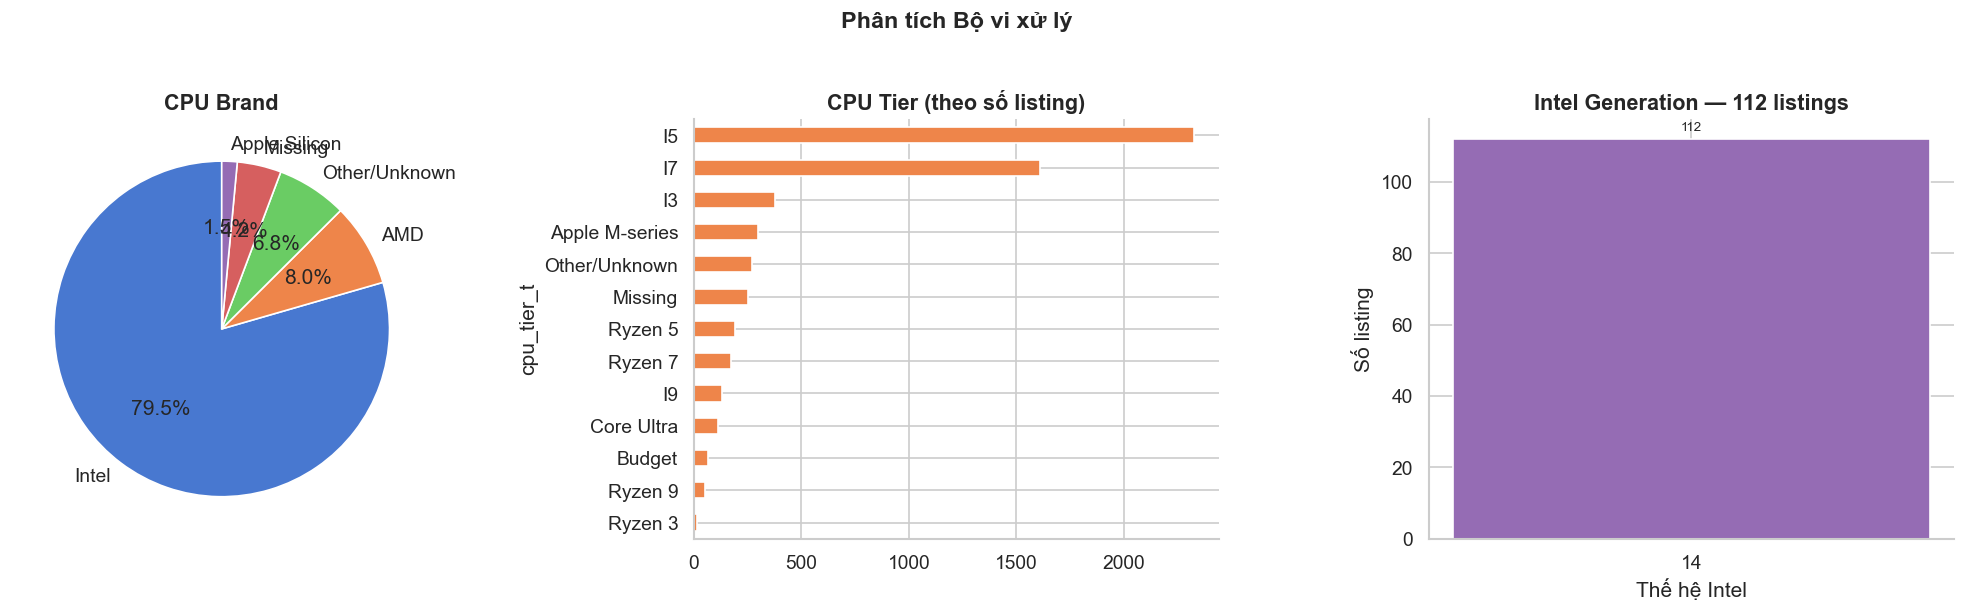

In [114]:
# ── Visualization CPU ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── CPU Brand ──────────────────────────────────────────────────────────────────
brand_vc = df['cpu_brand_t'].value_counts()
axes[0].pie(
    brand_vc.values,
    labels=brand_vc.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", len(brand_vc)),
    startangle=90
)
axes[0].set_title("CPU Brand")

# ── CPU Tier ───────────────────────────────────────────────────────────────────
tier_order = [
    'I9', 'I7', 'Core Ultra', 'I5', 'I3',
    'Ryzen 9', 'Ryzen 7', 'Ryzen 5', 'Ryzen 3',
    'Apple M-series', 'Budget', 'Missing', 'Other/Unknown'
]

tier_vc_raw = df['cpu_tier_t'].value_counts()
tier_vc = tier_vc_raw.reindex(tier_order).dropna()

tier_vc.sort_values().plot(
    kind='barh',
    ax=axes[1],
    color=COLORS[1]
)
axes[1].set_title("CPU Tier (theo số listing)")

# ── Intel Generation (bar chart, không phải histogram) ─────────────────────────
gen_vc = (
    df['intel_gen_t']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

if not gen_vc.empty:
    axes[2].bar(
        gen_vc.index.astype(str),
        gen_vc.values,
        color=COLORS[4],
        edgecolor='white'
    )

    axes[2].set_title(f"Intel Generation — {gen_vc.sum():,} listings")
    axes[2].set_xlabel("Thế hệ Intel")
    axes[2].set_ylabel("Số listing")

    # label trên cột
    for i, v in enumerate(gen_vc.values):
        axes[2].text(
            i,
            v + max(gen_vc.values) * 0.02,
            f"{v:,}",
            ha='center',
            fontsize=8
        )
else:
    axes[2].text(
        0.5, 0.5,
        "Không có dữ liệu",
        ha='center',
        va='center',
        transform=axes[2].transAxes
    )
    axes[2].set_title("Intel Generation")

# ── Style ──────────────────────────────────────────────────────────────────────
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Phân tích Bộ vi xử lý", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Phân tích Bộ vi xử lý

Biểu đồ cho thấy **CPU Intel chiếm ưu thế tuyệt đối (~79.5%)** trong tập dữ liệu, trong khi AMD (~8%) và Apple Silicon (~1–2%) chỉ chiếm tỷ trọng nhỏ. Ngoài ra vẫn còn một phần đáng kể thuộc nhóm **Other/Unknown và Missing**, cho thấy dữ liệu chưa được chuẩn hóa hoàn toàn.

Xét theo phân khúc hiệu năng (Tier), **Intel Core i5 và i7 là hai nhóm phổ biến nhất**, chiếm phần lớn số lượng listing, phản ánh thị trường tập trung vào phân khúc tầm trung và cận cao cấp. Các dòng Ryzen 5/7, Apple M-series và Core Ultra xuất hiện nhưng với số lượng thấp hơn, trong khi các dòng cao cấp (i9, Ryzen 9) và giá rẻ (Budget) chiếm tỷ trọng rất nhỏ.

Đối với Intel Generation, chỉ có **112 listing được trích xuất thế hệ và đều thuộc thế hệ 14**, chủ yếu từ dòng Core Ultra. Điều này cho thấy việc trích xuất generation hiện tại còn hạn chế và chưa phản ánh đầy đủ toàn bộ các thế hệ CPU trong dữ liệu. Do đó, cần cải thiện bước xử lý chuỗi để có cái nhìn chính xác hơn về phân bố thế hệ CPU.

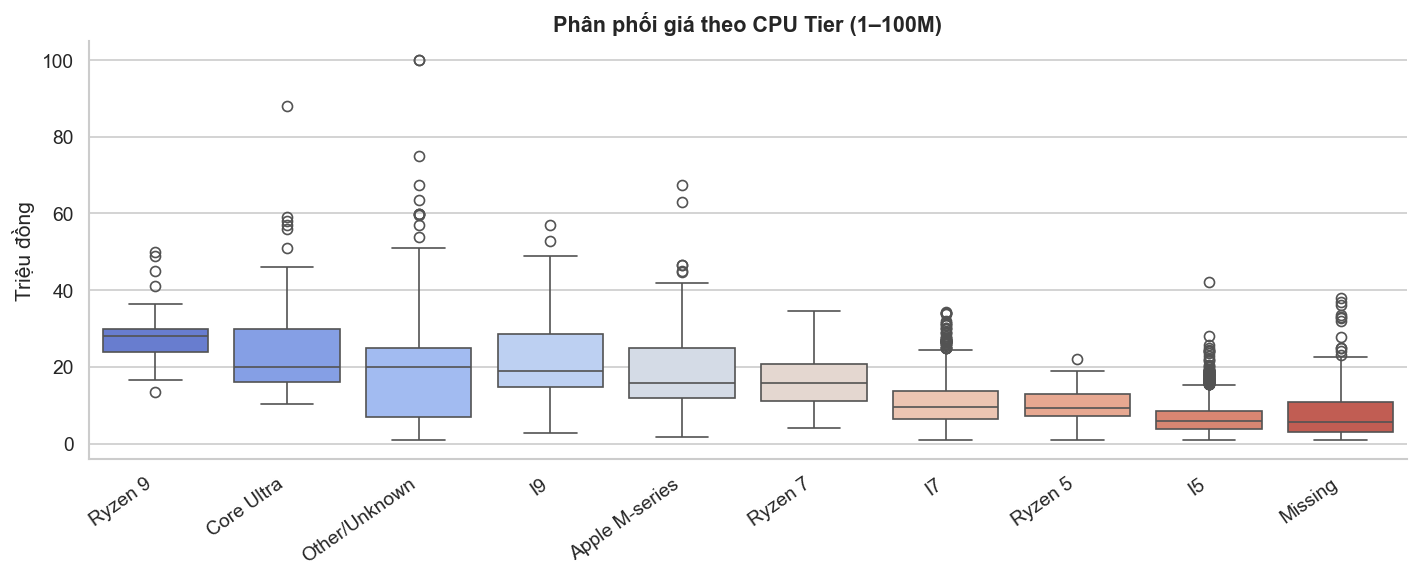

In [88]:
# ── Giá theo CPU Tier ────────────────────────────────────────────────────────────
price_cpu = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6))

tier_order_plot = (price_cpu.groupby('cpu_tier_t')['price_mil']
                   .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=price_cpu[price_cpu['cpu_tier_t'].isin(tier_order_plot[:10])],
            x='cpu_tier_t', y='price_mil',
            order=tier_order_plot[:10], palette='coolwarm', ax=ax)
ax.set_title("Phân phối giá theo CPU Tier (1–100M)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns=['cpu_brand_t', 'cpu_tier_t', 'intel_gen_t'], inplace=True, errors='ignore')


# Phân phối giá theo CPU Tier

Biểu đồ cho thấy giá laptop có xu hướng tăng theo phân khúc CPU, tuy nhiên mức độ phân tán giữa các nhóm khá lớn. Các dòng cao cấp như **Ryzen 9, Core Ultra và i9** có mức giá trung vị cao hơn và xuất hiện nhiều outlier ở mức rất cao (có thể trên 50–100 triệu), phản ánh phân khúc flagship hoặc gaming/workstation. Tuy nhiên, độ phân tán lớn cho thấy cùng một tier nhưng giá có thể khác biệt đáng kể tùy theo cấu hình khác (RAM, GPU, thương hiệu).

Các nhóm tầm trung như **i7, Ryzen 7 và Apple M-series** có mức giá trung bình thấp hơn nhưng vẫn khá rộng, cho thấy đây là phân khúc đa dạng sản phẩm nhất. Trong khi đó, **i5 và Ryzen 5** tập trung ở mức giá thấp hơn (khoảng 5–15 triệu), phù hợp với phân khúc phổ thông.

Đáng chú ý, nhóm **Other/Unknown và Missing** có độ phân tán rất lớn, xuất hiện nhiều giá trị cực cao, cho thấy dữ liệu chưa được phân loại chính xác và có thể gây nhiễu trong phân tích. Tổng thể, CPU là yếu tố ảnh hưởng rõ đến giá, nhưng không phải yếu tố duy nhất; cần kết hợp thêm các biến khác để đánh giá chính xác hơn.

In [122]:
# ── Deep CPU parsing: structured column + title (FIXED) ───────────────────────

cpu_col = "Bộ vi xử lý"

def norm_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x).lower()).strip()

df["_cpu_text_struct"] = df[cpu_col].map(norm_text)
df["_cpu_text_title"]  = df["title"].map(norm_text)
df["_cpu_text_all"]    = (df["_cpu_text_struct"] + " " + df["_cpu_text_title"]).str.strip()


# ── BRAND ─────────────────────────────────────────────────────────────────────
def cpu_brand_from_text(text):
    if not text:
        return "Missing"

    if re.search(r"\b(intel|core\s+i[3579]|i[3579]|celeron|pentium|xeon|core\s+ultra|ultra\s+[579])\b", text):
        return "Intel"

    if re.search(r"\b(amd|ryzen|athlon)\b", text):
        return "AMD"

    if re.search(r"\b(apple\s+silicon|m[1-4])\b", text):
        return "Apple Silicon"

    return "Other/Unknown"


# ── TIER ──────────────────────────────────────────────────────────────────────
def cpu_tier_from_text(text):
    if not text:
        return "Missing"

    if re.search(r"\b(core\s+ultra|ultra\s+[579])\b", text):
        return "Core Ultra"

    for tier in ["i9", "i7", "i5", "i3"]:
        if re.search(fr"\b(core\s+)?{tier}\b", text):
            return tier.upper()

    for tier in ["ryzen 9", "ryzen 7", "ryzen 5", "ryzen 3"]:
        if re.search(fr"\b{tier}\b", text):
            return tier.title()

    if re.search(r"\bm[1-4]\b", text):
        return "Apple M-series"

    if re.search(r"\b(celeron|pentium|athlon)\b", text):
        return "Budget"

    return "Other/Unknown"


# ── INTEL GEN (FIXED) ─────────────────────────────────────────────────────────
def extract_intel_gen(text):
    if not text:
        return np.nan

    # Core Ultra → treat as gen 14
    if re.search(r"\b(core\s+ultra|ultra\s+[579])\b", text):
        return 14

    m = re.search(r"\bi[3579]\s*[- ]?\s*(\d{4,5})\w*\b", text)
    if not m:
        return np.nan

    model_num = m.group(1)

    # 5-digit model: 12600, 13700 → gen = first 2 digits
    if len(model_num) == 5:
        return int(model_num[:2])

    # 4-digit model:
    # 8250 → 8
    # 1065 → 10
    # 1135 → 11
    if len(model_num) == 4:
        first_two = int(model_num[:2])
        if 10 <= first_two <= 14:
            return first_two
        return int(model_num[0])

    return np.nan


# ── AMD ───────────────────────────────────────────────────────────────────────
def extract_ryzen_series(text):
    if not text:
        return np.nan

    m = re.search(r"\bryzen\s+[3579]\s*[- ]?\s*(\d{4})\w*\b", text)
    if not m:
        return np.nan

    return int(m.group(1)[0])


# ── APPLE ─────────────────────────────────────────────────────────────────────
def extract_apple_m_gen(text):
    if not text:
        return np.nan

    m = re.search(r"\bm([1-4])\b", text)
    return int(m.group(1)) if m else np.nan


# ── APPLY ─────────────────────────────────────────────────────────────────────

# structured only
df["_cpu_brand_struct"] = df["_cpu_text_struct"].apply(cpu_brand_from_text)
df["_cpu_tier_struct"]  = df["_cpu_text_struct"].apply(cpu_tier_from_text)
df["_intel_gen_struct"] = df["_cpu_text_struct"].apply(extract_intel_gen)

# structured + title (quan trọng nhất)
df["_cpu_brand_all"]    = df["_cpu_text_all"].apply(cpu_brand_from_text)
df["_cpu_tier_all"]     = df["_cpu_text_all"].apply(cpu_tier_from_text)
df["_intel_gen_all"]    = df["_cpu_text_all"].apply(extract_intel_gen)
df["_ryzen_series_all"] = df["_cpu_text_all"].apply(extract_ryzen_series)
df["_apple_m_gen_all"]  = df["_cpu_text_all"].apply(extract_apple_m_gen)


display(
    df[[
        cpu_col, "title",
        "_cpu_brand_struct", "_cpu_tier_struct", "_intel_gen_struct",
        "_cpu_brand_all", "_cpu_tier_all", "_intel_gen_all",
        "_ryzen_series_all", "_apple_m_gen_all"
    ]].head(10)
)

,Bộ vi xử lý,title,_cpu_brand_struct,_cpu_tier_struct,_intel_gen_struct,_cpu_brand_all,_cpu_tier_all,_intel_gen_all,_ryzen_series_all,_apple_m_gen_all
0,Intel Core i7,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Intel,I7,NaN,Intel,I7,11.0,NaN,NaN
1,Intel Core i3,Acer Aspire A315-58 i3-1115G4,Intel,I3,NaN,Intel,I3,11.0,NaN,NaN
2,Intel Core i7,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,Intel,I7,NaN,Intel,I7,NaN,NaN,NaN
3,Intel Core Ultra,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Intel,Core Ultra,14.0,Intel,Core Ultra,14.0,NaN,NaN
4,NaN,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,Missing,Missing,NaN,Intel,I7,NaN,NaN,NaN
5,Intel Core i7,HP Elitebook 840 G5 i7 8650U 8GB/256GB,Intel,I7,NaN,Intel,I7,8.0,NaN,NaN
6,Intel Core i5,Dell Latitude 7300 i5 13 inch 12GB/256GB,Intel,I5,NaN,Intel,I5,NaN,NaN,NaN
7,Intel Core i5,MacBook Air 2019 | Core i5 | 16GB | 256GB,Intel,I5,NaN,Intel,I5,NaN,NaN,NaN
8,Intel Core i7,Acer Nitro Tiger 12700H RTX 3050 keng hãng 99%,Intel,I7,NaN,Intel,I7,NaN,NaN,NaN
9,Intel Core i5,Apple MacBook Pro 2017 i5 ram 8/128g zin all 99%,Intel,I5,NaN,Intel,I5,NaN,NaN,NaN


## Deep CPU Feature Analysis

### 1. Parsing từ structured và title

Kết hợp `Bộ vi xử lý` và `title` giúp cải thiện đáng kể việc trích xuất thông tin CPU. Nhiều trường hợp cột structured bị thiếu hoặc không đầy đủ, trong khi `title` lại chứa mã CPU chi tiết (ví dụ: `i7-1185G7`, `i5-1135G4`).

Điều này cho thấy với dữ liệu marketplace, `title` là nguồn thông tin quan trọng giúp giảm missing và tăng độ chính xác của feature.

---

### 2. Feature CPU đã trích xuất

Các feature chính bao gồm:

- `cpu_brand`: Intel / AMD / Apple Silicon
- `cpu_tier`: I3, I5, I7, I9, Core Ultra, Ryzen
- `intel_gen`: thế hệ Intel (8–14)
- `ryzen_series`: Ryzen 3–9
- `apple_m_gen`: M1–M4

Những feature này chuyển dữ liệu text thành dạng có thể dùng trực tiếp cho phân tích và modeling.

---

### 3. Chất lượng và hạn chế

Parsing hoạt động tốt với các pattern phổ biến và được cải thiện rõ khi dùng thêm `title`.

Tuy nhiên:
- Không thể suy ra `intel_gen` nếu chỉ có “i5/i7” mà thiếu model cụ thể
- Dữ liệu AMD và Apple còn ít → nhiều giá trị thiếu
- Một số pattern hiếm có thể chưa được bao phủ

---

### 4. Insight chính

`cpu_tier` là feature quan trọng nhất, thể hiện rõ phân khúc giá (I3 < I5 < I7 < I9).
`cpu_gen` chỉ có ý nghĩa khi so sánh trong cùng một tier.

Missing CPU không phải vô ích, vì vẫn có thể suy luận gián tiếp từ giá và các feature khác.

---

### 5. Hướng sử dụng

- Ưu tiên dùng `_cpu_*_all` thay vì `_struct`
- Sử dụng `cpu_tier` làm feature chính
- Kết hợp thêm `intel_gen` để tăng độ chi tiết
- Tạo flag cho các trường hợp missing

Bước xử lý này đã tạo ra các feature CPU đủ tốt cho giai đoạn cleaning và modeling tiếp theo.

In [125]:
# ── Coverage gain: structured CPU vs structured + title ────────────────────────

def known_rate(series):
    return (~series.isin(["Missing", "Other/Unknown"])).mean() * 100

coverage_cpu = pd.DataFrame({
    "Nguồn": [
        "Structured only",
        "Structured + title"
    ],
    "Known brand (%)": [
        known_rate(df["_cpu_brand_struct"]),
        known_rate(df["_cpu_brand_all"])
    ],
    "Known tier (%)": [
        known_rate(df["_cpu_tier_struct"]),
        known_rate(df["_cpu_tier_all"])
    ],
    "Known Intel gen (%)": [
        df["_intel_gen_struct"].notna().mean() * 100,
        df["_intel_gen_all"].notna().mean() * 100
    ],
    "Known Ryzen series (%)": [
        0,
        df["_ryzen_series_all"].notna().mean() * 100
    ],
    "Known Apple M gen (%)": [
        0,
        df["_apple_m_gen_all"].notna().mean() * 100
    ],
}).round(2)

display(coverage_cpu)

recover_mask = (
    df["_cpu_tier_struct"].isin(["Missing", "Other/Unknown"])
    & ~df["_cpu_tier_all"].isin(["Missing", "Other/Unknown"])
)

print(f"Số dòng recover được CPU tier từ title: {recover_mask.sum():,}")
print(f"Tỷ lệ trên toàn dataset: {recover_mask.mean() * 100:.2f}%")

if recover_mask.any():
    display(
        df.loc[recover_mask, [
            "title", cpu_col, "_cpu_tier_struct", "_cpu_tier_all",
            "_cpu_brand_all", "_intel_gen_all", "_price"
        ]].sort_values("_price", ascending=False).head(20)
    )

,Nguồn,Known brand (%),Known tier (%),Known Intel gen (%),Known Ryzen series (%),Known Apple M gen (%)
0,Structured only,93.83,92.43,1.91,0.00,0.00
1,Structured + title,95.35,93.93,43.35,1.06,6.92


Số dòng recover được CPU tier từ title: 88
Tỷ lệ trên toàn dataset: 1.50%


,title,Bộ vi xử lý,_cpu_tier_struct,_cpu_tier_all,_cpu_brand_all,_intel_gen_all,_price
638,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,Khác,Other/Unknown,Core Ultra,Intel,14.0,99900000.0
4838,ASUS ROG Strix SCAR 16 Ultra 9 32GB/8TB RTX 5090,Khác,Other/Unknown,Core Ultra,Intel,14.0,99900000.0
2774,Apple Macbook Pro M4 14 inch 16GB/512GB,NaN,Missing,Apple M-series,Apple Silicon,NaN,33000000.0
4437,Macbook Pro M4 16/512,NaN,Missing,Apple M-series,Apple Silicon,NaN,32790000.0
3239,Apple MacBook Pro M4 Bạc Mới,NaN,Missing,Apple M-series,Apple Silicon,NaN,32000000.0
2675,"Helios Neo14, ultra 7-155H,16G,1TB,RTX4070 ful box",Khác,Other/Unknown,Core Ultra,Intel,14.0,29500000.0
3698,Lenovo ThinkPad P14s Gen 5 Ultra 5 14.5 inch,Khác,Other/Unknown,Core Ultra,Intel,14.0,27900000.0
574,ASUS Zenbook 14 OLED Ultra 9 32GB/1TB,Khác,Other/Unknown,Core Ultra,Intel,14.0,25000000.0
1821,Acer Predator Helios Neo 16 i7-14700HX,NaN,Missing,I7,Intel,14.0,25000000.0
4442,Surface Laptop 7 Ultra 7/16/512,Khác,Other/Unknown,Core Ultra,Intel,14.0,24500000.0


### Coverage Improvement khi dùng title

Việc bổ sung `title` giúp cải thiện nhẹ khả năng nhận diện `cpu_brand` và `cpu_tier`, nhưng cải thiện rất mạnh đối với `intel_gen` (từ ~2% lên ~43%). Điều này cho thấy thông tin về model CPU chủ yếu nằm trong tiêu đề, không có trong cột structured.

Khoảng 1.5% dữ liệu (88 dòng) có thể recover `cpu_tier` từ `title`. Dù tỷ lệ nhỏ, nhưng các trường hợp này thường thuộc phân khúc cao (gaming, MacBook), nên có giá trị lớn.

Các sản phẩm Apple và nhiều laptop cao cấp thường thiếu thông tin CPU ở cột structured nhưng lại có đầy đủ trong `title`. Điều này phản ánh đặc trưng của dữ liệu marketplace.

Tổng thể, `title` là nguồn thông tin quan trọng và nên được sử dụng để xây dựng feature. Trong các bước tiếp theo, nên ưu tiên dùng các biến `_cpu_*_all` thay vì `_cpu_*_struct`.

In [126]:
# ── Robust price statistics by CPU tier ────────────────────────────────────────

price_cpu_deep = (
    df[df["_price"].between(1e6, 100e6)]
    .copy()
    .assign(price_mil=lambda x: x["_price"] / 1e6)
)

tier_stats = (
    price_cpu_deep
    .groupby("_cpu_tier_all")
    .agg(
        n=("price_mil", "size"),
        mean_mil=("price_mil", "mean"),
        median_mil=("price_mil", "median"),
        p25_mil=("price_mil", lambda s: s.quantile(0.25)),
        p75_mil=("price_mil", lambda s: s.quantile(0.75)),
        p90_mil=("price_mil", lambda s: s.quantile(0.90)),
        min_mil=("price_mil", "min"),
        max_mil=("price_mil", "max"),
    )
    .assign(
        iqr_mil=lambda x: x["p75_mil"] - x["p25_mil"]
    )
    .sort_values("median_mil", ascending=False)
)

# Chỉ giữ nhóm đủ quan sát để tránh kết luận từ sample quá nhỏ
tier_stats_filtered = tier_stats[tier_stats["n"] >= 20].copy()

if "I5" in tier_stats_filtered.index:
    i5_median = tier_stats_filtered.loc["I5", "median_mil"]
    tier_stats_filtered["premium_vs_i5_%"] = (
        (tier_stats_filtered["median_mil"] / i5_median - 1) * 100
    )

display(tier_stats_filtered.round(2))

,n,mean_mil,median_mil,p25_mil,p75_mil,p90_mil,min_mil,max_mil,iqr_mil,premium_vs_i5_%
_cpu_tier_all,,,,,,,,,,
Ryzen 9,49,27.72,27.99,23.90,29.80,35.22,13.3,50.00,5.90,374.41
Core Ultra,126,25.64,19.99,16.39,29.72,39.25,10.2,99.90,13.34,238.90
I9,134,21.97,18.94,14.50,28.35,34.63,2.7,57.00,13.85,221.00
Apple M-series,397,20.67,18.50,12.50,26.00,34.20,1.6,67.50,13.50,213.56
Ryzen 7,174,15.93,15.75,10.99,20.50,23.84,4.0,34.50,9.50,166.95
I7,1648,10.56,9.50,6.50,13.50,18.49,1.0,34.29,7.00,61.02
Ryzen 5,189,9.93,9.20,7.00,12.79,14.50,1.0,22.00,5.79,55.93
Other/Unknown,298,11.54,6.50,2.75,16.50,27.76,1.0,74.90,13.75,10.17
I5,2285,6.72,5.90,3.90,8.50,12.00,1.0,42.00,4.60,0.00


### Price theo CPU Tier

Giá sản phẩm tăng rõ rệt theo phân khúc CPU. Các dòng cao cấp như Ryzen 9, Core Ultra, i9 và Apple M-series có median price cao nhất, trong khi i3 và nhóm Budget thấp nhất.

`cpu_tier` thể hiện rất rõ sức mạnh phân loại giá:
- I5 được dùng làm baseline (~5.9 triệu)
- I7 cao hơn ~60%
- i9 / Core Ultra / Apple M-series cao hơn >200%

Các dòng AMD Ryzen cũng cho thấy phân tầng hợp lý (Ryzen 5 < Ryzen 7 < Ryzen 9).

Độ phân tán giá (IQR) lớn hơn ở các tier cao, cho thấy sự đa dạng cấu hình (GPU, RAM, brand). Ngược lại, các tier thấp có phân phối giá hẹp hơn.

Kết luận: `cpu_tier` là một trong những feature quan trọng nhất để dự đoán giá.

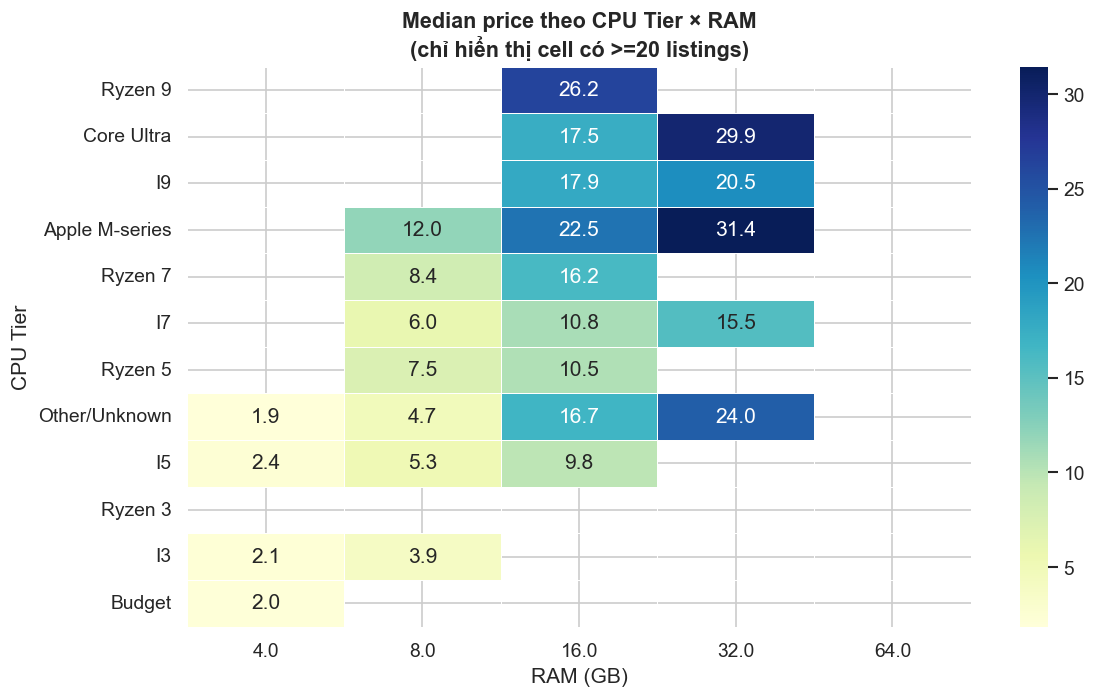

_ram_gb_cpu_tmp,4.0,8.0,16.0,32.0,64.0
_cpu_tier_all,,,,,
Ryzen 9,0,0,44,5,0
Core Ultra,0,0,86,36,3
I9,0,1,82,42,8
Apple M-series,5,143,170,44,8
Ryzen 7,0,22,137,11,1
I7,7,454,1024,130,1
Ryzen 5,0,73,110,4,0
Other/Unknown,41,57,75,29,2
I5,144,1455,620,15,0


In [127]:
# ── CPU tier × RAM interaction ─────────────────────────────────────────────────

def parse_ram_gb_for_cpu(val):
    if pd.isna(val):
        return np.nan

    v = str(val).upper().strip()

    if "<1" in v:
        return 0.5
    if ">128" in v:
        return 256
    if ">32" in v:
        return 64

    m = re.search(r"(\d+)\s*GB", v)
    return float(m.group(1)) if m else np.nan


df["_ram_gb_cpu_tmp"] = df["RAM"].apply(parse_ram_gb_for_cpu)

cpu_ram = (
    df[df["_price"].between(1e6, 100e6)]
    .copy()
    .assign(price_mil=lambda x: x["_price"] / 1e6)
)

# Median price matrix
median_matrix = (
    cpu_ram
    .pivot_table(
        index="_cpu_tier_all",
        columns="_ram_gb_cpu_tmp",
        values="price_mil",
        aggfunc="median"
    )
)

# Count matrix để mask nhóm quá ít mẫu
count_matrix = (
    cpu_ram
    .pivot_table(
        index="_cpu_tier_all",
        columns="_ram_gb_cpu_tmp",
        values="price_mil",
        aggfunc="size"
    )
)

# Sắp xếp tier theo median price tổng thể
tier_order_by_price = (
    cpu_ram
    .groupby("_cpu_tier_all")["price_mil"]
    .median()
    .sort_values(ascending=False)
    .index
)

median_matrix = median_matrix.reindex(tier_order_by_price)

# Chỉ giữ các RAM phổ biến
common_ram_cols = [c for c in [4, 8, 16, 32, 64] if c in median_matrix.columns]
median_matrix = median_matrix[common_ram_cols]
count_matrix = count_matrix.reindex(tier_order_by_price)[common_ram_cols]

# Mask cell có sample nhỏ
median_matrix_masked = median_matrix.mask(count_matrix < 20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    median_matrix_masked,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Median price theo CPU Tier × RAM\n(chỉ hiển thị cell có >=20 listings)")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("CPU Tier")
plt.tight_layout()
plt.show()

display(count_matrix.fillna(0).astype(int))

### Tương quan CPU Tier × RAM với giá

Giá tăng đồng thời theo cả CPU tier và dung lượng RAM. Với cùng một CPU, việc nâng RAM (ví dụ từ 8GB lên 16GB hoặc 32GB) làm tăng giá rõ rệt. Ngược lại, với cùng mức RAM, các tier CPU cao hơn (I7, i9, Core Ultra, Apple M-series) luôn có giá cao hơn đáng kể so với các tier thấp.

Sự kết hợp giữa CPU và RAM tạo ra hiệu ứng cộng hưởng: các cấu hình cao (CPU mạnh + RAM lớn) có mức giá vượt trội, đặc biệt ở các dòng cao cấp như Apple M-series, i9 hoặc Core Ultra.

Ngoài ra, độ chênh lệch giá giữa các mức RAM lớn hơn ở các CPU tier cao, cho thấy phân khúc này có nhiều biến thể cấu hình hơn (GPU, build, brand).

Kết luận: giá không phụ thuộc vào CPU hoặc RAM riêng lẻ mà phụ thuộc mạnh vào sự kết hợp của cả hai, do đó nên xem xét feature interaction giữa `cpu_tier` và `ram`.

### Phân bố số lượng theo CPU Tier × RAM

Phân bố dữ liệu không đồng đều giữa các tổ hợp CPU và RAM. Phần lớn listings tập trung ở các cấu hình phổ biến:

- I5 và I7 chủ yếu đi với 8GB và 16GB RAM
- 16GB là mức RAM phổ biến nhất ở hầu hết các CPU tier
- 32GB và 64GB chỉ xuất hiện nhiều ở các dòng cao cấp (i7, i9, Core Ultra, Apple M-series)

Các cấu hình thấp như I3 hoặc Budget gần như chỉ xuất hiện ở 4GB–8GB, rất ít hoặc không có ở RAM cao.

Ngoài ra, một số tổ hợp có rất ít mẫu (ví dụ Ryzen 3, RAM 32GB+), nên các giá trị median ở heatmap có thể không ổn định. Điều này giải thích việc chỉ hiển thị các cell có ≥20 listings trong biểu đồ trước đó.

Kết luận: dữ liệu bị skew về các cấu hình phổ biến (I5/I7 + 8–16GB), do đó cần cẩn trọng khi phân tích hoặc modeling với các nhóm hiếm.

In [130]:
# ── CPU-tier price outlier inspection ──────────────────────────────────────────

price_cpu_outlier = (
    df[df["_price"].between(1e6, 100e6)]
    .copy()
    .assign(price_mil=lambda x: x["_price"] / 1e6)
)

tier_bounds = (
    price_cpu_outlier
    .groupby("_cpu_tier_all")["price_mil"]
    .agg(
        tier_n="size",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        median="median"
    )
)

tier_bounds["iqr"] = tier_bounds["q3"] - tier_bounds["q1"]
tier_bounds["lower_bound"] = tier_bounds["q1"] - 1.5 * tier_bounds["iqr"]
tier_bounds["upper_bound"] = tier_bounds["q3"] + 1.5 * tier_bounds["iqr"]

price_cpu_outlier = price_cpu_outlier.merge(
    tier_bounds,
    left_on="_cpu_tier_all",
    right_index=True,
    how="left"
)

price_cpu_outlier["_cpu_price_flag"] = np.select(
    [
        (price_cpu_outlier["tier_n"] >= 30) & (price_cpu_outlier["price_mil"] < price_cpu_outlier["lower_bound"]),
        (price_cpu_outlier["tier_n"] >= 30) & (price_cpu_outlier["price_mil"] > price_cpu_outlier["upper_bound"]),
    ],
    [
        "low_vs_cpu_tier",
        "high_vs_cpu_tier"
    ],
    default="normal"
)

outlier_summary = (
    price_cpu_outlier["_cpu_price_flag"]
    .value_counts()
    .to_frame("count")
    .assign(pct=lambda x: x["count"] / len(price_cpu_outlier) * 100)
    .round(2)
)

display(outlier_summary)

print("=== Giá cao bất thường so với CPU tier ===")
display(
    price_cpu_outlier[price_cpu_outlier["_cpu_price_flag"] == "high_vs_cpu_tier"]
    .sort_values("price_mil", ascending=False)
    [[
        "title", "Hãng", "Dòng máy", cpu_col,
        "_cpu_tier_all", "_cpu_brand_all",
        "RAM", "Card màn hình", "Ổ cứng",
        "price_mil", "median", "upper_bound"
    ]]
    .head(10)
)

print("=== Giá thấp bất thường so với CPU tier ===")
display(
    price_cpu_outlier[price_cpu_outlier["_cpu_price_flag"] == "low_vs_cpu_tier"]
    .sort_values("price_mil", ascending=True)
    [[
        "title", "Hãng", "Dòng máy", cpu_col,
        "_cpu_tier_all", "_cpu_brand_all",
        "RAM", "Card màn hình", "Ổ cứng",
        "price_mil", "median", "lower_bound"
    ]]
    .head(10)
)

,count,pct
_cpu_price_flag,,
normal,5526,96.85
high_vs_cpu_tier,179,3.14
low_vs_cpu_tier,1,0.02


=== Giá cao bất thường so với CPU tier ===


,title,Hãng,Dòng máy,Bộ vi xử lý,_cpu_tier_all,_cpu_brand_all,RAM,Card màn hình,Ổ cứng,price_mil,median,upper_bound
638,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,Asus,ROG Strix Scar 16,Khác,Core Ultra,Intel,32 GB,NVIDIA,> 1 TB,99.9,19.995,49.73500
4838,ASUS ROG Strix SCAR 16 Ultra 9 32GB/8TB RTX 5090,Asus,ROG Strix Scar 16,Khác,Core Ultra,Intel,32 GB,NVIDIA,> 1 TB,99.9,19.995,49.73500
2689,Razer Blade 18 2025 Ultra 9 275HX RTX5080 4K 240Hz,Razer,Blade,Intel Core Ultra,Core Ultra,Intel,32 GB,NVIDIA,> 1 TB,88.0,19.995,49.73500
340,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,Apple,Dòng Khác,Khác,Other/Unknown,Other/Unknown,<1 GB,Onboard,1 TB,74.9,6.500,37.11875
5651,MacBook Pro 16 inch M5 Pro 24/1TB Black LL Newseal,Apple,MacBook Pro,Khác,Other/Unknown,Other/Unknown,16 GB,Khác,1 TB,67.5,6.500,37.11875
3212,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,Apple,Dòng Khác,M3 Pro,Apple M-series,Apple Silicon,16 GB,Khác,1 TB,67.5,18.500,46.25000
1367,MB Pro 16” M4 Pro 48Gb/1Tb - Cấu hình khủng,Apple,Macbook pro m4 pro,M4 Pro (14-core),Apple M-series,Apple Silicon,48 GB,Onboard,1 TB,63.5,18.500,46.25000
1708,Macbook M3 MAX 16' Spaceblack Ram 36GB / Ssd 1TB,Apple,Macbook Pro M3,M3 Max,Apple M-series,Apple Silicon,>32 GB,Onboard,1 TB,62.9,18.500,46.25000
1347,Macbook Pro M4 MAX 16' 36GB/1TB Đẹp keng,Apple,Macbook pro m4 max,M4 Max (16-core),Apple M-series,Apple Silicon,<1 GB,Onboard,1 TB,59.9,18.500,46.25000
195,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal,Apple,Dòng Khác,Khác,Other/Unknown,Other/Unknown,<1 GB,Khác,1 TB,59.9,6.500,37.11875


=== Giá thấp bất thường so với CPU tier ===


,title,Hãng,Dòng máy,Bộ vi xử lý,_cpu_tier_all,_cpu_brand_all,RAM,Card màn hình,Ổ cứng,price_mil,median,lower_bound
5245,"Asus Vivobook Pro 14 R9 5900HX 16 512 AMD 14"" 2.8K",Asus,Vivobook 14X OLED,Ryzen 9,Ryzen 9,AMD,16 GB,AMD,512 GB,13.3,27.99,15.05


### Outlier theo CPU Tier

Phần lớn dữ liệu nằm trong phạm vi hợp lý (≈97%), chỉ khoảng 3.1% có giá cao bất thường so với CPU tier và gần như không có giá thấp bất thường.

Các trường hợp giá cao bất thường chủ yếu thuộc phân khúc cao cấp như Core Ultra, i9 và Apple M-series. Đây thường là các máy có cấu hình mạnh (RAM lớn, GPU rời, SSD dung lượng cao) hoặc thuộc dòng premium (ROG, MacBook), nên giá cao không hẳn là lỗi mà phản ánh cấu hình vượt trội so với mặt bằng chung của cùng CPU tier.

Ngược lại, gần như không có trường hợp giá thấp bất thường, cho thấy dữ liệu ít nhiễu ở phía giá thấp.

Kết luận: outlier giá cao chủ yếu là do cấu hình và brand, không nên loại bỏ mà nên giữ lại hoặc xử lý bằng feature bổ sung (RAM, GPU, brand).

## 13. Column: `RAM`

Missing ~4%. Text dạng `"8 GB"` — cần extract số GB.


In [89]:
display(df['RAM'].value_counts(dropna=False).to_frame())

,count
RAM,
8 GB,2454
16 GB,2369
4 GB,388
32 GB,316
NaN,239
6 GB,34
2 GB,25
64 GB,16
<1 GB,7


In [90]:
# ── Extract GB ──────────────────────────────────────────────────────────────────
df['ram_gb'] = pd.to_numeric(df['RAM'].str.extract(r'(\d+)')[0], errors='coerce')

# Giá trị bất thường
out_ram = df[df['ram_gb'].notna() & ((df['ram_gb'] < 4) | (df['ram_gb'] > 128))]
print(f"RAM bất thường (< 4 GB hoặc > 128 GB): {len(out_ram)} rows")
if len(out_ram) > 0:
    display(out_ram[['RAM', 'ram_gb', 'title']].head(10))


RAM bất thường (< 4 GB hoặc > 128 GB): 32 rows


,RAM,ram_gb,title
87,<1 GB,1.0,Macbook pro M3 PRO 14' Spaceblack Ram 36/Ssd 512GB
195,<1 GB,1.0,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal
340,<1 GB,1.0,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu
551,2 GB,2.0,Asus E502S Intel N3050 15 inch 2GB Đã sử dụng
782,2 GB,2.0,HP Pavilion Intel Core2 Duo T9400
959,2 GB,2.0,Acer Aspire 4730 Core 2 Duo 14 inch
1209,2 GB,2.0,Dư thanh lý laptop hp11 inch
1347,<1 GB,1.0,Macbook Pro M4 MAX 16' 36GB/1TB Đẹp keng
1376,2 GB,2.0,Asus X453MA Pentium N3540
1643,2 GB,2.0,Máy tính xách tay Đa màu


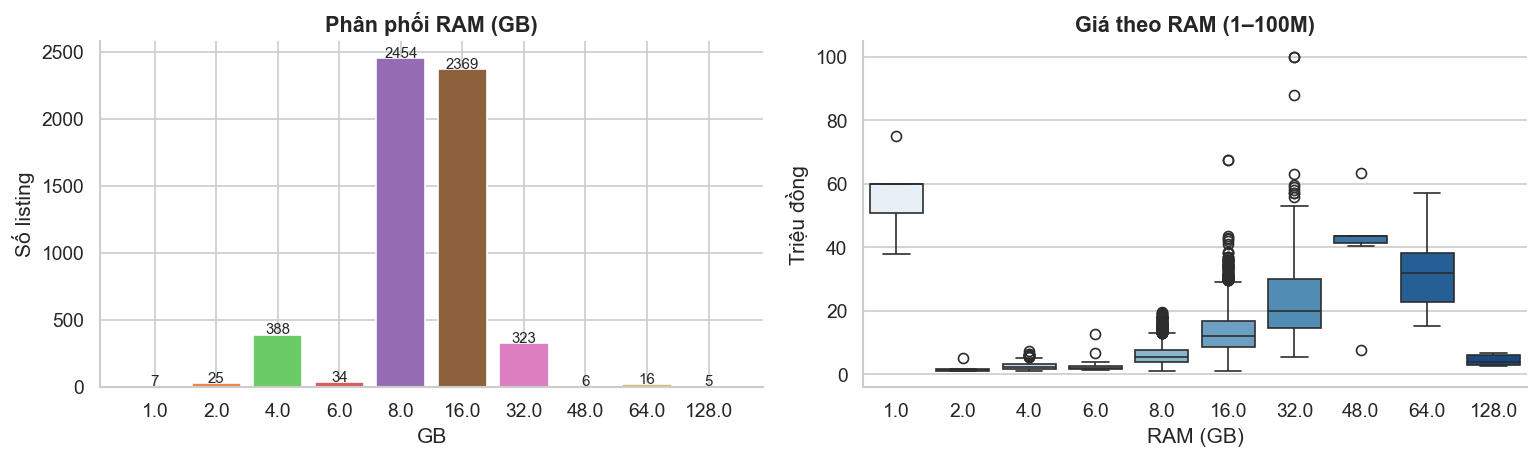

In [91]:
# ── Visualization RAM ───────────────────────────────────────────────────────────
ram_vc = df['ram_gb'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ram_vc.index.astype(str), ram_vc.values,
            color=COLORS[:len(ram_vc)], edgecolor='white')
axes[0].set_title("Phân phối RAM (GB)")
axes[0].set_xlabel("GB")
axes[0].set_ylabel("Số listing")
for i, (x, v) in enumerate(zip(ram_vc.index.astype(str), ram_vc.values)):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Giá theo RAM
price_ram = (df[df['_price'].between(1e6, 100e6) & df['ram_gb'].notna()]
             .assign(price_mil=lambda x: x['_price']/1e6))
ram_order = sorted(price_ram['ram_gb'].unique())
sns.boxplot(data=price_ram, x='ram_gb', y='price_mil',
            order=ram_order, palette='Blues', ax=axes[1])
axes[1].set_title("Giá theo RAM (1–100M)")
axes[1].set_xlabel("RAM (GB)")
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='ram_gb', inplace=True, errors='ignore')


## 14. Column: `Card màn hình`

Missing cao nhất (~24%). Missing **có thể mang nghĩa**: máy dùng integrated GPU, không có dedicated card.  
Phân loại 3 tier: Dedicated → Integrated → Unknown/Missing.


In [92]:
print(f"Distinct GPU values: {df['Card màn hình'].nunique()}")
print("\nTop 30:")
display(df['Card màn hình'].value_counts().head(30).to_frame())


Distinct GPU values: 4

Top 30:


,count
Card màn hình,
Onboard,2565
NVIDIA,1458
Khác,247
AMD,175


In [93]:
# ── Phân loại GPU ──────────────────────────────────────────────────────────────
def gpu_tier(val):
    if pd.isna(val): return 'Missing'
    v = str(val)
    # FIX: RTX 3060/3070/4060... pattern: RTX + (3|4) + 3-digit model
    if re.search(r'RTX\s?[34]\d{3}', v, re.I): return 'Dedicated — High (RTX 30/40)'
    # RTX 20 series + GTX 1660/1650
    if re.search(r'RTX\s?2\d{3}|GTX\s?16[56]0', v, re.I): return 'Dedicated — Mid (RTX 20 / GTX 16)'
    # Other dedicated: GTX 10xx, Quadro, AMD RX
    if re.search(r'GTX|Quadro|GeForce|NVIDIA|Radeon\s?RX|RX\s?\d{3,4}|Radeon\s?Pro', v, re.I): return 'Dedicated — Other/Entry'
    # Integrated Intel
    if re.search(r'Intel|Iris|UHD|HD\s?Graphics|integrated|tích hợp', v, re.I): return 'Integrated — Intel'
    # Integrated AMD Radeon (no RX suffix → integrated)
    if re.search(r'Radeon', v, re.I) and not re.search(r'RX\s?\d', v, re.I): return 'Integrated — AMD Radeon'
    return 'Unclear'

df['gpu_tier'] = df['Card màn hình'].apply(gpu_tier)
gpu_vc = df['gpu_tier'].value_counts()
print(gpu_vc.to_string())

# Spot-check: xem thử các giá trị thực tế trong mỗi tier
for tier in gpu_vc.index[:4]:
    samples = df[df['gpu_tier'] == tier]['Card màn hình'].dropna().value_counts().head(3).index.tolist()
    print(f"  {tier}: {samples}")

gpu_tier
Unclear                    2987
Dedicated — Other/Entry    1458
Missing                    1421
  Unclear: ['Onboard', 'Khác', 'AMD']
  Dedicated — Other/Entry: ['NVIDIA']
  Missing: []


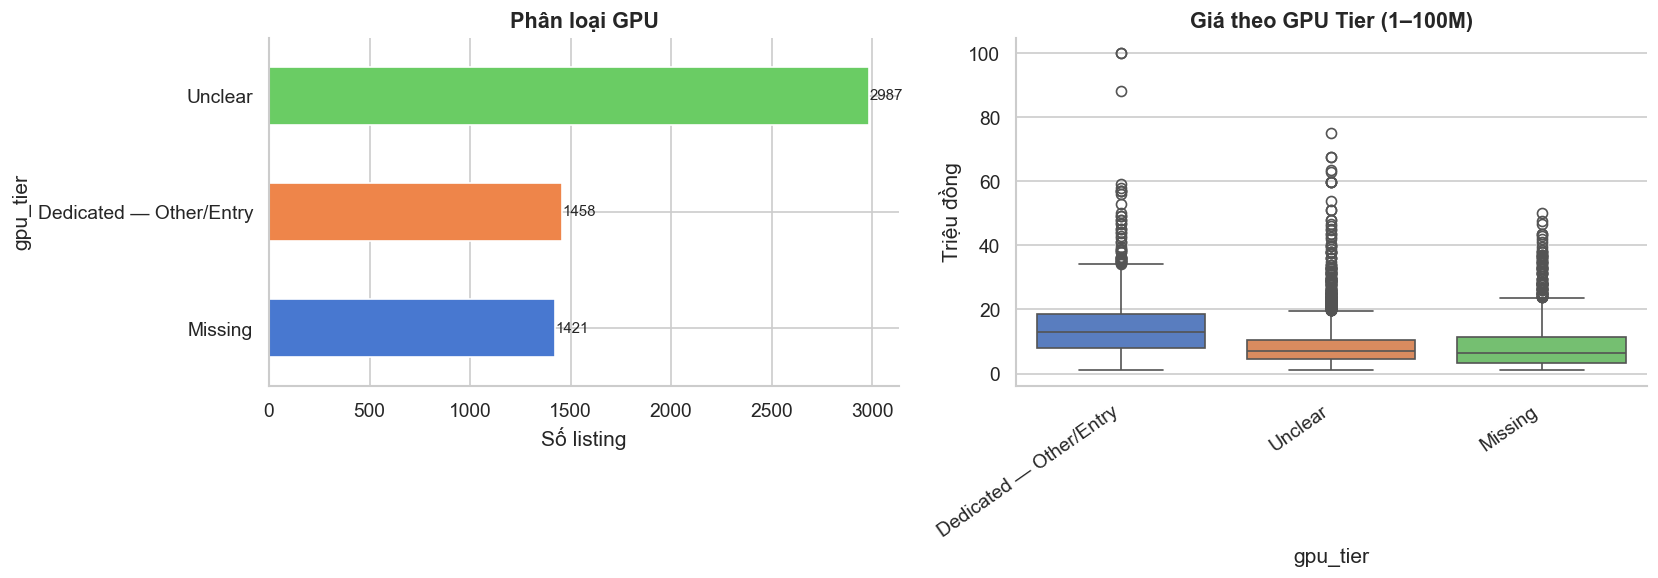

In [94]:
# ── Visualization GPU ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count bar
gpu_vc.sort_values().plot(kind='barh', ax=axes[0],
                          color=sns.color_palette("muted", len(gpu_vc)))
axes[0].set_title("Phân loại GPU")
axes[0].set_xlabel("Số listing")
for i, v in enumerate(gpu_vc.sort_values().values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=9)

# Giá theo GPU tier
price_gpu = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6))
order_gpu = (price_gpu.groupby('gpu_tier')['price_mil']
             .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_gpu, x='gpu_tier', y='price_mil',
            order=order_gpu, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo GPU Tier (1–100M)")
axes[1].set_ylabel("Triệu đồng")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


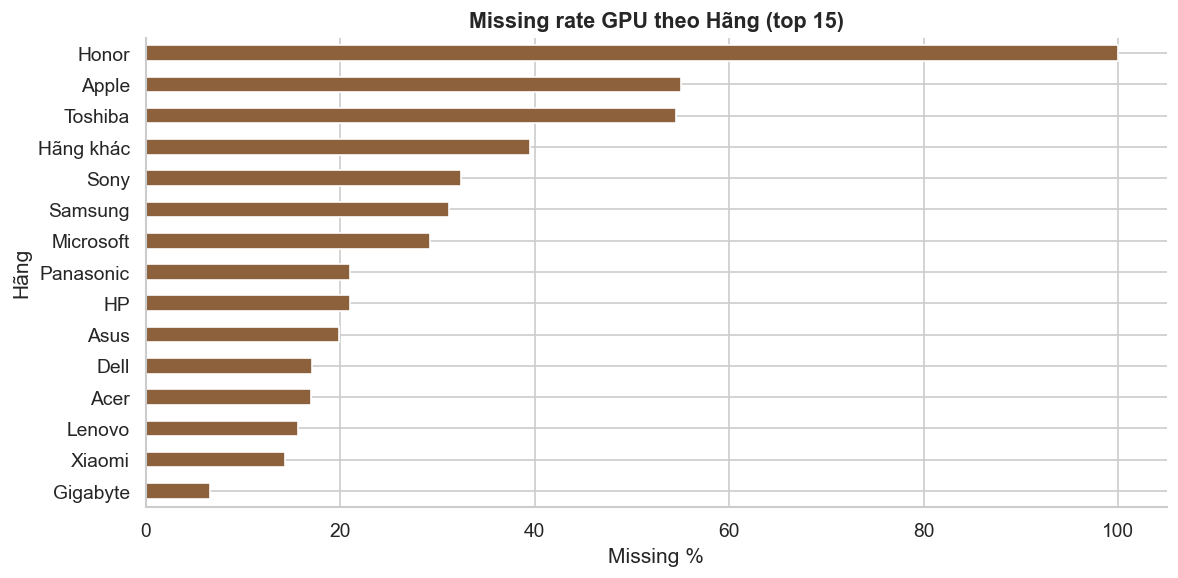


Laptop gaming (title/dòng máy) mà thiếu GPU: 24


,title,Dòng máy,Card màn hình,price
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,Inspiron,NaN,2.900.000 đ
435,Laptop Asus TUF Gaming F15 FX506HC 15.6 inch 16GB,TUF Gaming F15,NaN,11.000.000 đ
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,Dòng Khác,NaN,13.000.000 đ
1010,Acer Nitro 5 i5 9300h 16GB Đã dùng,Nitro 5,NaN,5.000.000 đ
1200,⚡ ACER NITRO V 15 - I7-13620H | RTX 4060,Aspire Nitro,NaN,22.200.000 đ
1458,ASUS TUF Gaming FX505GD i5-8300H 16GB,TUF Gaming,NaN,6.850.000 đ
1650,HP Victus Gaming i5-12450H 16GB/512GB,Victus,NaN,12.000.000 đ
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,Gaming G15,NaN,24.000.000 đ


In [95]:
# ── Missing GPU có hệ thống theo Hãng? ──────────────────────────────────────────
gpu_miss_rate = (df.assign(gpu_missing=df['Card màn hình'].isna())
                 .groupby('Hãng')['gpu_missing']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
gpu_miss_rate.sort_values().plot(kind='barh', ax=ax, color=COLORS[5])
ax.set_title("Missing rate GPU theo Hãng (top 15)")
ax.set_xlabel("Missing %")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Gaming laptop mà thiếu GPU?
gaming_pat = r'(ROG|TUF|Gaming|Legion|Predator|Nitro|Katana|Raider|Titan)'
is_gaming = (df['title'].str.contains(gaming_pat, case=False, na=False) |
             df['Dòng máy'].str.contains(gaming_pat, case=False, na=False))
gaming_no_gpu = is_gaming & df['Card màn hình'].isna()
print(f"\nLaptop gaming (title/dòng máy) mà thiếu GPU: {gaming_no_gpu.sum()}")
if gaming_no_gpu.sum() > 0:
    display(df[gaming_no_gpu][['title', 'Dòng máy', 'Card màn hình', 'price']].head(8))

df.drop(columns='gpu_tier', inplace=True, errors='ignore')


## 15. Column: `Ổ cứng` & `Loại ổ cứng`

Hai cột liên quan chặt: dung lượng và loại. Missing lần lượt ~8% và ~12%. Kiểm tra inconsistency và convert về GB.


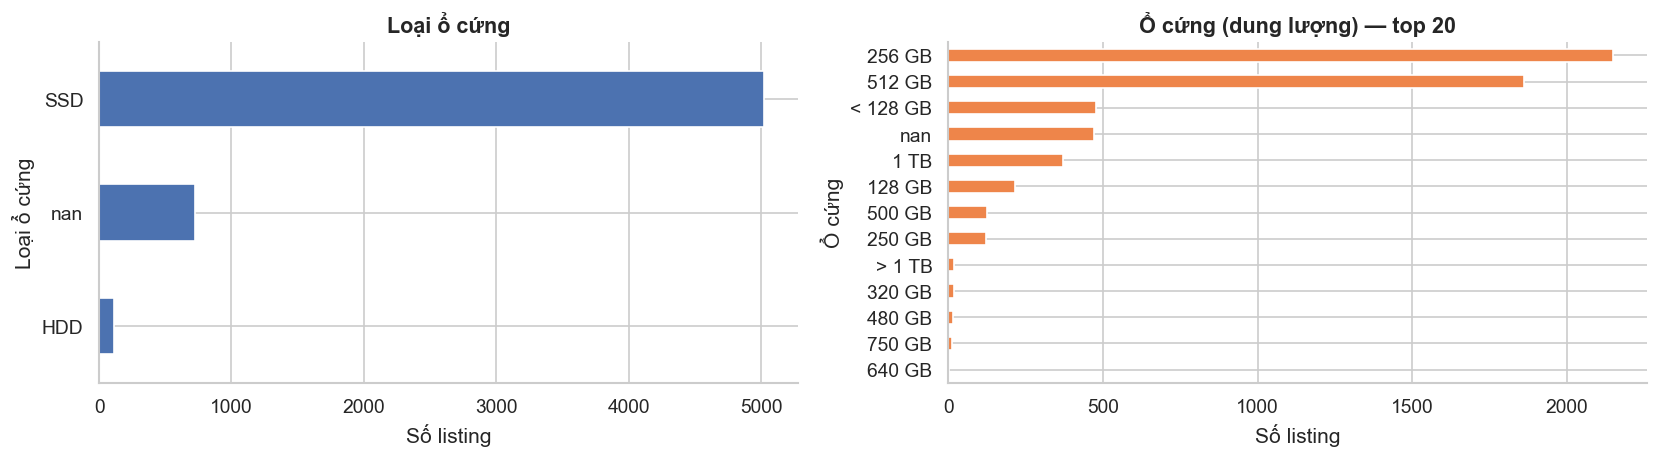

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loại ổ cứng
loai_vc = df['Loại ổ cứng'].value_counts(dropna=False)
loai_vc_plot = loai_vc[:10].sort_values()
loai_vc_plot.plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Loại ổ cứng")
axes[0].set_xlabel("Số listing")

# Ổ cứng (dung lượng)
ocung_vc = df['Ổ cứng'].value_counts(dropna=False).head(20).sort_values()
ocung_vc.plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title("Ổ cứng (dung lượng) — top 20")
axes[1].set_xlabel("Số listing")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [97]:
# ── Inconsistency ────────────────────────────────────────────────────────────────
case1 = df['Loại ổ cứng'].notna() & df['Ổ cứng'].isna()
case2 = df['Loại ổ cứng'].isna() & df['Ổ cứng'].notna()
both_missing = df['Loại ổ cứng'].isna() & df['Ổ cứng'].isna()
print(f"Có Loại nhưng không có Dung lượng: {case1.sum()}")
print(f"Có Dung lượng nhưng không có Loại:  {case2.sum()}")
print(f"Cả hai đều missing:                  {both_missing.sum()}")


Có Loại nhưng không có Dung lượng: 128
Có Dung lượng nhưng không có Loại:  384
Cả hai đều missing:                  342


In [98]:
# ── Convert về GB (parse_storage_gb đã định nghĩa ở Setup) ────────────────────
df['storage_gb'] = df['Ổ cứng'].apply(parse_storage_gb)
storage_vc = df['storage_gb'].value_counts().sort_index()
print("Phân phối dung lượng ổ cứng (GB):")
display(storage_vc.to_frame().rename(columns={'storage_gb': 'count'}))

# Giá trị bất thường
out_stor = df[df['storage_gb'].notna() & ((df['storage_gb'] < 32) | (df['storage_gb'] > 4096))]
print(f"\nStorage bất thường (< 32 GB hoặc > 4 TB): {len(out_stor)} rows")
if len(out_stor) > 0:
    display(out_stor[['Ổ cứng', 'storage_gb', 'title']].head(5))

Phân phối dung lượng ổ cứng (GB):


,count
storage_gb,
128.0,695
250.0,122
256.0,2150
320.0,20
480.0,15
500.0,124
512.0,1861
640.0,4
750.0,13



Storage bất thường (< 32 GB hoặc > 4 TB): 0 rows


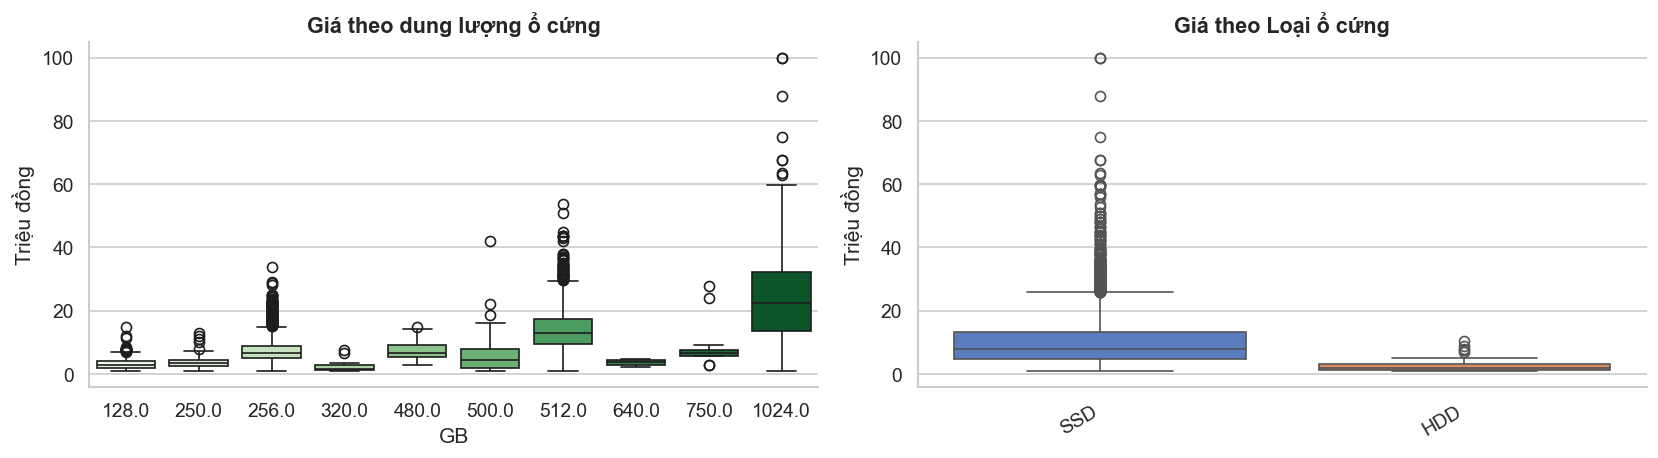

In [99]:
# ── Giá theo storage + loại ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Giá theo GB
price_storage = (df[df['_price'].between(1e6, 100e6) & df['storage_gb'].notna()]
                 .assign(price_mil=lambda x: x['_price']/1e6))
gb_order = sorted(price_storage['storage_gb'].unique())
sns.boxplot(data=price_storage, x='storage_gb', y='price_mil',
            order=gb_order, palette='Greens', ax=axes[0])
axes[0].set_title("Giá theo dung lượng ổ cứng")
axes[0].set_xlabel("GB")
axes[0].set_ylabel("Triệu đồng")

# Giá theo loại ổ cứng
price_ssd = (df[df['_price'].between(1e6, 100e6) & df['Loại ổ cứng'].notna()]
             .assign(price_mil=lambda x: x['_price']/1e6))
ssd_order = (price_ssd.groupby('Loại ổ cứng')['price_mil']
             .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_ssd, x='Loại ổ cứng', y='price_mil',
            order=ssd_order, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo Loại ổ cứng")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='storage_gb', inplace=True, errors='ignore')


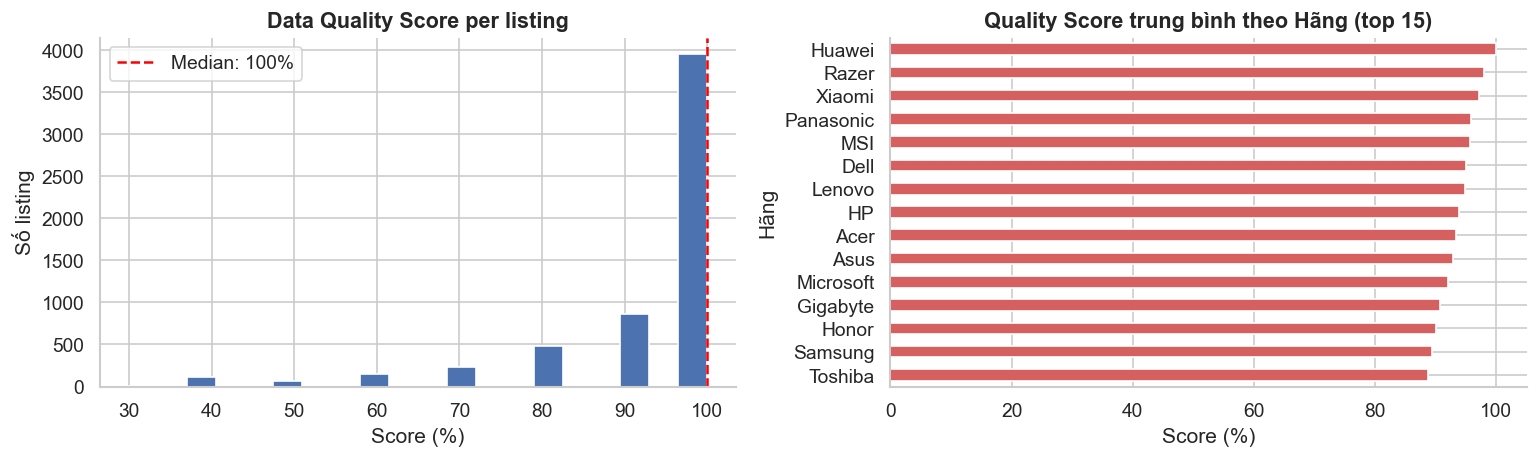

Median quality score: 100.0%
Listing score = 100% (đầy đủ mọi cột): 3,956 (67.4%)
Listing score < 50% (thiếu nhiều): 117 (2.0%)


In [100]:
# ── Data Quality Score per listing ─────────────────────────────────────────────
# Mỗi cột spec có giá trị = 1 điểm; thiếu = 0; scale 0–100%
SCORE_COLS = {
    'price':             'price',          # có giá parse được
    'Hãng':              'Hãng',
    'Tình trạng':        'Tình trạng',
    'Kích cỡ màn hình':  'Kích cỡ màn hình',
    'Bộ vi xử lý':       'Bộ vi xử lý',
    'RAM':               'RAM',
    'Card màn hình':     'Card màn hình',
    'Ổ cứng':            'Ổ cứng',
    'Loại ổ cứng':       'Loại ổ cứng',
    'Xuất xứ':           'Xuất xứ',
}

score_df = pd.DataFrame({k: df[v].notna() for k, v in SCORE_COLS.items()})
score_df['price_valid'] = df['_price'].notna()     # thay thế col price bằng parsed version
score_df = score_df.drop(columns='price')

df['quality_score'] = score_df.mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['quality_score'], bins=20, color=ACCENT, edgecolor='white')
axes[0].axvline(df['quality_score'].median(), color='red', linestyle='--',
                label=f"Median: {df['quality_score'].median():.0f}%")
axes[0].set_title("Data Quality Score per listing")
axes[0].set_xlabel("Score (%)")
axes[0].set_ylabel("Số listing")
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Score theo brand
brand_score = (df.groupby('Hãng')['quality_score'].mean()
               .sort_values(ascending=False).head(15).sort_values())
brand_score.plot(kind='barh', ax=axes[1], color=COLORS[3])
axes[1].set_title("Quality Score trung bình theo Hãng (top 15)")
axes[1].set_xlabel("Score (%)")
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median quality score: {df['quality_score'].median():.1f}%")
print(f"Listing score = 100% (đầy đủ mọi cột): {(df['quality_score'] == 100).sum():,} ({(df['quality_score']==100).mean()*100:.1f}%)")
print(f"Listing score < 50% (thiếu nhiều): {(df['quality_score'] < 50).sum():,} ({(df['quality_score']<50).mean()*100:.1f}%)")
df.drop(columns='quality_score', inplace=True, errors='ignore')

## 16. Column: `Xuất xứ` & `Thông tin sử dụng`

`Xuất xứ` — categorical, kiểm tra cardinality và liên quan đến giá.  
`Thông tin sử dụng` — text tự do, kiểm tra tiềm năng extract.


,count
Xuất xứ,
Đang cập nhật,3536
Mỹ,1101
Việt Nam,556
Nhật Bản,388
Nước khác,114
Trung Quốc,94
Đài Loan,61
Hàn Quốc,13
Thái Lan,2


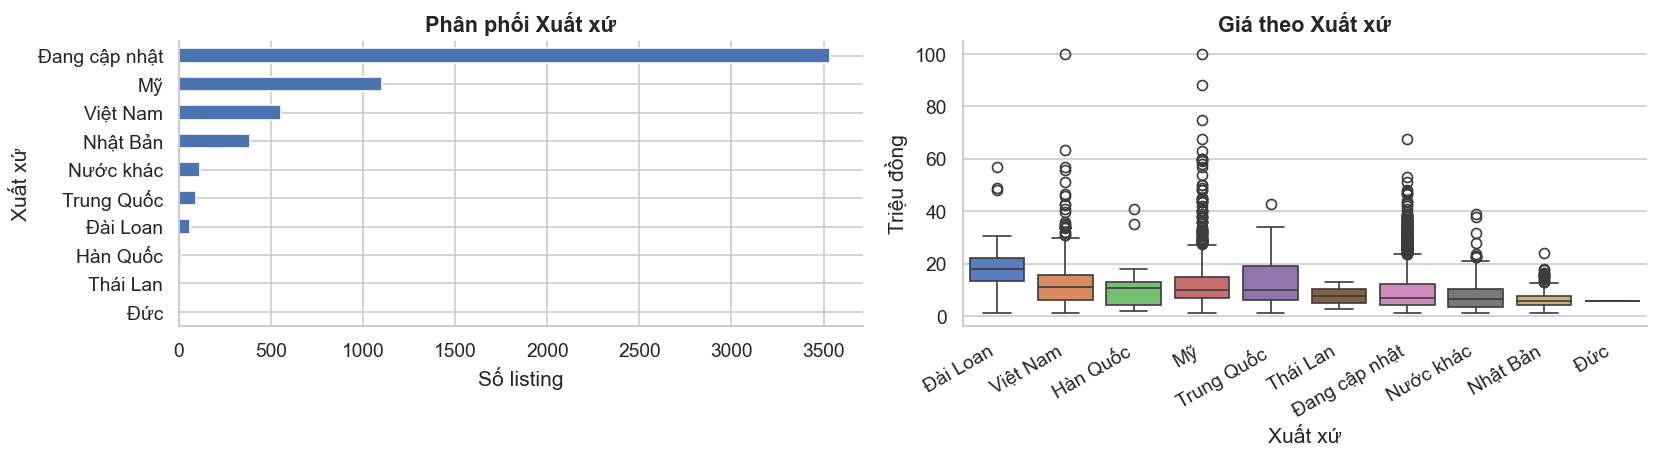

In [101]:
# ── Xuất xứ ─────────────────────────────────────────────────────────────────────
xuat_xu_vc = df['Xuất xứ'].value_counts(dropna=False)
display(xuat_xu_vc.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

xuat_xu_vc.sort_values().plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Phân phối Xuất xứ")
axes[0].set_xlabel("Số listing")

# Giá theo xuất xứ
price_xx = (df[df['_price'].between(1e6, 100e6) & df['Xuất xứ'].notna()]
            .assign(price_mil=lambda x: x['_price']/1e6))
xx_order = (price_xx.groupby('Xuất xứ')['price_mil']
            .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_xx, x='Xuất xứ', y='price_mil',
            order=xx_order, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo Xuất xứ")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [102]:
# ── Thông tin sử dụng ───────────────────────────────────────────────────────────
print("Top 20 giá trị Thông tin sử dụng:")
display(df['Thông tin sử dụng'].value_counts(dropna=False).head(20).to_frame())

# Tiềm năng extract số năm/tháng sử dụng
year_pat  = r'(\d+)\s*(năm|year)'
month_pat = r'(\d+)\s*(tháng|month)'
has_year  = df['Thông tin sử dụng'].str.contains(year_pat,  case=False, na=False)
has_month = df['Thông tin sử dụng'].str.contains(month_pat, case=False, na=False)
print(f"\nMention năm sử dụng: {has_year.sum()} ({has_year.mean()*100:.1f}%)")
print(f"Mention tháng sử dụng: {has_month.sum()} ({has_month.mean()*100:.1f}%)")


Top 20 giá trị Thông tin sử dụng:


,count
Thông tin sử dụng,
In trên bao bì,5866



Mention năm sử dụng: 0 (0.0%)
Mention tháng sử dụng: 0 (0.0%)


## 17. Cross-column Consistency

Kiểm tra mâu thuẫn nội tại giữa các cột — phát hiện errors mà phân tích từng cột riêng không thấy được.


In [103]:
# ── Brand trong Hãng vs title ────────────────────────────────────────────────────
brand_alias = {
    'ASUS': ['asus', 'vivobook', 'zenbook', 'rog', 'tuf'],
    'Dell': ['dell', 'latitude', 'inspiron', 'xps', 'vostro'],
    'HP': ['hp', 'hewlett', 'elitebook', 'probook', 'envy', 'pavilion'],
    'Lenovo': ['lenovo', 'thinkpad', 'ideapad', 'legion', 'yoga'],
    'Acer': ['acer', 'aspire', 'swift', 'nitro', 'predator'],
    'MSI': ['msi', 'stealth', 'modern', 'prestige', 'katana'],
    'Apple': ['apple', 'macbook'],
}

def brand_in_title(row):
    brand = str(row['Hãng']).lower()
    title = str(row['title']).lower()
    aliases = brand_alias.get(row['Hãng'], [brand])
    return any(a in title for a in aliases)

match = df.apply(brand_in_title, axis=1)
no_match = ~match

print(f"Brand khớp với title: {match.sum():,} ({match.mean()*100:.1f}%)")
print(f"Không khớp: {no_match.sum():,} ({no_match.mean()*100:.1f}%)")
print("\nSample không khớp (brand vs title):")
display(df[no_match][['Hãng', 'title']].head(10))


Brand khớp với title: 5,493 (93.6%)
Không khớp: 373 (6.4%)

Sample không khớp (brand vs title):


,Hãng,title
34,Acer,5 Laptop gaming i5 8G/128G SSD BH 12-2026
37,Asus,Gaming Vivobook K3605ZU 12500H RTX 2050 BH Hãng
40,Microsoft,Surface Laptop 7 X plus 16GB ram đẹp vừa bóc tem
59,Hãng khác,Laptop Fujitsu U9311 i5/8gb/256GB
75,Hãng khác,Fujitsu i7/gen9/ram16/ssd256gb siêu bền chạy mượt
98,Hãng khác,Surface Pro 7 Plus i3-1115G4 8GB/128GB /Pin 96%
113,Hãng khác,laptop máy tính bảng Fujitsu i5 Gen 8 8GB
141,Hãng khác,eMachines i5 M520 14 inch 6GB
146,Hãng khác,Lecoo Fighter 7000: i7-13650HX | RTX 5060 | 180Hz
164,Hãng khác,Bán laptop IBM T60 Đen


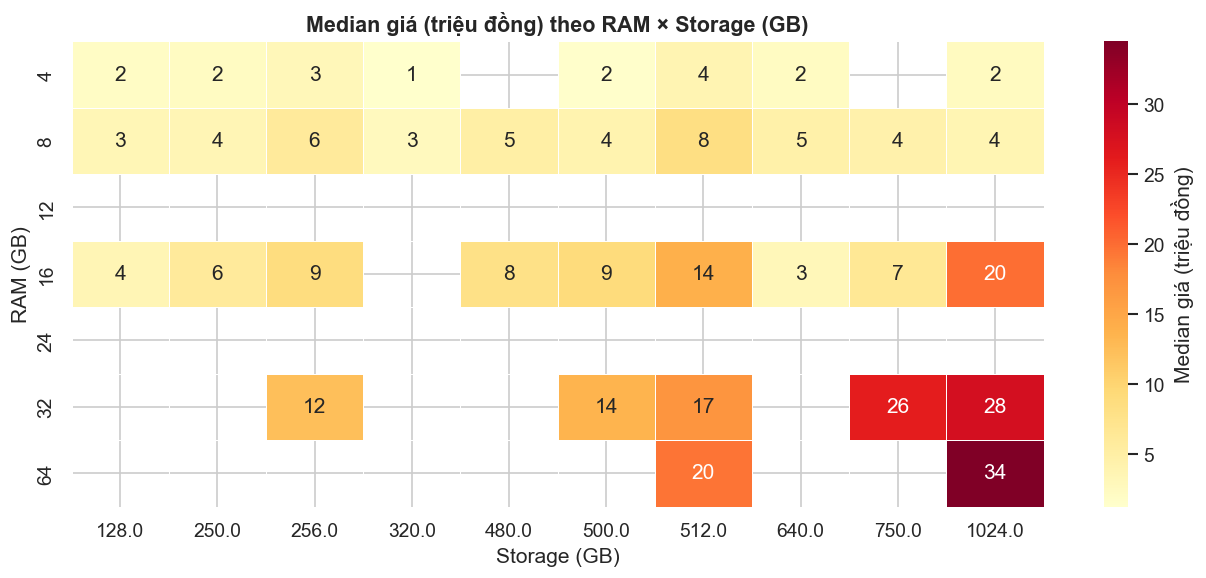

In [104]:
# ── Heatmap tương quan RAM × Storage × Giá ────────────────────────────────────────
df['ram_gb_t']  = pd.to_numeric(df['RAM'].str.extract(r'(\d+)')[0], errors='coerce')
df['stor_gb_t'] = df['Ổ cứng'].apply(parse_storage_gb)

pivot = (df[df['_price'].between(1e6, 100e6) &
            df['ram_gb_t'].notna() &
            df['stor_gb_t'].notna()]
         .assign(price_mil=lambda x: x['_price']/1e6)
         .groupby(['ram_gb_t', 'stor_gb_t'])['price_mil']
         .median()
         .unstack('stor_gb_t')
         .reindex([4, 8, 12, 16, 24, 32, 64])  # RAM rows
         )

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Median giá (triệu đồng)'})
ax.set_title("Median giá (triệu đồng) theo RAM × Storage (GB)")
ax.set_xlabel("Storage (GB)")
ax.set_ylabel("RAM (GB)")
plt.tight_layout()
plt.show()

df.drop(columns=['ram_gb_t', 'stor_gb_t'], inplace=True, errors='ignore')


In [105]:
# ── Laptop gaming thiếu GPU ────────────────────────────────────────────────────────
gaming_pat = r'(ROG|TUF|Gaming|Legion|Predator|Nitro|Katana|Raider|Titan)'
is_gaming = (df['title'].str.contains(gaming_pat, case=False, na=False) |
             df['Dòng máy'].str.contains(gaming_pat, case=False, na=False))
gaming_no_gpu = is_gaming & df['Card màn hình'].isna()

print(f"Laptop gaming (title/dòng máy) mà thiếu GPU: {gaming_no_gpu.sum()}")
if gaming_no_gpu.sum() > 0:
    display(df[gaming_no_gpu][['title', 'Dòng máy', 'Card màn hình', 'price']].head(8))


Laptop gaming (title/dòng máy) mà thiếu GPU: 24


,title,Dòng máy,Card màn hình,price
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,Inspiron,NaN,2.900.000 đ
435,Laptop Asus TUF Gaming F15 FX506HC 15.6 inch 16GB,TUF Gaming F15,NaN,11.000.000 đ
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,Dòng Khác,NaN,13.000.000 đ
1010,Acer Nitro 5 i5 9300h 16GB Đã dùng,Nitro 5,NaN,5.000.000 đ
1200,⚡ ACER NITRO V 15 - I7-13620H | RTX 4060,Aspire Nitro,NaN,22.200.000 đ
1458,ASUS TUF Gaming FX505GD i5-8300H 16GB,TUF Gaming,NaN,6.850.000 đ
1650,HP Victus Gaming i5-12450H 16GB/512GB,Victus,NaN,12.000.000 đ
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,Gaming G15,NaN,24.000.000 đ


In [106]:
# ── Laptop 'Mới 100%' nhưng giá < 3 triệu ────────────────────────────────────────
new_cheap = df[
    df['Tình trạng'].str.contains('Mới', na=False, case=False) &
    (df['_price'] < 3_000_000)
]
print(f"Laptop 'Mới' giá < 3 triệu: {len(new_cheap)}")
if len(new_cheap) > 0:
    display(new_cheap[['title', 'Tình trạng', 'price', 'Hãng']].head(10))


Laptop 'Mới' giá < 3 triệu: 7


,title,Tình trạng,price,Hãng
26,"HP 15-da0056TU i3 8130U, 4GB, SSD 128GB, 15.6"" HD",Mới,2.300.000 đ,HP
766,Dell Latitude E7250 pin 4h,Mới,1.700.000 đ,Dell
1667,LAPTOP DELL I5 - MỚI 100% - GÓP NHANH,Mới,2.300.000 đ,Dell
3076,"Dell Vostro 3468 Core i3-6006U, RAM 4GB, SSD 120GB",Mới,1.800.000 đ,Dell
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,Mới,2.600.000 đ,Asus
3565,"Dell Inspiron 3467 Core i3-7020U, 4GB, SSD 128GB",Mới,1.900.000 đ,Dell
4695,Bán Macbook 12inch 2015 Ram 8G/512G màu Gold,Mới,2.450.000 đ,Apple


In [107]:
# ── Ổ cứng inconsistency chi tiết ────────────────────────────────────────────────
case_a = df['Loại ổ cứng'].notna() & df['Ổ cứng'].isna()
case_b = df['Loại ổ cứng'].isna()  & df['Ổ cứng'].notna()
print(f"Có Loại nhưng không có Dung lượng: {case_a.sum()}")
print(f"Có Dung lượng nhưng không có Loại:  {case_b.sum()}")
if case_a.sum() > 0:
    print("\nSample case A:")
    display(df[case_a][['Loại ổ cứng', 'Ổ cứng', 'title']].head(5))
if case_b.sum() > 0:
    print("\nSample case B:")
    display(df[case_b][['Loại ổ cứng', 'Ổ cứng', 'title']].head(5))


Có Loại nhưng không có Dung lượng: 128
Có Dung lượng nhưng không có Loại:  384

Sample case A:


,Loại ổ cứng,Ổ cứng,title
113,SSD,NaN,laptop máy tính bảng Fujitsu i5 Gen 8 8GB
159,SSD,NaN,HP ProBook 4430s i7 6GB SSD Xám
164,HDD,NaN,Bán laptop IBM T60 Đen
199,SSD,NaN,Bán MacBook Pro i5 16GB/SSD Xám tại Hà Đông
204,SSD,NaN,Dell Latitude E6430 i5-3320M 4GB/400GB



Sample case B:


,Loại ổ cứng,Ổ cứng,title
33,NaN,256 GB,MacBook Air M4 13.3 inch (16GB/256GB ) bh 9/2026
39,NaN,256 GB,Dell Inspiron 5480 i5-8265U 16GB/256GB
66,NaN,500 GB,HP ZBook Fury 16 G9 i7-12850HX 16 inch 16GB/500GB
67,NaN,256 GB,Microsoft Surface Laptop 4 i7 15 inch 16GB/256GB
97,NaN,128 GB,"Lenovo ThinkPad X230 Hỏng pin, kênh bàn phím"


## 18. Issues Summary

Tổng hợp các vấn đề được xác nhận bằng số liệu — làm input cho `02a_chotot_cleaning.ipynb`.


In [108]:
# Tính lại số liệu thực tế để fill vào issues
_pv   = df['_price']                     # _price vẫn còn trên df
n_pf  = _pv.isna().sum()
n_plo = (_pv < 1_000_000).sum()
n_phi = (_pv > 150_000_000).sum()

# FIX: tính sẵn biến, tránh f-string lồng phức tạp
cpu_pct = (df['title'].str.contains(r'(i\d[-\s]?\d{4,5}|Ryzen|M[123])',
           case=False, na=False).mean() * 100)
rare_brand_count = (df['Hãng'].value_counts() < 10).sum()
tinhtrang_anomaly = (df['Tình trạng'].str.contains('Mới', na=False) & (_pv < 3e6)).sum()
stor_inconsist = (df['Loại ổ cứng'].isna() & df['Ổ cứng'].notna()).sum()

issues = pd.DataFrame([
    # Prices
    (
     'price',
     'Giá có phân phối lệch mạnh (right-skewed), tập trung ở phân khúc thấp-trung và có một số outlier giá rất cao; có khả năng tồn tại nhiễu do listing lỗi, spam hoặc sản phẩm đặc biệt',
     'Áp dụng log transform khi modeling; kiểm tra và xử lý outlier (capping hoặc filtering); không dùng mean để mô tả'
    ),
    (
     'price_outliers',
     'Tồn tại các giá trị bất thường (quá thấp hoặc quá cao) có thể do lỗi nhập liệu, spam hoặc sản phẩm không cùng phân khúc hoặc rác dựa trên title',
     'Dùng IQR hoặc percentile để detect; xử lý bằng clipping hoặc loại bỏ tùy use case'
    ),
    (
     'price_market_bias',
     'Giá phản ánh thị trường Việt Nam (second-hand, xách tay, thanh lý), không đại diện cho giá retail chính hãng toàn cầu',
     'Không suy rộng kết luận ra thị trường quốc tế; model chỉ phù hợp với bối cảnh local'
    ),

    # Title
    (
     'title',
     'Text tự do, giàu thông tin nhưng không đồng đều; ~91% có brand, ~58% có RAM, ~50% có storage, ~45% có CPU; tuy nhiên chỉ ~12–14% dòng missing có thể recover từ title → thông tin phân bố lệch và mang tính semi-structured',
     'Giữ làm metadata; extract feature có kiểm soát (RAM/Storage/CPU); chỉ dùng để fill missing khi cần, không overwrite structured; xử lý bằng rule-based parsing, tránh regex đơn giản'
    ),
    (
     'title_parsing',
     'Có ambiguity cao khi extract, đặc biệt RAM vs Storage (512GB, 256GB) và GPU VRAM; nhiều pattern dạng 16GB/512GB hoặc text không chuẩn → dễ false positive',
     'Dùng parsing có ngữ cảnh (RAM keyword + valid values); ưu tiên pattern rõ ràng; validate trước khi dùng'
    ),
    (
     'title_recovery',
     'Khả năng fill missing thấp: CPU ~12%, RAM ~13%, Storage ~6% → title không phải nguồn chính để xử lý missing (missing not at random)',
     'Chỉ dùng title như fallback; kết hợp imputation hoặc rule theo nhóm'
    ),
    (
     'title_consistency',
     'Có conflict đáng kể với structured columns (RAM ~188 rows, Storage ~96 rows) → text không đáng tin tuyệt đối',
     'Không dùng title để overwrite dữ liệu có sẵn; chỉ dùng khi structured bị thiếu'
    ),
    (
     'title_structure',
     'Khoảng ~10% title có pattern dạng "X/Y" (8/256, 16/512) → dữ liệu mang tính semi-structured',
     'Khai thác bằng parser riêng để tách RAM/Storage thay vì regex đơn giản'
    ),
    (
     'title_cpu_coverage',
     'Regex CPU chưa cover hết pattern (Core2 Duo, N-series, Intel/AMD generic) → miss một phần dữ liệu',
     'Chấp nhận coverage không hoàn toàn; không rely 100% vào title cho CPU feature'
    ),

    # Brand
    (
     'brand_price_segment',
     'Phân bố giá theo brand không đồng đều; một số brand tập trung ở high/premium (MSI, Razer), trong khi brand khác chủ yếu ở low/mid (Dell, Acer); tuy nhiên các brand nhỏ (Honor, Xiaomi) có phân bố không ổn định do sample ít',
     'Giữ brand làm feature chính; có thể tạo thêm feature segment (low/mid/high/premium); không rely vào distribution của brand nhỏ'
    ),
    (
     'brand_sample_bias',
     'Một số brand có số lượng listing rất thấp nhưng lại có tỷ lệ premium cao bất thường (ví dụ Honor), gây hiểu sai về positioning',
     'Gộp brand tần suất thấp vào "Other" khi modeling; chỉ phân tích sâu các brand có đủ dữ liệu'
    ),
    (
     'price_segment_skew',
     'Phân bố giá theo brand bị lệch và không đồng đều giữa các phân khúc; nhiều brand có sự pha trộn giữa mid và high thay vì phân tách rõ ràng',
     'Không sử dụng hard rule để map brand → segment; để model tự học kết hợp với các feature khác (RAM, CPU, storage)'
    ),
    (
     'brand_as_proxy',
     'Brand đóng vai trò proxy cho phân khúc giá và positioning sản phẩm, nhưng không phản ánh hoàn toàn do còn phụ thuộc vào cấu hình và tình trạng',
     'Giữ brand trong model; kết hợp với spec features để tránh over-reliance vào brand'
    ),

    # Series
    (
        'model_high_cardinality',
        'Cột Dòng máy có cardinality rất cao (458 unique), gây sparsity và khó encode trực tiếp',
        'Tránh one-hot toàn bộ; sử dụng grouping, target encoding hoặc kết hợp với Hãng'
    ),
    (
        'model_long_tail_distribution',
        'Phân phối Dòng máy có long-tail mạnh; phần lớn model xuất hiện rất ít lần (đa số <10 listing)',
        'Group các model hiếm hoặc chỉ giữ top-N model để đảm bảo đủ dữ liệu học'
    ),
    (
        'dong_khac_information_loss',
        'Khoảng 15% dữ liệu bị gom vào "Dòng Khác", làm mất thông tin chi tiết về series sản phẩm',
        'Xử lý riêng "Dòng Khác" và cố gắng recover lại từ title nếu có thể'
    ),
    (
        'dong_khac_recoverable_from_title',
        'Một phần lớn "Dòng Khác" thực tế chứa thông tin series rõ ràng trong title (Latitude, ThinkPad, ...)',
        'Dùng regex/keyword extraction để map lại Dòng máy từ title'
    ),
    (
        'model_brand_dependency',
        'Dòng máy gần như gắn chặt với một Hãng (brand_count = 1), nên mang tính proxy chi tiết của brand',
        'Sử dụng kết hợp Hãng + Dòng máy hoặc encoding tương đương thay vì dùng riêng lẻ'
    ),
    (
        'model_strong_price_signal',
        'Dòng máy thể hiện phân tầng giá rõ ràng theo product line (MacBook, Legion, Precision, ...)',
        'Giữ feature này trong model; kết hợp với spec để tăng độ chính xác'
    ),
    (
        'model_price_stability',
        'Các dòng máy phổ biến có phân phối giá ổn định (IQR thấp), trong khi nhóm tổng hợp có biến động lớn',
        'Ưu tiên giữ các dòng cụ thể; xử lý riêng nhóm có IQR cao (Dòng Khác, Rare)'
    ),
    (
        'model_name_inconsistency',
        'Tồn tại biến thể tên (viết hoa/thường, ký tự) gây phân mảnh category',
        'Chuẩn hóa text (lowercase, remove special chars) trước khi encode'
    ),
    (
        'model_grouping_tradeoff',
        'Grouping giúp giảm cardinality (458 → 101) nhưng tạo nhóm không đồng nhất (Rare/Other)',
        'Giữ grouping nhưng cân nhắc thêm flag hoặc feature bổ sung để giảm noise'
    ),
    (
        'rare_group_heterogeneity',
        'Nhóm Rare/Other có độ phân tán giá lớn, chứa nhiều loại sản phẩm khác nhau',
        'Xem xét tách thêm theo brand hoặc price-based binning nếu cần'
    ),
    (
        'model_vs_dong_khac_difference',
        '“Rare/Other” và “Dòng Khác” có đặc điểm giá khác nhau rõ rệt (Rare cao hơn, Dòng Khác thấp hơn)',
        'Không gộp chung hai nhóm này; xử lý như hai loại category khác nhau'
    ),
    (
        'model_as_segment_indicator',
        'Dòng máy phản ánh trực tiếp product segment (gaming, business, ultrabook)',
        'Khai thác như feature phân khúc thay vì chỉ categorical thuần'
    ),

    # Condition
    (
        'condition_label_noise',
        'Nhãn "Tình trạng" không hoàn toàn đáng tin cậy do dữ liệu user-generated; một số sản phẩm được gắn "Mới" nhưng thực tế là hàng đã qua sử dụng hoặc mang tính marketing',
        'Không sửa trực tiếp ở bước inspection; giữ nguyên và xử lý bằng flag hoặc feature bổ sung ở bước preprocessing'
    ),
    (
        'new_low_price_inconsistency',
        'Một tỷ lệ đáng kể sản phẩm "Mới" có giá thấp bất thường (≈13.7% <5M, ≈30% <10M), không phù hợp với mặt bằng thị trường',
        'Tạo flag (new_low_price) để mô hình nhận diện; không loại bỏ toàn bộ để tránh mất thông tin'
    ),
    (
        'title_condition_mismatch',
        'Title chứa keyword như "đẹp 98%", "pin", "góp",... nhưng vẫn được gắn nhãn "Mới", cho thấy sự lệch giữa structured data và text',
        'Khai thác title để tạo feature (keyword-based flag) thay vì chỉ dựa vào cột Tình trạng'
    ),
    (
        'repair_condition_mismatch',
        'Một số title có dấu hiệu lỗi/sửa chữa ("lỗi", "lỗi main", "vỡ",...) nhưng Tình trạng không phải "qua sửa chữa"',
        'Tạo flag repair_mismatch để bổ sung thông tin cho model và giảm noise'
    ),
    (
        'condition_price_outliers',
        'Tồn tại outlier giá trong cả 3 nhóm Tình trạng (~4–11%), đặc biệt ở nhóm "qua sửa chữa" có biến động cao hơn',
        'Không loại bỏ ngay; có thể giữ lại hoặc xử lý tùy theo model (tree vs linear)'
    ),
    (
        'condition_imbalance',
        'Phân bố Tình trạng bị lệch mạnh (≈95% là "đã sử dụng chưa sửa"), khiến signal từ các nhóm nhỏ bị hạn chế',
        'Cân nhắc trong modeling (regularization, sampling hoặc feature engineering), không cần xử lý ở inspection'
    ),
    (
        'condition_warranty_inconsistency',
        'Một số sản phẩm "Mới" nhưng lại "Hết bảo hành", không phù hợp với kỳ vọng thông thường',
        'Tạo flag inconsistency giữa Tình trạng và bảo hành; không sửa trực tiếp dữ liệu gốc'
    ),
    (
        'cross_column_inconsistency',
        'Tồn tại inconsistency giữa nhiều cột (Tình trạng, title, bảo hành), phản ánh bản chất noisy của dữ liệu marketplace',
        'Ưu tiên feature engineering dựa trên cross-column signals thay vì cố làm sạch tuyệt đối'
    ),
    (
        'ordinal_encoding_assumption',
        'Việc encode Tình trạng theo ordinal giả định quan hệ tuyến tính giữa các mức, trong khi khoảng cách giá thực tế không đồng đều',
        'Thử nghiệm nhiều phương pháp encoding (ordinal, one-hot, target encoding) và chọn theo performance'
    ),
    (
        'semantic_signal_vs_structured',
        'Thông tin quan trọng về tình trạng thực tế nằm trong title nhiều hơn structured column',
        'Kết hợp NLP/regex extraction từ title để bổ sung signal cho model'
    ),

    # Warranty
    (
        'warranty_mixed_semantics',
        'Chính sách bảo hành trộn nhiều loại thông tin (thời gian, trạng thái, nguồn) nên khó học và khó diễn giải',
        'Tách thành warranty_months, warranty_status, warranty_source trước khi encode'
    ),
    (
        'warranty_signal_moderate',
        'Có tương quan với giá (bảo hành dài hơn → giá cao hơn) nhưng không mạnh và không ổn định',
        'Dùng như feature phụ trợ, không dùng standalone'
    ),
    (
        'warranty_status_informative',
        'Các giá trị như Còn bảo hành vs Hết bảo hành có sự khác biệt giá rõ ràng',
        'Tạo feature đơn giản như has_warranty hoặc warranty_status'
    ),
    (
        'warranty_category_imbalance',
        'Phân phối rất lệch với Bảo hành hãng chiếm đa số, có thể gây bias',
        'Cân nhắc gộp nhóm hoặc encode cẩn thận'
    ),
    (
        'warranty_low_priority_feature',
        'So với Dòng máy, RAM, CPU thì feature này có sức giải thích thấp hơn',
        'Ưu tiên feature cấu hình, warranty chỉ bổ trợ'
    ),

    # Screen
    (
        'screen_size_signal_moderate',
        'Kích cỡ màn hình có tương quan với giá (size lớn hơn → giá cao hơn) nhưng signal chỉ ở mức trung bình và không tuyến tính',
        'Sử dụng như feature phụ trợ, kết hợp với cấu hình và dòng máy thay vì dùng standalone'
    ),
    (
        'screen_size_distribution_bimodal',
        'Phân phối tập trung mạnh ở hai nhóm chính 13–14.9 inch và 15–16.9 inch, phản ánh 2 phân khúc chính của thị trường',
        'Có thể giữ dạng bucket hoặc encode ordinal thay vì one-hot chi tiết'
    ),
    (
        'screen_size_long_tail_noise',
        'Các nhóm kích thước nhỏ (<10 inch, >19 inch) có rất ít dữ liệu và mang tính noise',
        'Cân nhắc gộp các nhóm hiếm hoặc loại bỏ khỏi modeling nếu cần'
    ),
    (
        'screen_missing_not_random',
        'Missing màn hình có median giá thấp hơn (~6M vs ~8M), cho thấy missing mang tính informative (không ngẫu nhiên)',
        'Tạo flag screen_missing thay vì impute đơn giản; tránh mất signal'
    ),
    (
        'screen_recovery_low_coverage',
        'Chỉ ~4% missing có thể recover từ title, cho thấy việc extract bổ sung có hiệu quả thấp',
        'Không cần đầu tư nhiều vào rule-based extraction; chỉ dùng như bước bổ sung nhẹ'
    ),
    (
        'screen_title_mismatch_low',
        'Mismatch giữa cột và title rất thấp (~9 dòng), cho thấy dữ liệu tương đối sạch',
        'Không cần xử lý mạnh; có thể ưu tiên title nếu cần độ chính xác cao hơn'
    ),
    (
        'screen_brand_dependency',
        'Phân phối kích cỡ màn hình có sự phụ thuộc vào Hãng (mỗi hãng có dominant size riêng)',
        'Có thể dùng Hãng để hỗ trợ impute hoặc feature interaction'
    ),
    (
        'screen_imputation_risk',
        'Một số hãng có missing rate cao và dominant_pct không đủ mạnh → impute theo hãng có thể gây bias',
        'Chỉ áp dụng impute cho hãng có dominant_pct cao; tránh hard rule cho toàn bộ dữ liệu'
    ),
    (
        'screen_feature_interaction',
        'Kích cỡ màn hình không độc lập mà tương tác mạnh với Dòng máy và cấu hình (RAM, CPU)',
        'Khai thác interaction thay vì dùng feature đơn lẻ'
    ),
    (
        'screen_as_segment_proxy',
        'Kích cỡ màn hình phản ánh một phần phân khúc (ultrabook vs gaming/business) nhưng không đủ để phân biệt rõ',
        'Kết hợp với Dòng máy để capture segment tốt hơn'
    ),

    # CPU
        (
        'cpu_tier_dominant_signal',
        'CPU tier là yếu tố chính quyết định giá, phân tách rõ các phân khúc (I3 < I5 < I7 < I9)',
        'Sử dụng cpu_tier làm feature chính trong modeling'
    ),
    (
        'cpu_gen_secondary_signal',
        'CPU generation chỉ có ý nghĩa khi so sánh trong cùng một tier, không mạnh khi đứng riêng',
        'Kết hợp cpu_tier và cpu_gen thay vì dùng riêng lẻ'
    ),
    (
        'cpu_missing_not_random',
        'Missing CPU không ngẫu nhiên, thường xuất hiện ở các listing thiếu thông tin hoặc không chuẩn',
        'Tạo flag cho missing và giữ lại dữ liệu để model học pattern'
    ),
    (
        'title_recovers_cpu_info',
        'Thông tin CPU (đặc biệt model và generation) chủ yếu nằm trong title, không có trong structured column',
        'Ưu tiên dùng feature từ title (_cpu_*_all) thay vì structured'
    ),
    (
        'cpu_interaction_with_ram',
        'CPU không hoạt động độc lập mà tương tác mạnh với RAM và các cấu hình khác',
        'Tạo feature interaction giữa cpu_tier và ram'
    ),
    (
        'high_price_outliers_explainable',
        'Các outlier giá cao chủ yếu do cấu hình mạnh (RAM lớn, GPU rời) hoặc brand premium',
        'Không loại bỏ outlier, thay vào đó bổ sung feature để giải thích'
    ),
    (
        'cpu_brand_imbalanced',
        'Dữ liệu bị lệch mạnh về Intel, AMD và Apple xuất hiện ít hơn',
        'Cân nhắc grouping hoặc encoding phù hợp để tránh bias'
    ),

    ('RAM',
     f'Missing {df["RAM"].isna().sum()} ({df["RAM"].isna().mean()*100:.1f}%); text "X GB"; có thể có outlier',
     'Extract số GB; validate [4, 128]'),
    ('Card màn hình',
     f'Missing {df["Card màn hình"].isna().sum()} ({df["Card màn hình"].isna().mean()*100:.1f}%) — '
     f'nhiều khả năng integrated; gaming laptop thiếu GPU nghi vấn',
     'Phân loại: Dedicated / Integrated / Missing'),
    ('Ổ cứng',
     f'Missing {df["Ổ cứng"].isna().sum()} ({df["Ổ cứng"].isna().mean()*100:.1f}%); mix GB/TB',
     'Convert về GB'),
    ('Loại ổ cứng',
     f'Missing {df["Loại ổ cứng"].isna().sum()} ({df["Loại ổ cứng"].isna().mean()*100:.1f}%); '
     f'inconsistency với Ổ cứng: {stor_inconsist} dòng',
     'Chuẩn hóa SSD/HDD/eMMC; fill từ Ổ cứng nếu có thể'),
    ('Xuất xứ',
     f'{df["Xuất xứ"].nunique()} distinct; missing {df["Xuất xứ"].isna().sum()}',
     'Giữ hoặc drop tùy correlation với giá'),
    ('Thông tin sử dụng',
     f'Text tự do; ít structured; missing {df["Thông tin sử dụng"].isna().sum()}',
     'Giữ làm metadata; ít dùng làm feature'),
    ('url',
     'Identifier duy nhất; không missing',
     'Giữ để dedup; không dùng làm feature'),
], columns=['Column', 'Issue (với số liệu)', 'Proposed Action'])

display(issues)

,Column,Issue (với số liệu),Proposed Action
0,price,"Giá có phân phối lệch mạnh (right-skewed), tập trung ở phân khúc thấp-trung ...",Áp dụng log transform khi modeling; kiểm tra và xử lý outlier (capping hoặc ...
1,price_outliers,Tồn tại các giá trị bất thường (quá thấp hoặc quá cao) có thể do lỗi nhập li...,Dùng IQR hoặc percentile để detect; xử lý bằng clipping hoặc loại bỏ tùy use...
2,price_market_bias,"Giá phản ánh thị trường Việt Nam (second-hand, xách tay, thanh lý), không đạ...",Không suy rộng kết luận ra thị trường quốc tế; model chỉ phù hợp với bối cản...
3,title,"Text tự do, giàu thông tin nhưng không đồng đều; ~91% có brand, ~58% có RAM,...",Giữ làm metadata; extract feature có kiểm soát (RAM/Storage/CPU); chỉ dùng đ...
4,title_parsing,"Có ambiguity cao khi extract, đặc biệt RAM vs Storage (512GB, 256GB) và GPU ...",Dùng parsing có ngữ cảnh (RAM keyword + valid values); ưu tiên pattern rõ rà...
5,title_recovery,"Khả năng fill missing thấp: CPU ~12%, RAM ~13%, Storage ~6% → title không ph...",Chỉ dùng title như fallback; kết hợp imputation hoặc rule theo nhóm
6,title_consistency,"Có conflict đáng kể với structured columns (RAM ~188 rows, Storage ~96 rows)...",Không dùng title để overwrite dữ liệu có sẵn; chỉ dùng khi structured bị thiếu
7,title_structure,"Khoảng ~10% title có pattern dạng ""X/Y"" (8/256, 16/512) → dữ liệu mang tính ...",Khai thác bằng parser riêng để tách RAM/Storage thay vì regex đơn giản
8,title_cpu_coverage,"Regex CPU chưa cover hết pattern (Core2 Duo, N-series, Intel/AMD generic) → ...",Chấp nhận coverage không hoàn toàn; không rely 100% vào title cho CPU feature
9,brand_price_segment,Phân bố giá theo brand không đồng đều; một số brand tập trung ở high/premium...,Giữ brand làm feature chính; có thể tạo thêm feature segment (low/mid/high/p...


In [109]:
# ── Save + final cleanup ────────────────────────────────────────────────────────
issues.to_csv('../../docs/chotot_issues_list.csv', index=False, encoding='utf-8-sig')
print("Saved: docs/chotot_issues_list.csv")

Saved: docs/chotot_issues_list.csv
